# Who Earned the Credit?

> *Splitting a channel's Marketing Mix Model impact across campaigns, using a 100-year-old idea from insurance*

Your Marketing Mix Model has done its job. It tells you, with honest uncertainty, that **Paid Social drove this much incremental revenue**, day by day. You bring it to the review, and the first question is the one the MMM cannot answer:

> *"Which campaign?"*

So you open the platform dashboard. Every campaign is proudly claiming conversions. Add them up and they total far more than the MMM says the whole channel earned. The always-on brand campaign looks steady, a weekend burst commands attention, a tiny niche campaign swings from hero to flop week to week, and the broad prospecting push that only launched in April has barely four weeks of history to its name. On top of that, most of those platform conversions are rule-based and **non-incremental**: plenty of those people would have converted anyway.

Strip the noise away and the problem is simple. You have **one number you trust** (the MMM's channel total) and **seven shaky signals** (the per-campaign platform numbers). The question is not *whether* to use the shaky signals, because they are all you have. It is **how much to believe each one**.

::: {.callout-tip title="The old idea we are going to borrow"}
This is exactly the problem an insurance actuary solves before breakfast.

Picture pricing car insurance. A driver comes in with **one** claim-free year. Do you give them the flawless-driver discount? Of course not, because one year is too little to tell skill from luck. So you **blend** their record with the average driver, and you lean on their own history more and more as it piles up:

$$\text{best guess}=Z\cdot(\text{their record})+(1-Z)\cdot(\text{average driver}),
\qquad Z=\frac{n}{n+k}.$$

That blend has a name, **credibility**, and a single dial, **Z**, that runs from 0 ("I will trust the average") to 1 ("I will trust you"). It turns on one thing: **how much evidence you have** ($n$), measured against a threshold $k$ that says how much evidence counts as "enough."

The arithmetic is friendly. In this notebook $k$ is estimated at roughly 39,000 reached people. The campaign that reached 62,000 people ends up at $Z\approx 0.60$, so we believe about three fifths of its own story and fill the rest with the group average. The campaign that reached 18,000 ends up at $Z\approx 0.33$, mostly the average until it earns more trust. Nobody is ignored, and nobody is blindly believed.
:::

**The whole idea of this notebook, in one sentence:** swap *"years of driving history"* for *"how many people the campaign reached"*, and use that dial to decide how much of each campaign's own story to believe. **Reach is evidence.**

What you get at the end is a per-campaign, per-day split of the MMM's channel credit that (a) always adds back up to the MMM total, (b) cannot be hijacked by small, loud campaigns, and (c) carries an uncertainty band you can defend in the budget meeting.

::: {.callout-note collapse="true" title="For the statistically minded: the exact mapping (and why it equals Fay-Herriot)"}
This is **Bühlmann credibility**, which blends a policyholder's own experience with the collective mean,
$$\text{premium}=Z\cdot(\text{own})+(1-Z)\cdot(\text{collective}),\qquad Z=\frac{n}{n+k},$$
and it is exactly hierarchical-Bayes partial pooling.

An actuary routinely uses one quantity to scale the premium and a different one to set the credibility weight, and that is what happens here. A person re-reached on a second day adds delivery volume but no new information about the campaign, so **reach-days** carry the exposure and **unique people reached** carry the evidence.

| Bühlmann credibility (actuarial) | This MMM disaggregation |
|---|---|
| Policyholder | Campaign $c$ |
| Portfolio, the *collective* | The whole social channel |
| Own loss experience (noisy) | Naive contribution per reach-day (social split by click share) |
| Earned exposure, in policy-years | **Reach-days** $R_c=\sum_t \text{reach}_{ct}$, the volume the credit is spent over |
| Volume measure that sets credibility | **Unique people reached** $n_c$, from the expanding-window query |
| Loss per unit exposure | Contribution per reach-day |
| Collective mean | Channel-average log-effectiveness $\mu$ |
| Credibility factor $Z_c=\frac{n_c}{n_c+k}$ | Trust in a campaign's own signal |
| Credibility premium | Trust-adjusted rate per reach-day, spent over daily reach-days |

Writing the direct estimate's sampling variance as $\psi_c=s^2/n_c$,
$$Z_c=\frac{n_c}{n_c+k}=\frac{\tau^2}{\tau^2+\psi_c}=1-B_c^{\text{FH}},$$
so this is the **actuarial twin of the Fay-Herriot notebook**, with sampling variances tied to reach rather than supplied by hand.
:::

In [1]:
import warnings
from dataclasses import dataclass

import arviz as az
import arviz_plots as azp
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import xarray as xr
from arviz_base.labels import NoVarLabeller
from IPython.display import Markdown, display
from scipy.stats import spearmanr

from pymc_marketing.metrics import crps, per_observation_crps
from pymc_marketing.paths import data_dir

warnings.filterwarnings("ignore")

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"
az.rcParams["stats.ci_kind"] = "hdi"
az.rcParams["stats.ci_prob"] = 0.94

CI_PROB = az.rcParams["stats.ci_prob"]
seed = 42
rng: np.random.Generator = np.random.default_rng(seed=seed)

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

## Load the data

Seven campaigns ran on one social channel across a 120-day window: six veterans plus a broad prospecting push that only kicked off on April 1st. We load the everyday delivery telemetry any analyst has (spend, impressions, reach, clicks), the pairwise audience-overlap matrix, and the **MMM's social-contribution posterior**, which is the full range of plausible values for the channel's daily impact rather than a point estimate. That posterior is the trustworthy number we are going to divide up. We also quietly load a simulated ground truth, used **only** at the very end to grade our work, never to fit.

In [2]:
@dataclass
class CampaignData:
    """Delivery telemetry, the MMM social posterior, and the held-out ground truth."""

    metrics: pd.DataFrame
    cum_reach: pd.DataFrame
    overlap: pd.DataFrame
    mmm: pd.DataFrame
    social: xr.DataArray
    truth: pd.DataFrame  # oracle, used only for grading

    @property
    def campaigns(self) -> list[str]:
        """Campaign names, in the order reported by the expanding-window query."""
        return list(self.cum_reach.columns)


def load_campaign_data() -> CampaignData:
    """Read the campaign telemetry, the MMM social posterior, and the ground truth."""
    contribution = xr.open_dataset(
        data_dir / "credibility_channel_contribution_posterior.nc"
    )["channel_contribution"]
    return CampaignData(
        metrics=pd.read_csv(
            data_dir / "credibility_campaign_daily_metrics.csv", parse_dates=["date"]
        ),
        cum_reach=pd.read_csv(
            data_dir / "credibility_campaign_cumulative_reach.csv",
            index_col=0,
            parse_dates=True,
        ),
        overlap=pd.read_csv(
            data_dir / "credibility_audience_overlap_matrix.csv", index_col=0
        ),
        mmm=pd.read_csv(
            data_dir / "credibility_mmm_input_data.csv", parse_dates=["date"]
        ),
        social=contribution.sel(channel="social"),
        truth=pd.read_csv(
            data_dir / "credibility_ground_truth_campaign_contributions.csv",
            index_col=0,
            parse_dates=True,
        ),
    )


data = load_campaign_data()
campaigns = data.campaigns
colors = {campaign: f"C{i}" for i, campaign in enumerate(campaigns)}
channel_total = float(data.social.sum("date").mean())

display(
    Markdown(
        f"**{len(campaigns)} campaigns**, "
        f"**{data.metrics['date'].nunique()} days** from "
        f"{data.metrics['date'].min():%Y-%m-%d} to {data.metrics['date'].max():%Y-%m-%d}. "
        f"MMM social contribution over the window: **{channel_total:,.0f}** "
        f"(posterior mean of the total)."
    )
)

**7 campaigns**, **120 days** from 2025-01-01 to 2025-04-30. MMM social contribution over the window: **281,777** (posterior mean of the total).

## Exploratory data analysis

### The data you already have

Every ad platform, and its reporting API, hands you a table like this: one row per campaign per day, with delivery, attention, and cost.

In [3]:
platform_export = (
    data.metrics.loc[
        data.metrics["impressions"] > 0,
        ["date", "campaign", "reach", "impressions", "clicks", "spend"],
    ]
    .assign(
        ctr_pct=lambda df: (100 * df["clicks"] / df["impressions"]).round(2),
        cpm=lambda df: (1000 * df["spend"] / df["impressions"]).round(2),
    )
    .drop(columns="spend")
)
# one mid-flight day in February, when six of the seven campaigns are live
mid_flight = sorted(data.metrics["date"].unique())[55]
platform_export.query("date == @mid_flight").reset_index(drop=True)

,date,campaign,reach,impressions,clicks,ctr_pct,cpm
0,2025-02-25,brand_always_on,13911,26919,408,1.52,13.43
1,2025-02-25,spring_promo,9437,18430,371,2.01,15.00
2,2025-02-25,lookalike_conversions,3386,4006,70,1.75,17.13
3,2025-02-25,video_product_launch,7426,14472,150,1.04,10.43
4,2025-02-25,flash_sale_burst,11227,41245,769,1.86,15.30
5,2025-02-25,niche_interest,1859,2342,52,2.22,19.26


Aggregated over each campaign's flight, the same export gives the summary any media report starts from. Two columns deserve care because the notebook turns on the difference between them: `reach_days` is the daily reach column summed over days, which counts the same person again every day the campaign touches them, while `unique_reach` is the number of distinct people reached by the end of the window. Their ratio, `reach_days_per_person`, is how many days the average reached person saw the campaign.

In [4]:
def campaign_totals(metrics: pd.DataFrame, campaigns: list[str]) -> pd.DataFrame:
    """Flight totals per campaign: clicks, impressions, spend, reach-days, active days."""
    return (
        metrics.groupby("campaign")
        .agg(
            clicks=("clicks", "sum"),
            impressions=("impressions", "sum"),
            spend=("spend", "sum"),
            reach_days=("reach", "sum"),
            active_days=("active", "sum"),
        )
        .reindex(campaigns)
    )


def final_unique_reach(cum_reach: pd.DataFrame, campaigns: list[str]) -> pd.Series:
    """Unduplicated people reached by the end of the window, the evidence measure."""
    return cum_reach.ffill().iloc[-1].reindex(campaigns).astype(float)


def campaign_summary(data: CampaignData) -> pd.DataFrame:
    """Flight-level delivery, cost and efficiency, one row per campaign."""
    totals = campaign_totals(data.metrics, data.campaigns)
    unique_reach = final_unique_reach(data.cum_reach, data.campaigns)
    return pd.DataFrame(
        {
            "active_days": totals["active_days"],
            "spend": totals["spend"],
            "impressions": totals["impressions"],
            "clicks": totals["clicks"],
            "reach_days": totals["reach_days"],
            "unique_reach": unique_reach,
            "ctr_%": 100 * totals["clicks"] / totals["impressions"],
            "cpm": 1000 * totals["spend"] / totals["impressions"],
            "cpc": totals["spend"] / totals["clicks"],
            "impressions_per_person": totals["impressions"] / unique_reach,
            "reach_days_per_person": totals["reach_days"] / unique_reach,
        }
    ).sort_values("unique_reach", ascending=False)


summary = campaign_summary(data)
summary.round(2)

,active_days,spend,impressions,clicks,reach_days,unique_reach,ctr_%,cpm,cpc,impressions_per_person,reach_days_per_person
brand_always_on,120,36945.66,2952795,40073,1541137,62386.0,1.36,12.51,0.92,47.33,24.70
lookalike_conversions,120,14175.89,825661,16891,597676,42733.0,2.05,17.17,0.84,19.32,13.99
spring_promo,66,9775.35,699815,15985,438462,41719.0,2.28,13.97,0.61,16.77,10.51
flash_sale_burst,15,5184.37,370310,10084,139620,34802.0,2.72,14.00,0.51,10.64,4.01
video_product_launch,71,11884.28,1064727,10628,519340,33427.0,1.00,11.16,1.12,31.85,15.54
broad_prospecting,30,283.05,33994,1294,32921,24140.0,3.81,8.33,0.22,1.41,1.36
niche_interest,120,6619.94,354716,7709,254475,17987.0,2.17,18.66,0.86,19.72,14.15


The seven campaigns are deliberately unalike: spend ranges from $283 to $37k, flights from 15 days to the full 120, CTR from 1.0% to 3.8%, and the average reached person saw `brand_always_on` on 25 different days but `broad_prospecting` on 1.4. That spread is what makes a single flat trust level indefensible.

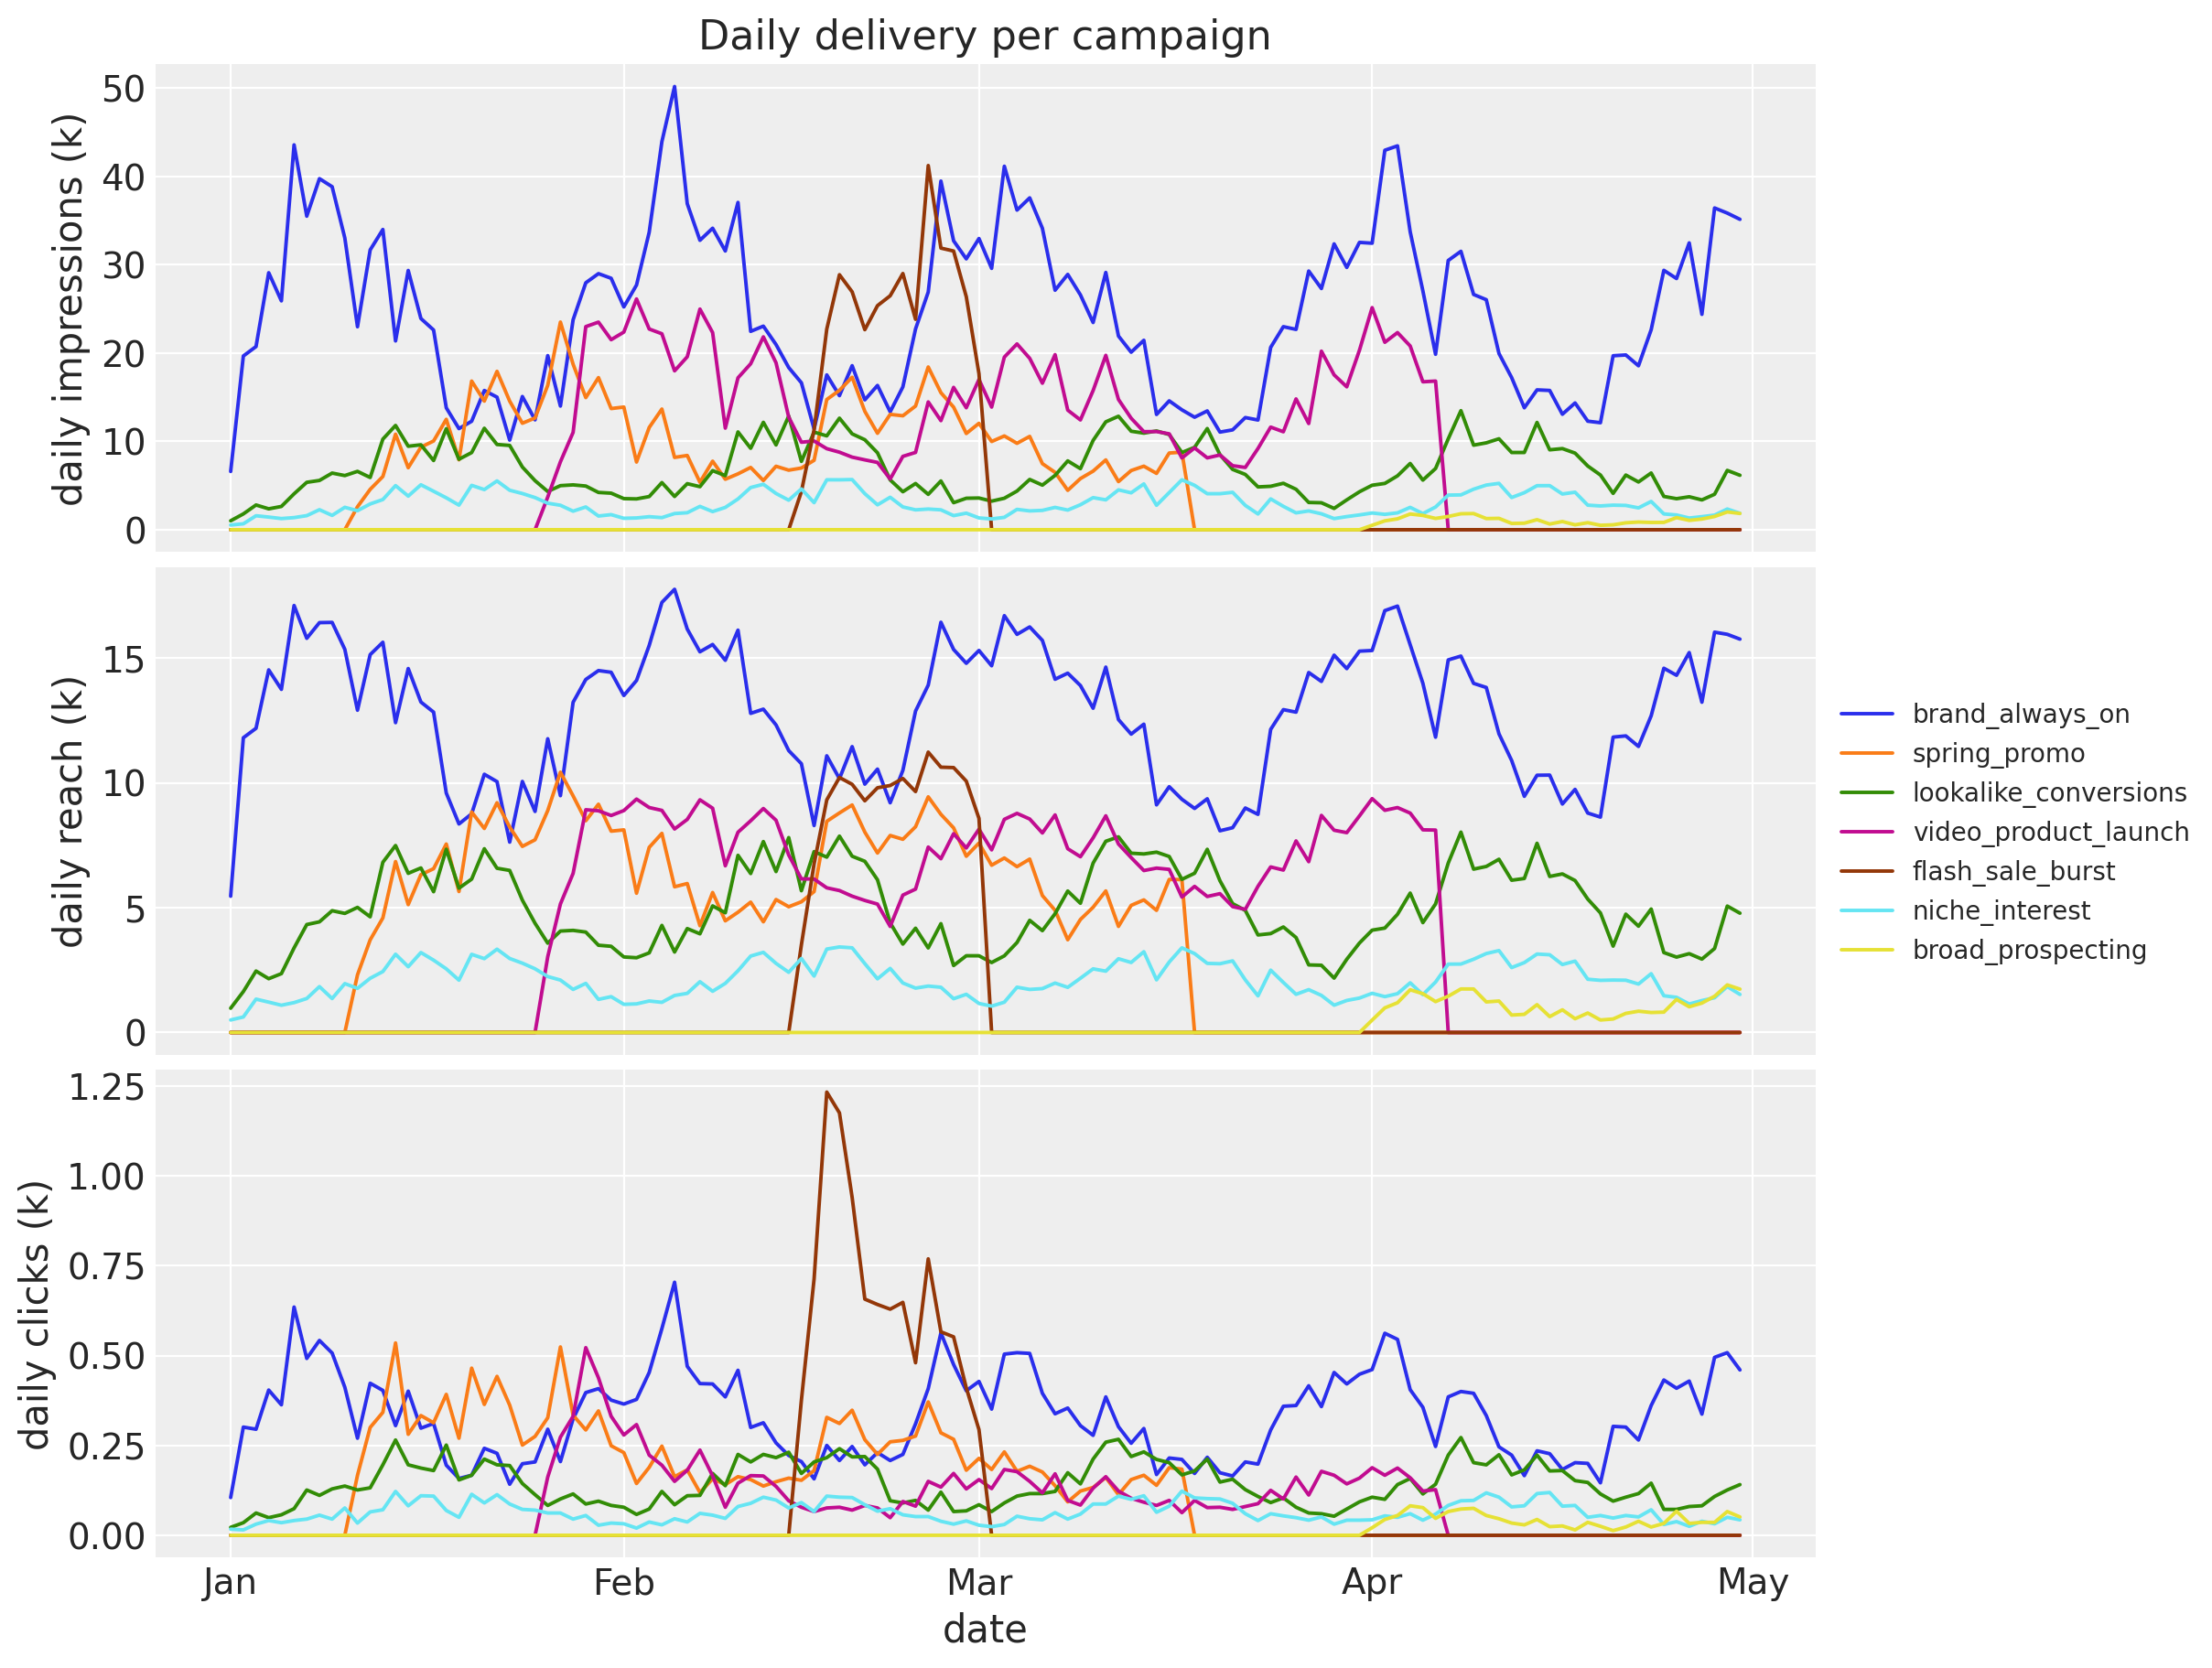

In [5]:
fig, axes = plt.subplots(
    nrows=3, ncols=1, sharex=True, figsize=(12, 9), layout="constrained"
)
for ax, column, label in zip(
    axes,
    ["impressions", "reach", "clicks"],
    ["daily impressions (k)", "daily reach (k)", "daily clicks (k)"],
    strict=True,
):
    wide = data.metrics.pivot(index="date", columns="campaign", values=column).reindex(
        columns=campaigns
    )
    for campaign in campaigns:
        ax.plot(
            wide.index,
            wide[campaign] / 1e3,
            color=colors[campaign],
            lw=1.4,
            label=campaign,
        )
    ax.set(ylabel=label)
axes[0].set(title="Daily delivery per campaign")
axes[-1].set(xlabel="date")
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
fig.legend(
    *axes[0].get_legend_handles_labels(),
    loc="outside center right",
    fontsize=10,
);

> **Fig.** Daily impressions, reach and clicks per campaign. The flight structure is visible: `brand_always_on`, `lookalike_conversions` and `niche_interest` run all 120 days, `spring_promo` and `video_product_launch` run in blocks, `flash_sale_burst` is a 15-day spike, and `broad_prospecting` only starts on April 1st. Reach and impressions move together within a campaign, which is the first hint that daily reach is a delivery measure rather than an audience measure.

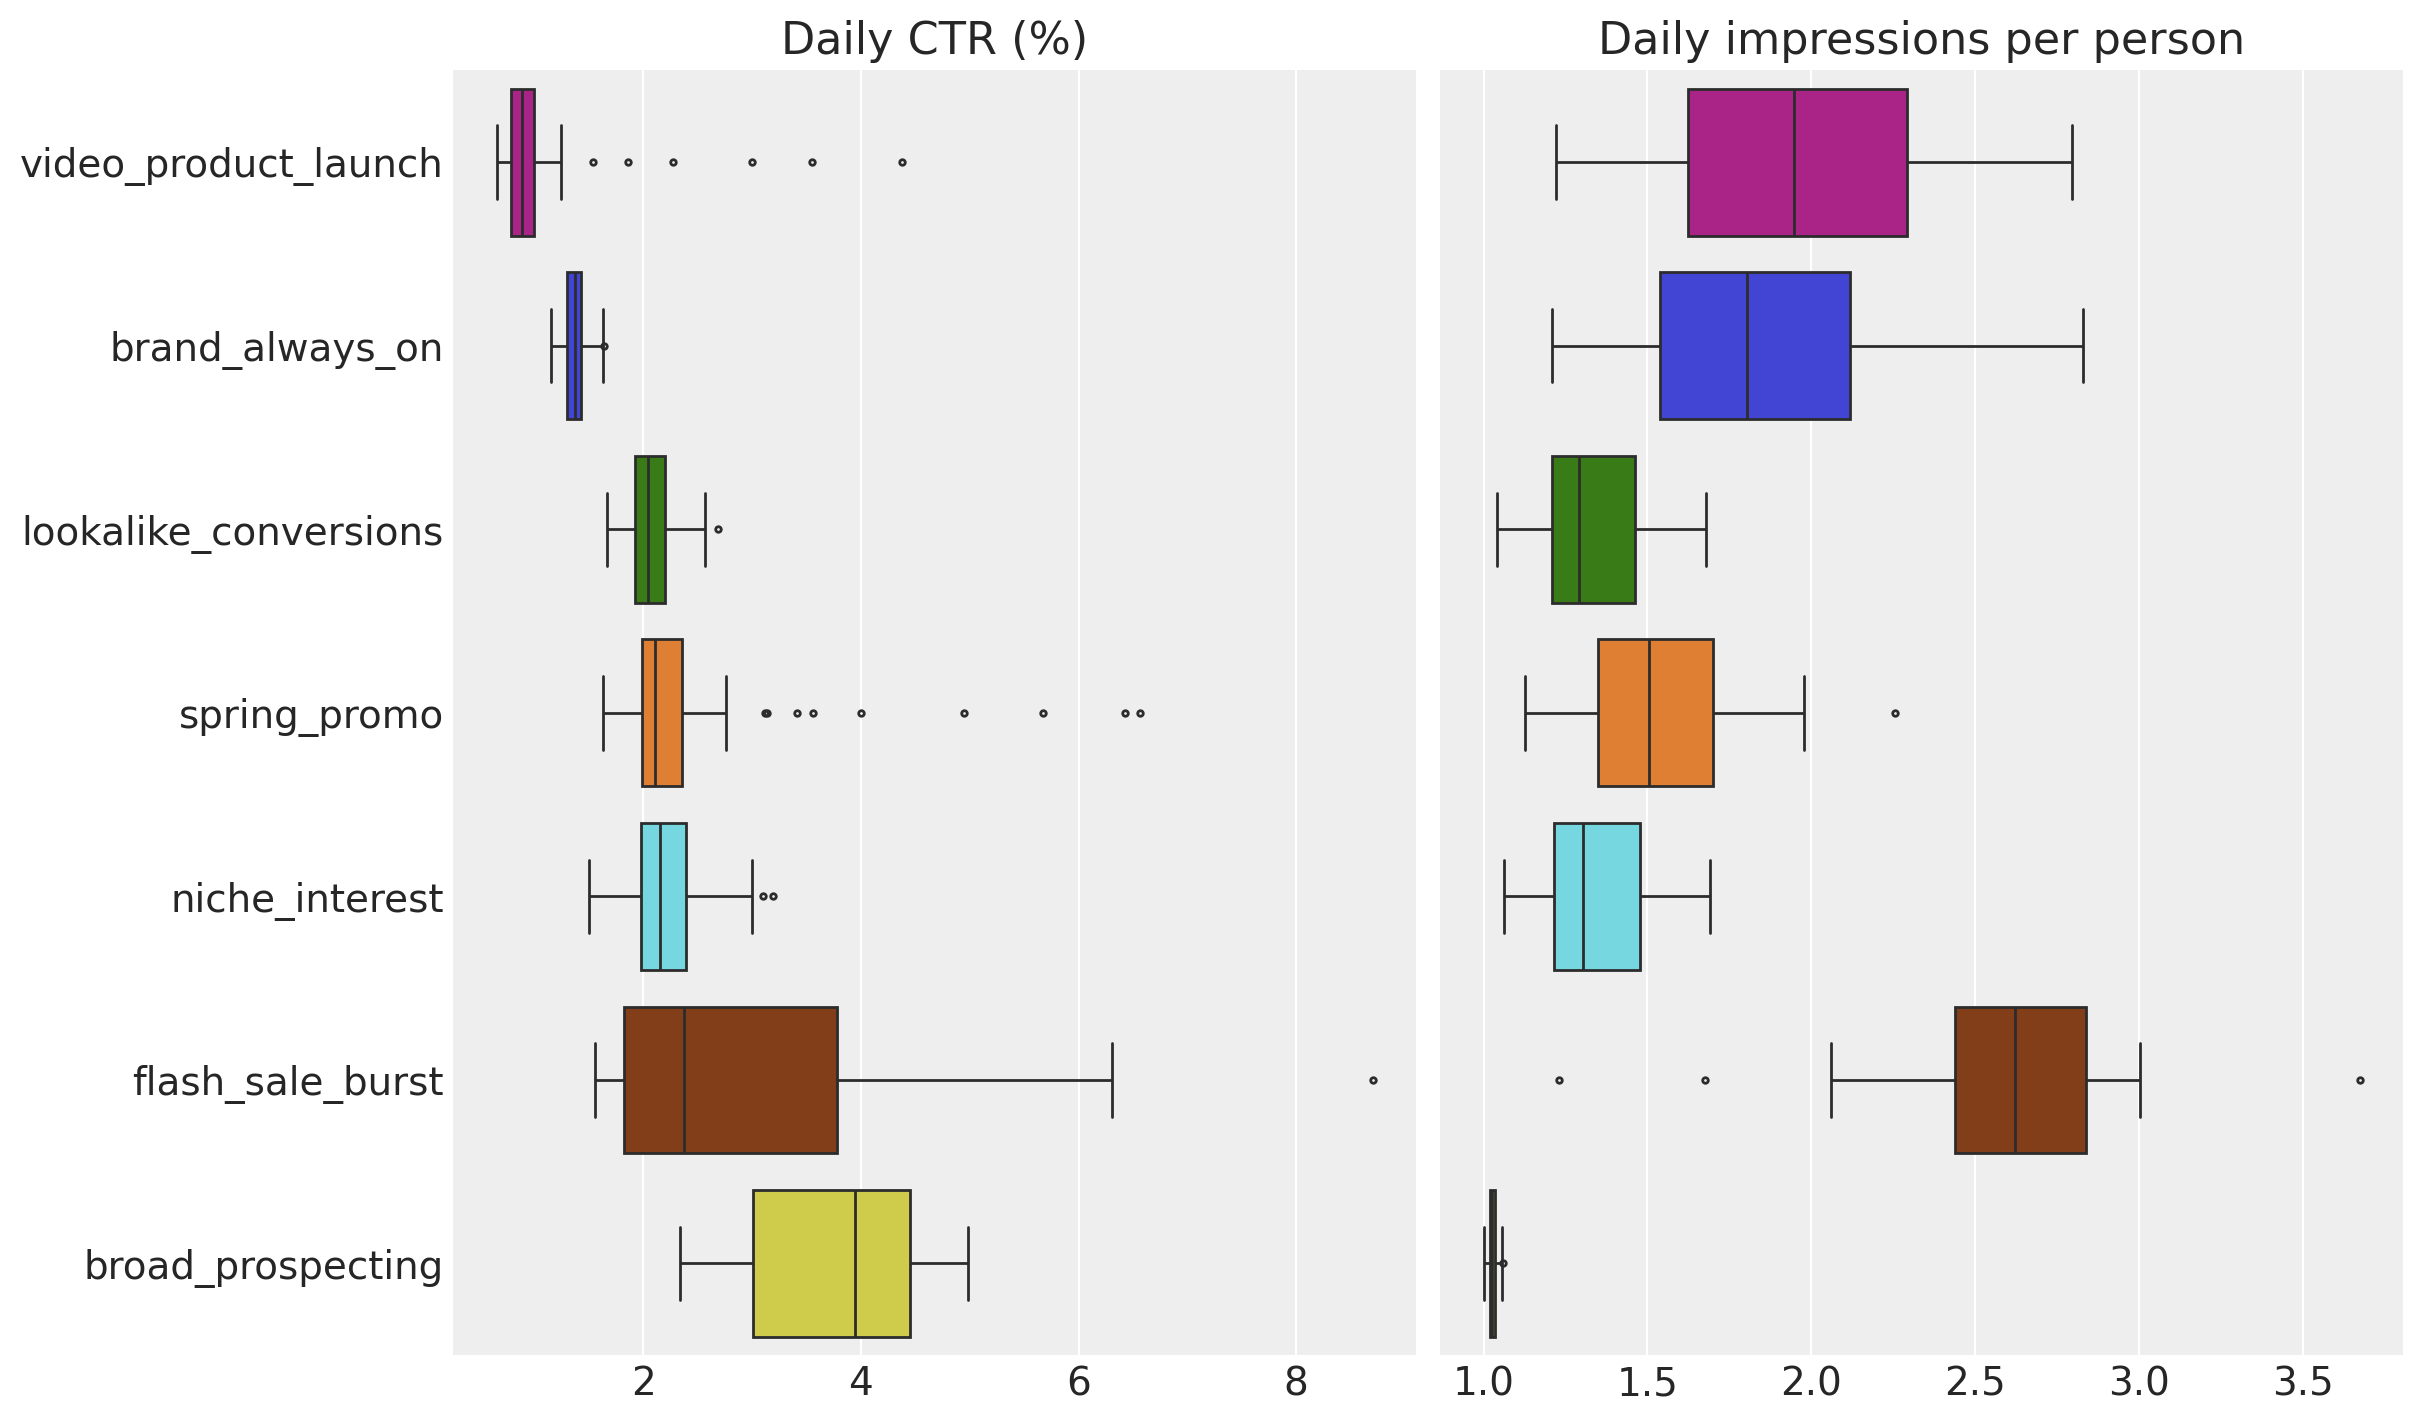

In [6]:
delivered = data.metrics.query("impressions > 0 and reach > 0").assign(
    ctr_pct=lambda df: 100 * df["clicks"] / df["impressions"],
    daily_frequency=lambda df: df["impressions"] / df["reach"],
)
order = delivered.groupby("campaign")["ctr_pct"].median().sort_values().index.tolist()
palette = [colors[campaign] for campaign in order]

fig, (ax_ctr, ax_freq) = plt.subplots(
    ncols=2, sharey=True, figsize=(12, 7), layout="constrained"
)
for ax, column, title in zip(
    [ax_ctr, ax_freq],
    ["ctr_pct", "daily_frequency"],
    ["Daily CTR (%)", "Daily impressions per person"],
    strict=True,
):
    sns.boxplot(
        data=delivered,
        x=column,
        y="campaign",
        order=order,
        hue="campaign",
        hue_order=order,
        palette=palette,
        legend=False,
        fliersize=2,
        ax=ax,
    )
    ax.set(title=title, xlabel="", ylabel="")

> **Fig.** Distribution over delivery days of each campaign's click-through rate and daily frequency, ordered by median CTR. Days with no impressions are excluded, since 298 of the 840 campaign-day cells carry no delivery. Two things matter for what follows. First, CTR differs by campaign by a factor of nearly four, so a click-share split is not a neutral allocation. Second, the small campaigns are the jumpy ones: `broad_prospecting` and `flash_sale_burst` have the widest day-to-day CTR spread, which is exactly the noisiness credibility is designed to discipline.

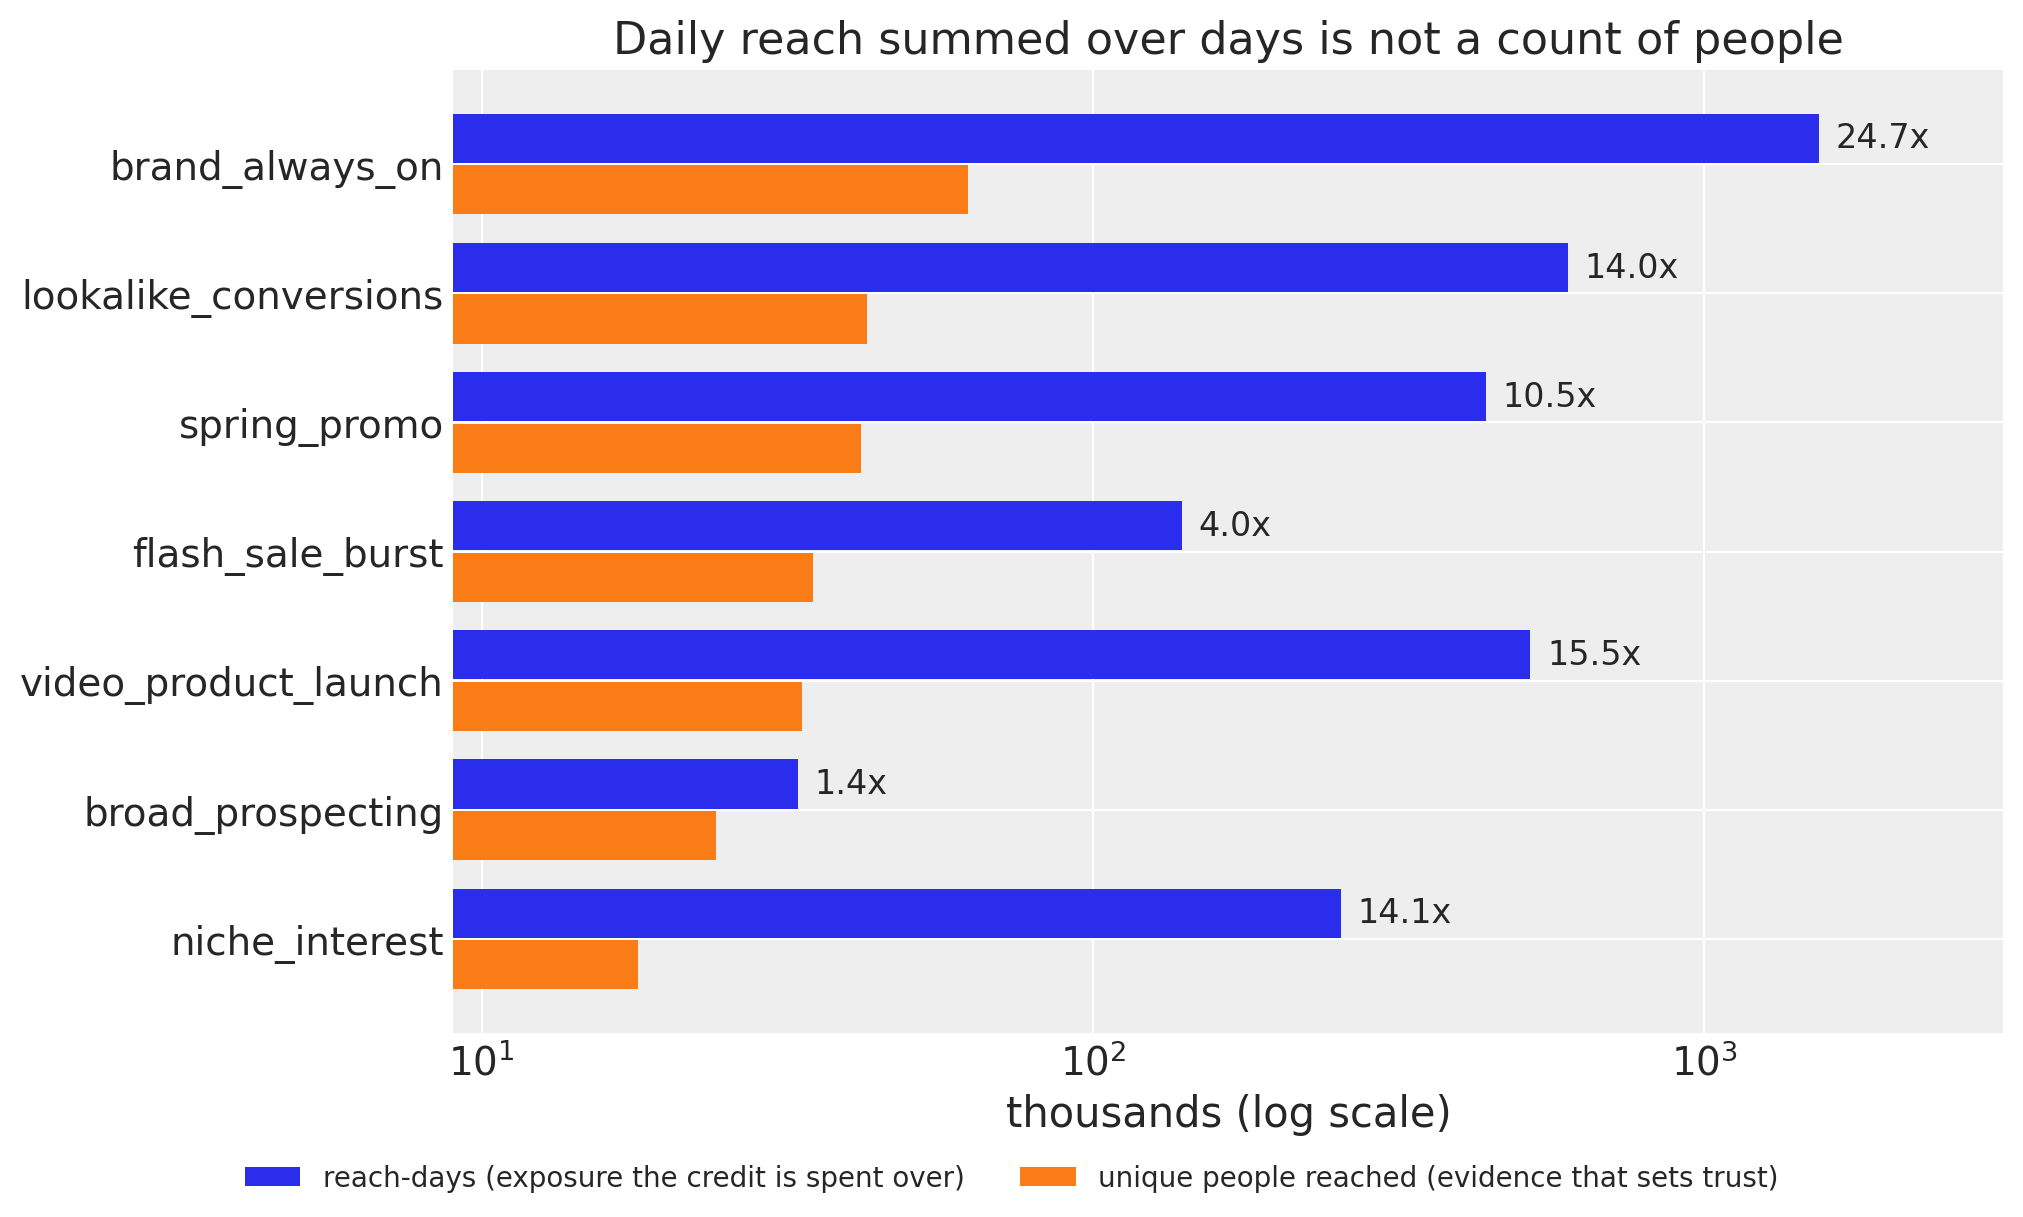

In [7]:
volume = pd.DataFrame(
    {
        "reach_days": campaign_totals(data.metrics, campaigns)["reach_days"],
        "unique_reach": final_unique_reach(data.cum_reach, campaigns),
    }
).sort_values("unique_reach")
thousands = volume / 1e3
positions = np.arange(len(volume))

fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
ax.barh(
    positions + 0.2,
    thousands["reach_days"],
    height=0.38,
    color="C0",
    label="reach-days (exposure the credit is spent over)",
)
ax.barh(
    positions - 0.2,
    thousands["unique_reach"],
    height=0.38,
    color="C1",
    label="unique people reached (evidence that sets trust)",
)
for position, (reach_days, unique_reach) in enumerate(volume.to_numpy()):
    ax.annotate(
        f"{reach_days / unique_reach:.1f}x",
        (reach_days / 1e3, position + 0.2),
        xytext=(6, 0),
        textcoords="offset points",
        va="center",
        fontsize=12,
    )
# leave room on the right for the ratio annotations, and never clip a bar
ax.set(
    xscale="log",
    xlim=(thousands.to_numpy().min() / 2, thousands.to_numpy().max() * 2),
    yticks=positions,
    yticklabels=volume.index,
    xlabel="thousands (log scale)",
    title="Daily reach summed over days is not a count of people",
)
fig.legend(loc="outside lower center", ncol=2, fontsize=10);

> **Fig.** Reach-days against unique people reached, with their ratio annotated. The gap runs from 1.4x for `broad_prospecting`, which barely revisits anyone, to 24.7x for `brand_always_on`, which spends most of its delivery re-reaching people it already has. Summing the daily reach column therefore measures delivery volume, not audience size.

::: {.callout-important title="Two quantities, kept apart"}
The rest of the notebook uses these two words in exactly one sense each, because conflating them is the easiest way to get the arithmetic wrong.

- **Unique reach** $n_c$, from the expanding-window query, is the **evidence**. It enters the trust dial $Z_c$ and nothing else.
- **Reach-days** $\text{reach}_{ct}$, summing to $R_c$, are the **exposure base**. They set the denominator of the rate we model and they spend that rate back out, day by day.

A person reached again tomorrow adds one reach-day but no new evidence about the campaign.
:::

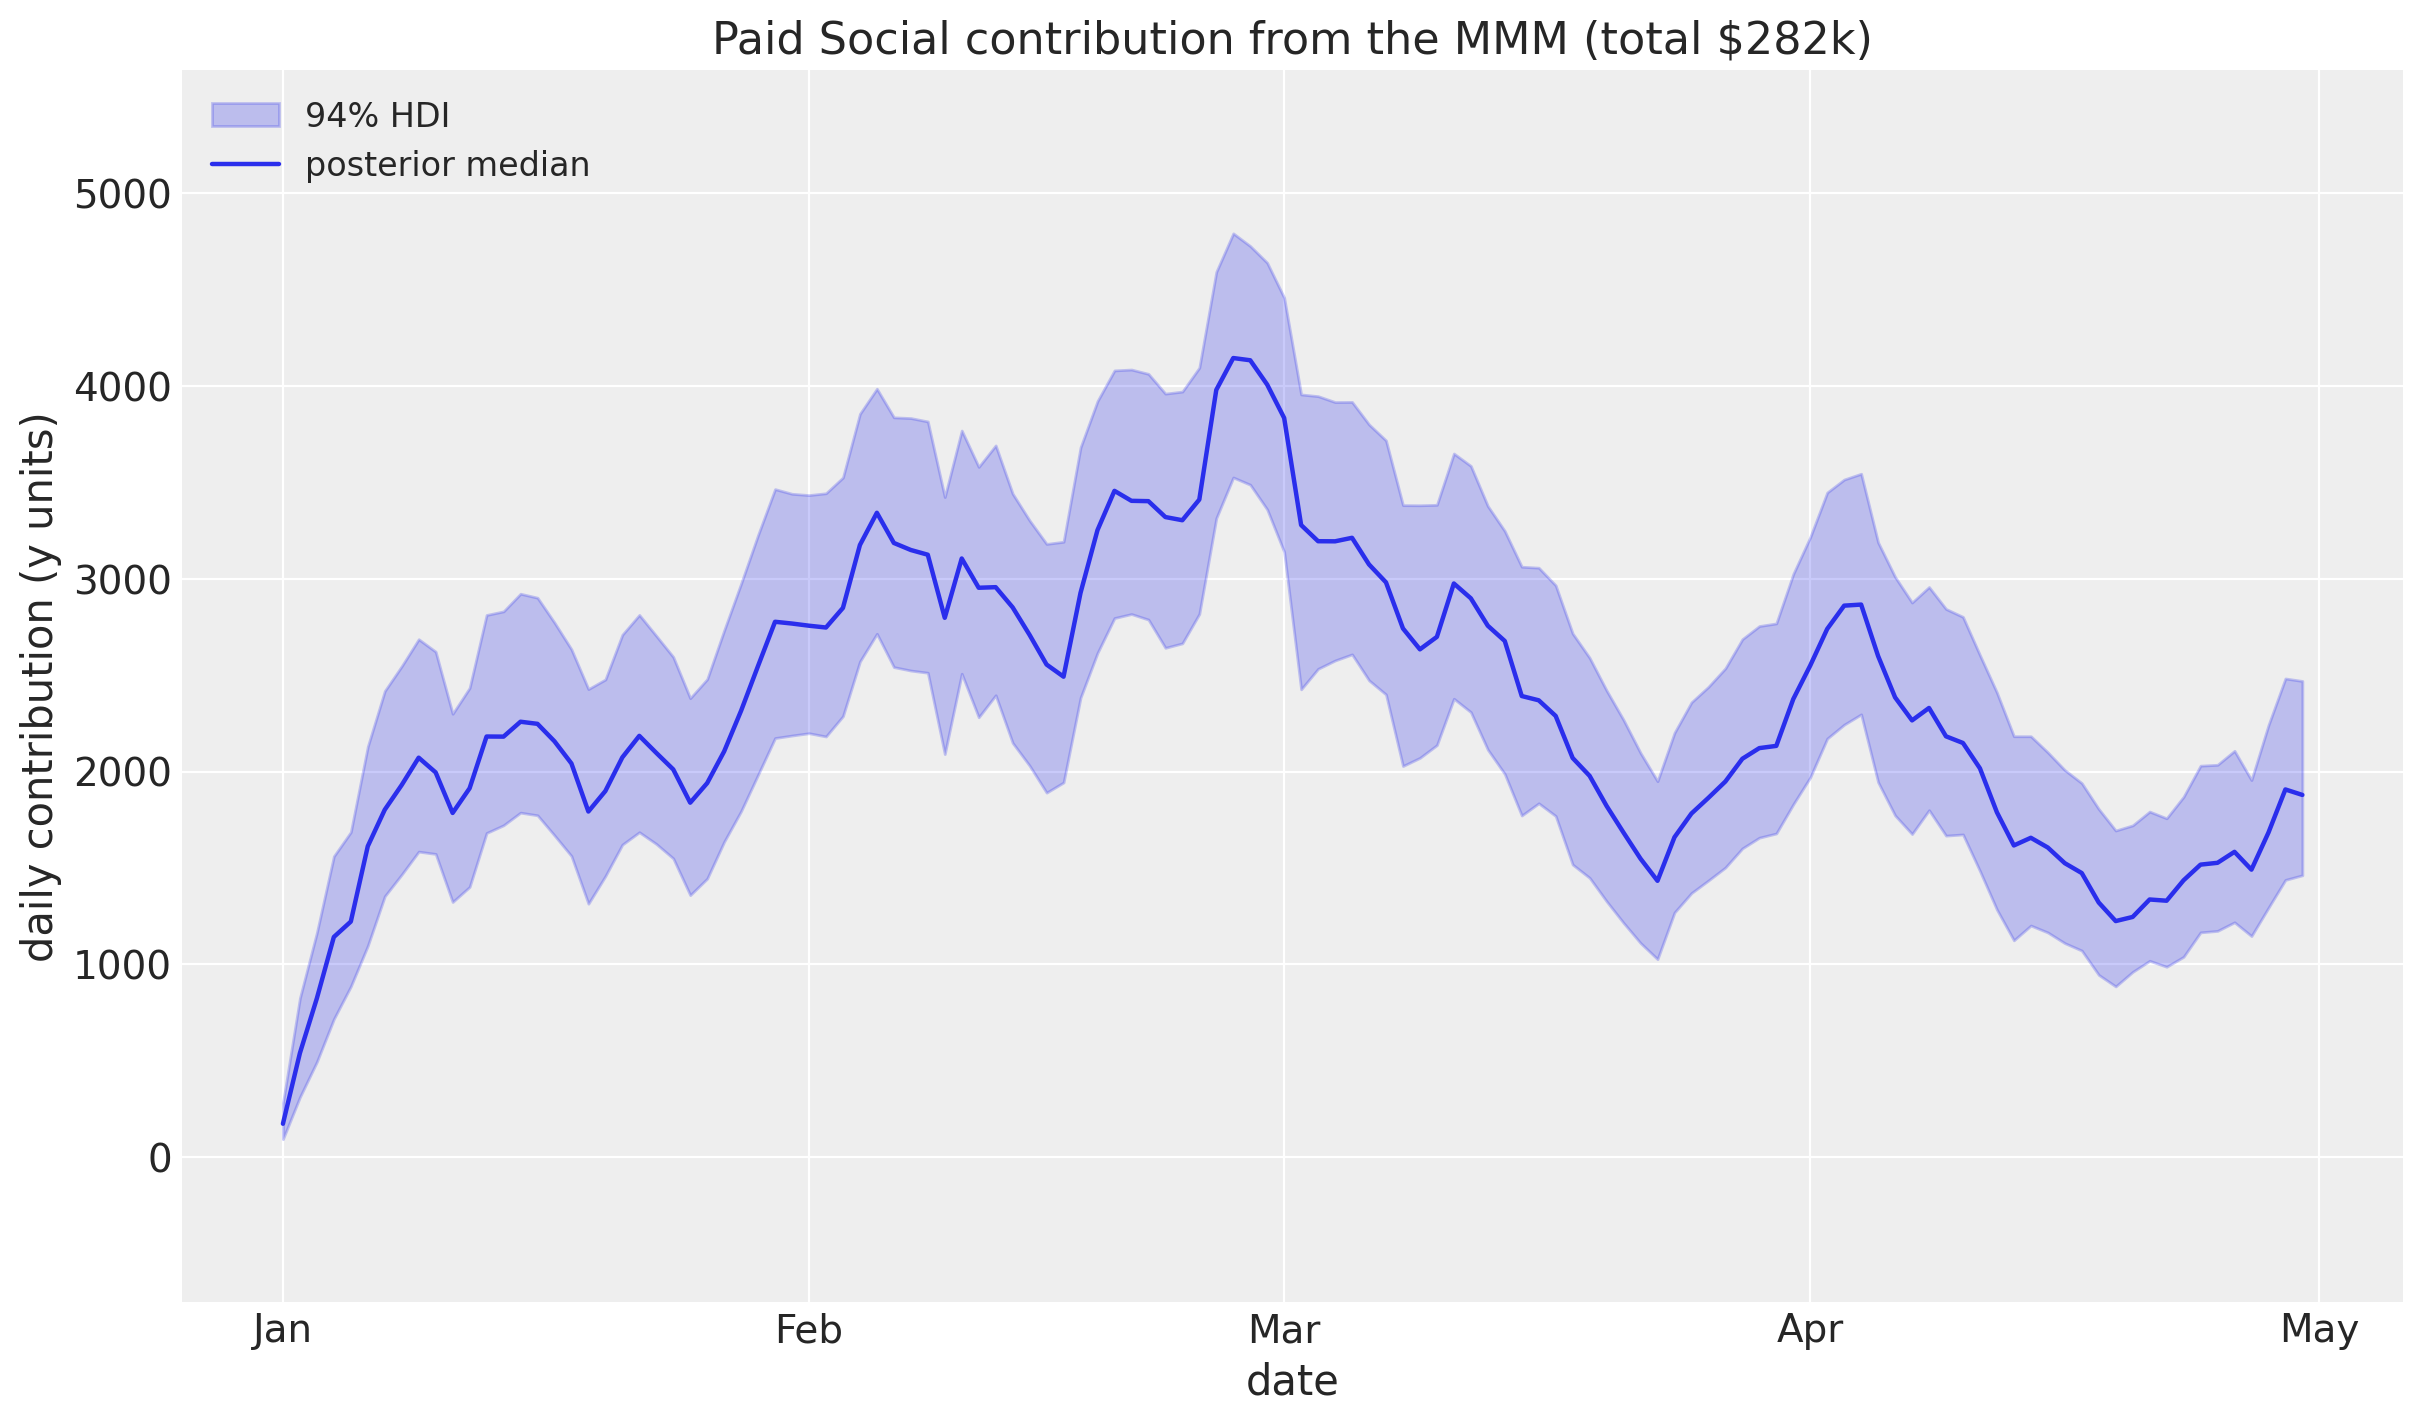

In [8]:
social_daily = data.social.stack(sample=("chain", "draw"))
social_hdi = az.hdi(social_daily, dim="sample")

fig, ax = plt.subplots(figsize=(12, 7), layout="constrained")
ax.fill_between(
    data.mmm["date"],
    social_hdi.sel(ci_bound="lower").to_numpy(),
    social_hdi.sel(ci_bound="upper").to_numpy(),
    color="C0",
    alpha=0.25,
    label=f"{CI_PROB:.0%} HDI",
)
ax.plot(
    data.mmm["date"],
    social_daily.median("sample").to_numpy(),
    color="C0",
    lw=1.6,
    label="posterior median",
)
ax.set(
    title=f"Paid Social contribution from the MMM (total ${channel_total / 1e3:,.0f}k)",
    xlabel="date",
    ylabel="daily contribution (y units)",
)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.margins(y=0.18)
ax.legend(loc="upper left", fontsize=12);

> **Fig.** What the MMM hands us: Paid Social's daily incremental contribution with its 94% credible interval. The area under the curve, about $282k, is the number we split across campaigns. Everything else in the notebook decides the proportions.

## The data you need, and how to build it

The export above is genuinely useful: **exposure** (reach, impressions), **attention** (clicks and CTR), and **cost** (CPM). It is also all most teams ever look at. For our question, who deserves the channel's credit, it has two blind spots.

- **Its `reach` is duplicated across days.** The previous figure measured the damage: summing the column gives impressions-flavoured volume, not people, so it cannot tell you when a campaign has **saturated its audience**, the point where more spend just re-hits the same faces.
- **It says nothing about overlap.** Two campaigns can spend on largely the same people, and this table shows them as independent. Ignore that and any per-campaign credit double-counts the shared audience.

Unduplicated audience growth and cross-campaign overlap are the signals this analysis runs on, and neither is a column you can export directly. The good news is that you can build both from the same platform or API, with a particular **query pattern** and no extra tracking.

**1. Unduplicated reach growth, the "expanding window."** Do not pull one report of daily reach. Pull a *series* of reports where you fix the start date and push the **end** date out one day at a time: `[start to day 0]`, then `[start to day 1]`, then `[start to day 2]`, through `[start to day N]`. The platform de-duplicates *within* each report, so each one is the true unique reach so far, and the **difference between consecutive reports is the count of genuinely new people** reached that day. Stitch them together and you get a clean audience-growth curve instead of a duplicated daily count.

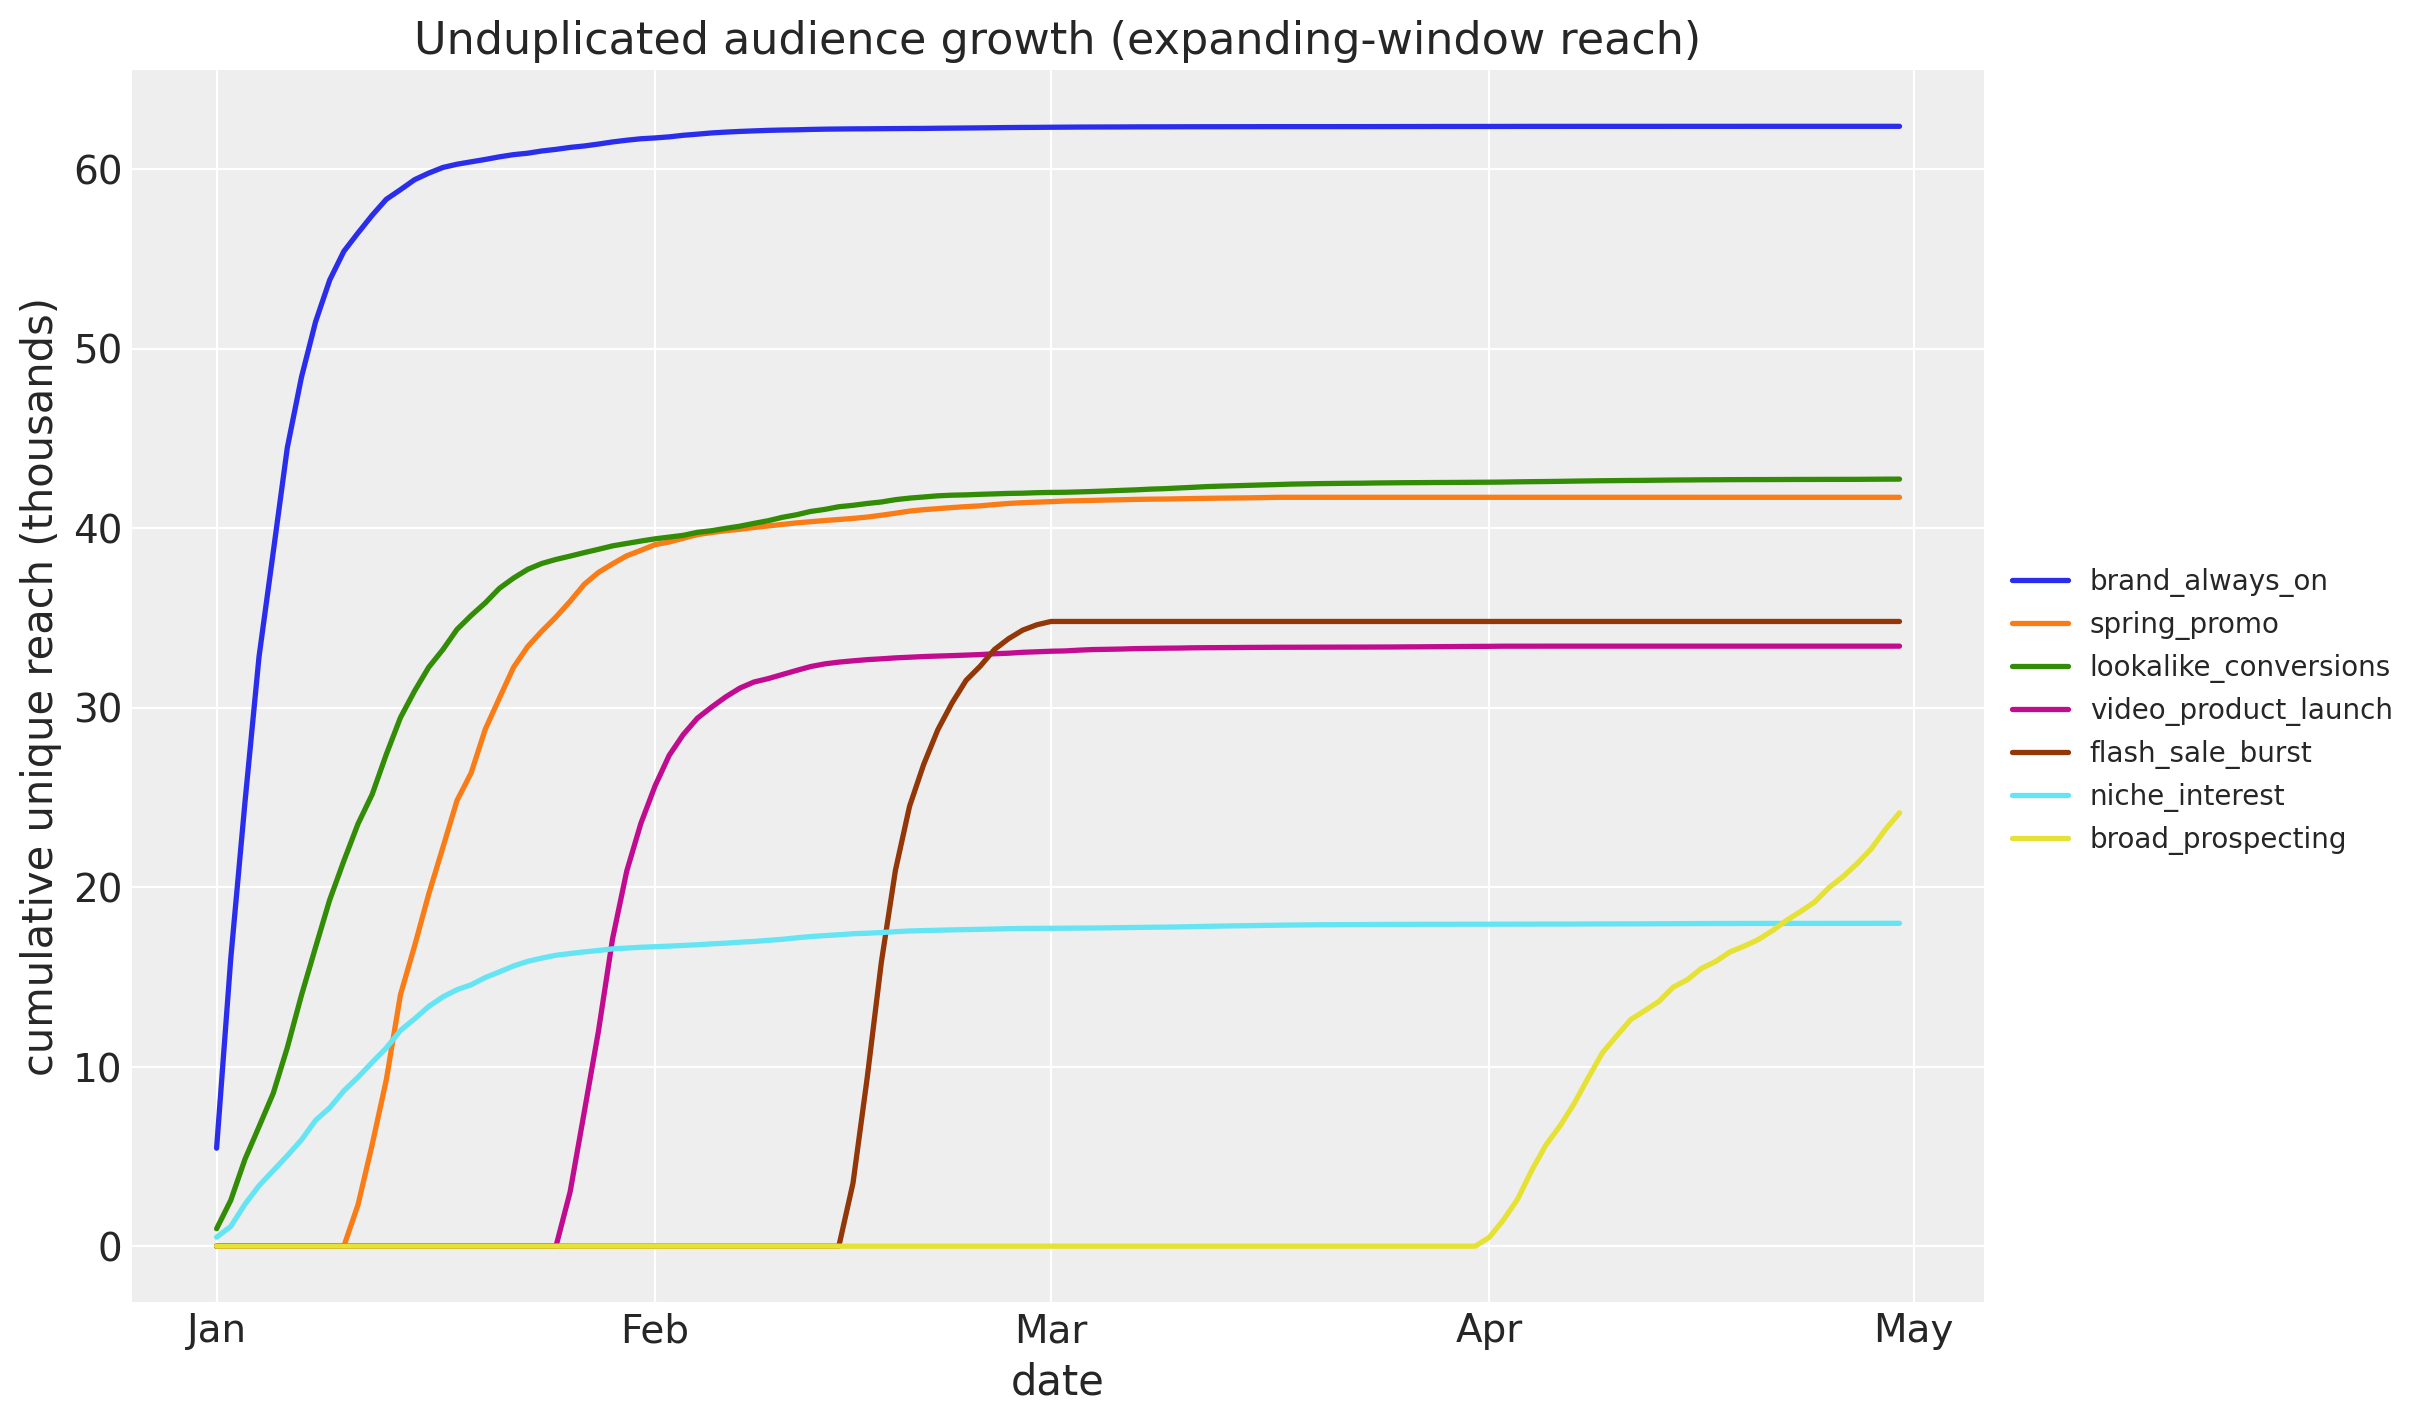

In [9]:
fig, ax = plt.subplots(figsize=(12, 7), layout="constrained")
for campaign in campaigns:
    ax.plot(
        data.cum_reach.index,
        data.cum_reach[campaign] / 1e3,
        lw=1.9,
        color=colors[campaign],
        label=campaign,
    )
ax.set(
    title="Unduplicated audience growth (expanding-window reach)",
    xlabel="date",
    ylabel="cumulative unique reach (thousands)",
)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
fig.legend(loc="outside center right", fontsize=10);

> **Fig.** The expanding-window result: cumulative unique reach per campaign. Most curves are C-shaped, steep while the campaign keeps finding new people and then flattening as it exhausts its audience, and that flattening point is the audience saturation the raw daily table cannot reveal. Scales differ enormously, from `brand_always_on` saturating near 62k unique users to `niche_interest` near 18k. The exception is `broad_prospecting`: it launched on April 1st against a very large audience and is still climbing when the window closes, so it has no saturation knee, just a left-censored growth curve.

**2. Campaign overlap, by pairwise inclusion-exclusion.** The same multi-report trick, asked of campaign *groups*. For each pair, pull reach for A alone, for B alone, and for the combined A∪B group. The shared audience is then

$$\text{overlap}(A, B) = \text{Reach}(A) + \text{Reach}(B) - \text{Reach}(A \cup B).$$

Repeat over the pairs (and larger groups) you care about to fill an N by N matrix. Its diagonal is each campaign's own audience size and the off-diagonals are shared users, zero where targeting is disjoint. In this synthetic example the matrix describes **targeting universes**, so a diagonal is a potential audience size rather than the realized cumulative unique reach used below.

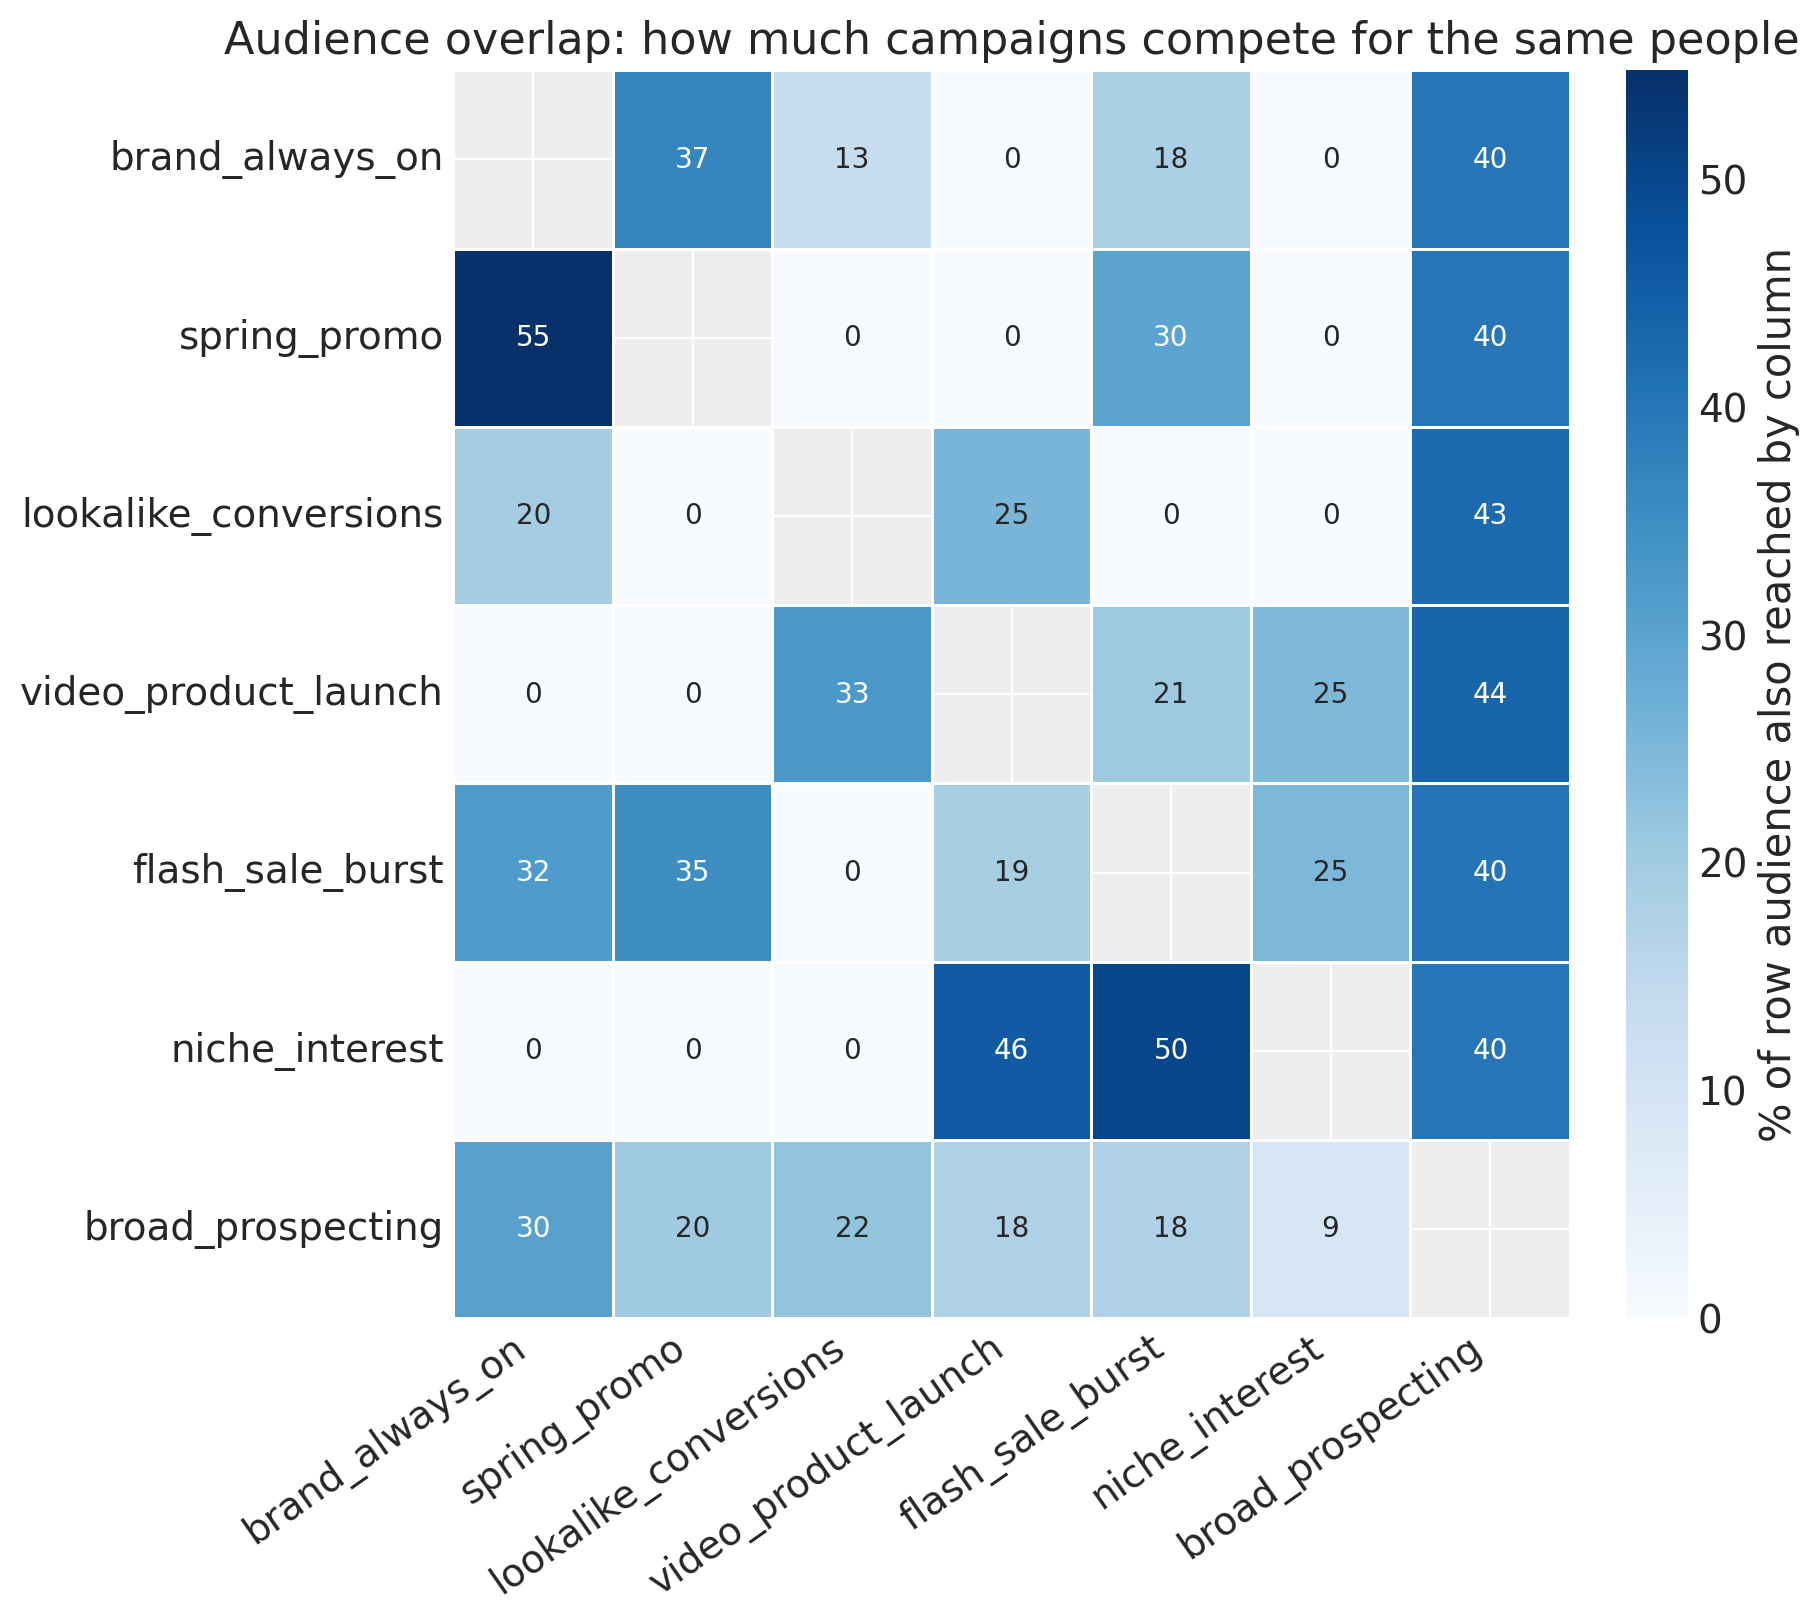

In [10]:
overlap = data.overlap.reindex(index=campaigns, columns=campaigns)
overlap_pct = 100 * overlap.div(pd.Series(np.diag(overlap), index=campaigns), axis=0)

fig, ax = plt.subplots(figsize=(9, 8), layout="constrained")
sns.heatmap(
    overlap_pct,
    mask=np.eye(len(campaigns), dtype=bool),
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "% of row audience also reached by column"},
    ax=ax,
)
ax.set(
    title="Audience overlap: how much campaigns compete for the same people",
    xlabel="",
    ylabel="",
)
for tick_label in ax.get_xticklabels():
    tick_label.set(rotation=35, horizontalalignment="right")

> **Fig.** Audience overlap from the pairwise reach queries. Read each row as: of that campaign's targeting universe, what share is also targeted by the campaign in each column. Dark cells are contested audiences, and 55% of `spring_promo`'s audience is also targeted by `brand_always_on`. Blank cells on the diagonal are trivially 100%, and pale cells are close to disjoint targeting. This is the competition structure inside your own account.

This notebook only needs the **reach** signal from technique 1. The overlap matrix from technique 2 is not used below, but it is what lets you see how much your campaigns are fighting over the same people, so it is worth building at the same time.

## The noisy own story

To turn the dial we need two numbers per campaign: **how much evidence it carries**, its unique reach, and **its own noisy story**, a rough guess at how much revenue it drove per unit of exposure.

For that own story we do something deliberately crude, exactly the kind of back-of-envelope split a platform dashboard invites. We take the MMM's total social credit, hand it out in proportion to each campaign's **clicks**, and express the result **per reach-day**:

$$y_c=\log\left(\frac{T \cdot \text{clickshare}_c}{R_c}\right),\qquad R_c=\sum_t \text{reach}_{ct}.$$

It is noisy and non-incremental on purpose: this is the shaky signal we want to discipline, not trust. Two details are worth stating plainly.

- **The denominator is reach-days, not people.** That is the unit the daily allocation later spends, and matching the two is what makes the credit add up. Divide by unique reach instead and full trust in the click signal no longer reproduces the click split, because a campaign's frequency leaks into its share.
- **We work with the log of the rate**, so "twice as effective" is the same size step whether a campaign is weak or strong.

One more thing to be precise about, since the framing is "one number you trust, seven shaky signals". The MMM total $T$ enters $y_c$ as $\log T + \log \text{clickshare}_c - \log R_c$, an identical shift for every campaign, which the collective mean $\mu$ absorbs. So the MMM sets the level of the whole channel, and the *ranking* of the direct estimates comes from click share and exposure alone.

In [11]:
def naive_click_share(clicks: pd.Series) -> pd.Series:
    """Platform-style split of the channel total, proportional to clicks."""
    return clicks / clicks.sum()


def naive_log_rate(
    channel_total: float, click_share: pd.Series, exposure: pd.Series
) -> pd.Series:
    """Log contribution per unit of exposure implied by the naive click split."""
    return np.log(channel_total * click_share / exposure)


def direct_estimates(data: CampaignData) -> pd.DataFrame:
    """Per-campaign evidence, exposure, and the noisy direct estimate y_c."""
    campaigns = data.campaigns
    totals = campaign_totals(data.metrics, campaigns)
    channel_total = float(data.social.sum("date").mean())
    click_share = naive_click_share(totals["clicks"])
    return pd.DataFrame(
        {
            "unique_reach": final_unique_reach(data.cum_reach, campaigns),
            "reach_days": totals["reach_days"].astype(float),
            "clicks": totals["clicks"],
            "click_share": click_share,
            "naive_rate": channel_total * click_share / totals["reach_days"],
            "y_direct": naive_log_rate(
                channel_total, click_share, totals["reach_days"]
            ),
        }
    )


direct = direct_estimates(data)
y_direct = direct["y_direct"]
unique_reach = direct["unique_reach"]
direct.sort_values("unique_reach", ascending=False).round(4)

,unique_reach,reach_days,clicks,click_share,naive_rate,y_direct
brand_always_on,62386.0,1541137.0,40073,0.3903,0.0714,-2.6399
lookalike_conversions,42733.0,597676.0,16891,0.1645,0.0776,-2.5566
spring_promo,41719.0,438462.0,15985,0.1557,0.1001,-2.3020
flash_sale_burst,34802.0,139620.0,10084,0.0982,0.1982,-1.6183
video_product_launch,33427.0,519340.0,10628,0.1035,0.0562,-2.8794
broad_prospecting,24140.0,32921.0,1294,0.0126,0.1079,-2.2267
niche_interest,17987.0,254475.0,7709,0.0751,0.0831,-2.4872


The picture below is the heart of the problem: each campaign's own noisy story, laid against how much evidence it carries. The bands get **wider the fewer people a campaign reached**, since less evidence means more uncertainty about its rate.

Two campaigns anchor the range. **`flash_sale_burst`** sits highest: it ran 15 days and re-reached each person only four times, so its clicks are divided by very little exposure. **`video_product_launch`** sits lowest, with heavy delivery and the worst CTR in the account. **`niche_interest`** carries the least evidence of all, so its band is the widest on the chart even though its rate is close to the middle.

The dashed line is the **collective mean**: the reach-weighted average of the seven naive log rates, and a plug-in stand-in for the $\mu$ the model will estimate. It is the level each campaign gets pulled toward, in proportion to how little evidence it carries.

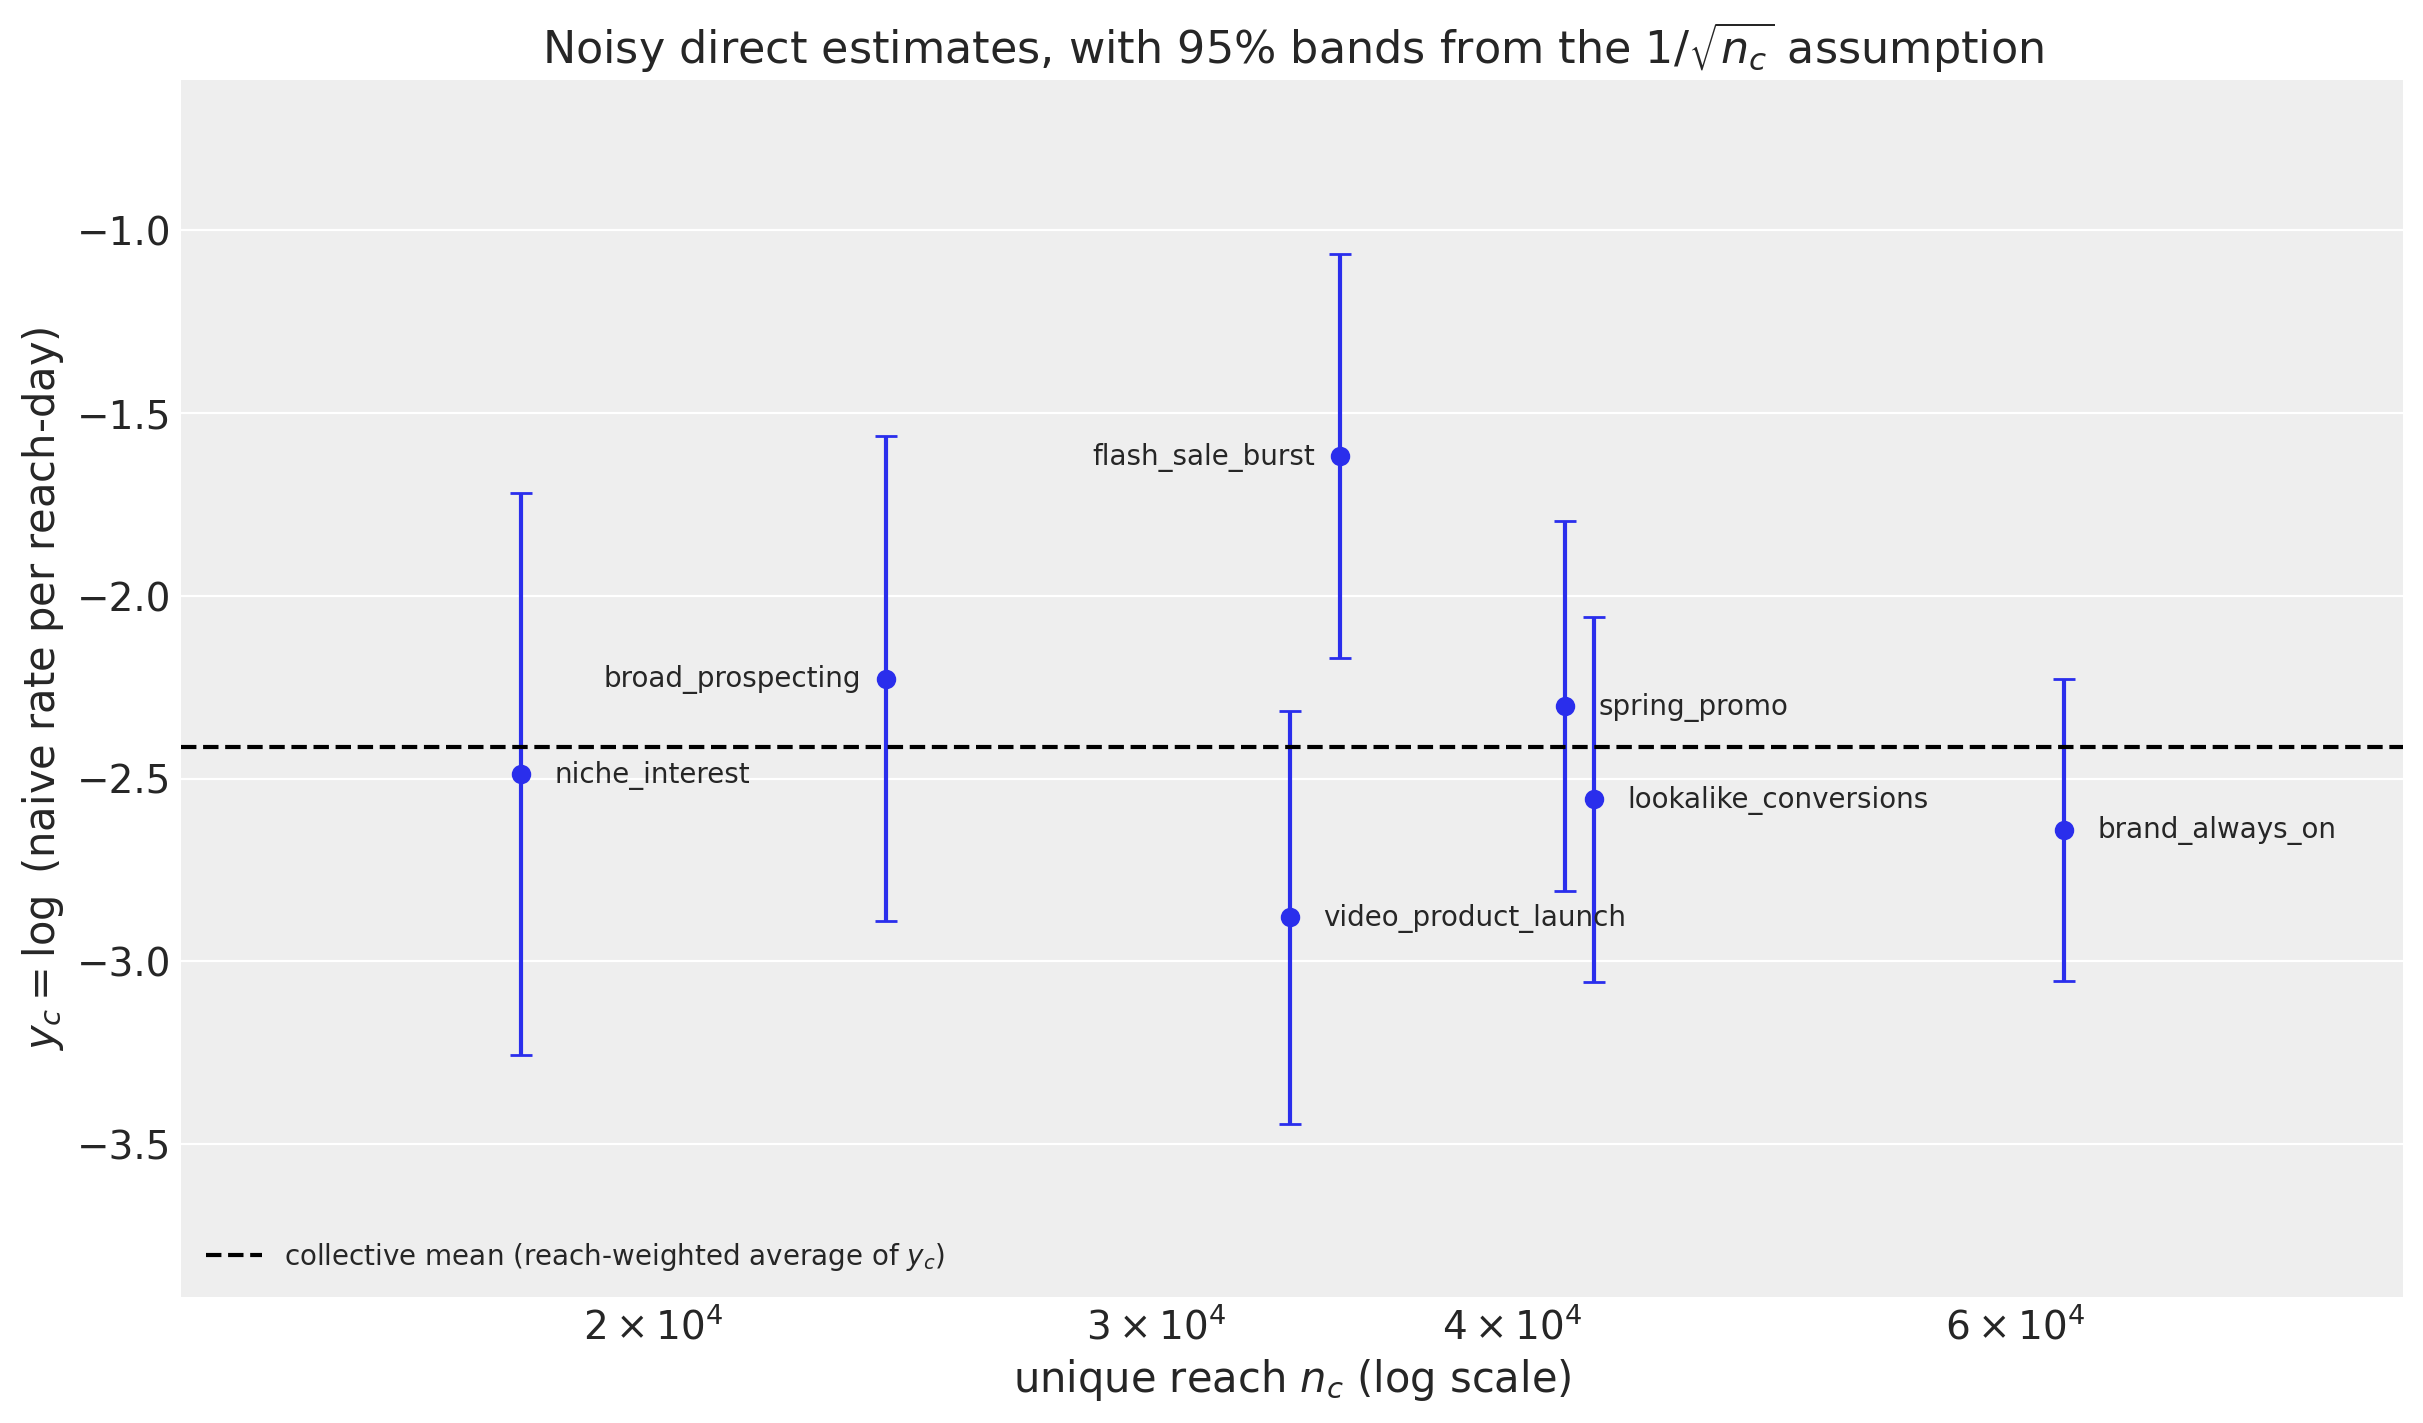

In [12]:
def robust_scale(values: pd.Series) -> float:
    """Outlier-resistant estimate of the dispersion of the direct estimates."""
    return float(1.4826 * np.median(np.abs(values - np.median(values))))


relative_reach = unique_reach / unique_reach.mean()
plug_in_scale = robust_scale(y_direct)
standard_error = np.sqrt(plug_in_scale**2 / relative_reach)
collective_mean = float(np.average(y_direct, weights=unique_reach))

ordered = unique_reach.sort_values().index
fig, ax = plt.subplots(figsize=(12, 7), layout="constrained")
ax.errorbar(
    unique_reach[ordered],
    y_direct[ordered],
    yerr=1.96 * standard_error[ordered],
    fmt="o",
    capsize=4,
    color="C0",
)
ax.axhline(
    collective_mean,
    ls="--",
    color="black",
    label="collective mean (reach-weighted average of $y_c$)",
)
label_to_the_left = {"broad_prospecting", "flash_sale_burst"}
for campaign in ordered:
    to_the_right = campaign not in label_to_the_left
    ax.annotate(
        campaign,
        (unique_reach[campaign], y_direct[campaign]),
        xytext=(12, -3) if to_the_right else (-9, -3),
        textcoords="offset points",
        ha="left" if to_the_right else "right",
        fontsize=10,
    )
ax.margins(x=0.22, y=0.20)
ax.set(
    xscale="log",
    title="Noisy direct estimates, with 95% bands from the $1/\\sqrt{n_c}$ assumption",
    xlabel="unique reach $n_c$ (log scale)",
    ylabel="$y_c=\\log$ (naive rate per reach-day)",
)
ax.legend(loc="lower left", fontsize=10);

> **Fig.** Each campaign's noisy own story plotted against its evidence, on a log reach axis. The band shape is the modelling assumption that a campaign's noise falls like $1/\sqrt{n_c}$; its scale here is a crude plug-in, the outlier-resistant spread of the seven direct estimates, and the model replaces it with a fitted $s^2$ in the next section. `niche_interest` carries the least evidence and gets the widest band; `brand_always_on` carries the most and gets the narrowest.

## Turning the dial

Now we let the data set the dial. Instead of decreeing "a campaign is only half-trusted until it reaches 50k people", or handing everyone a flat `Z = 0.5` by gut, we write the blend down as a small model and let it learn, alongside the channel average itself, the **two numbers that set the dial**, estimated from the seven campaigns together:

- **How much campaigns genuinely differ** from one another ($\tau$). If campaigns are basically alike, the group average is very informative and everyone gets pulled toward it hard.
- **How noisy one campaign's own signal is** for a given amount of evidence ($s^2$). The noisier the signal, the more reach it takes to earn trust.

Their ratio is the evidence threshold, $k = s^2/\tau^2$, and each campaign's dial follows automatically: $Z_c = n_c/(n_c+k)$. Because we fit this as a Bayesian model we do not get a single $Z$ per campaign, we get a distribution. Even the trust carries an error bar.

::: {.callout-note title="You are already setting Z, you just do not call it that"}
Every day-to-day call about campaign performance is a Z in disguise, set by gut.

- **Reading the dashboard at face value is `Z = 1`.** "This campaign shows 8x ROAS, that one 2x, move the budget" trusts each number fully, no matter how few people it reached. It is why small campaigns swing between hero and flop week to week.
- **Splitting by spend, or evenly, is `Z = 0`.** You have thrown away each campaign's own signal and leaned entirely on the average.
- **"Wait for enough conversions before you trust the CPA" is choosing `k`**, the evidence threshold where belief kicks in. Meta and Google do exactly this with their campaign *learning phase*.
- **"That 12x looks too good, tiny audience, call it maybe 4x" is a blend.** That is credibility done in your head, at an unspoken Z somewhere between 0 and 1.

You cannot avoid picking a Z. The only question is whether it is an arbitrary gut call that shifts by analyst and by mood, or **one value estimated from how your campaigns actually behave**, with its uncertainty attached. That is all the model below does.
:::

The model is short, and it is the entire method. Everything before it was preparing its two inputs, and everything after it is presentation.

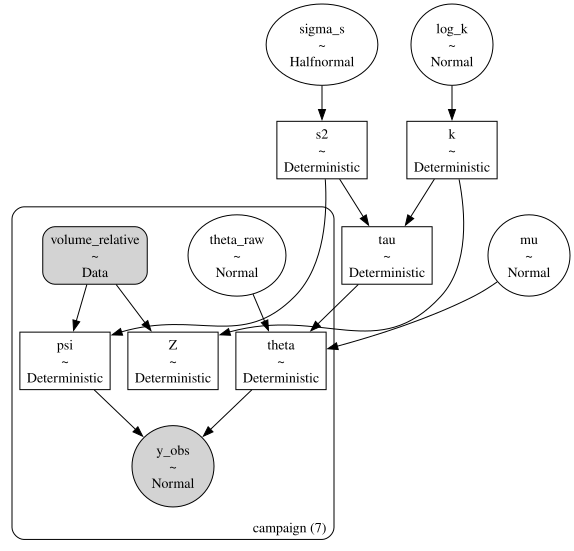

In [13]:
def build_credibility_model(
    y_direct: pd.Series,
    volume: pd.Series,
    *,
    sigma_s_scale: float = 0.5,
    log_k_sd: float = 0.75,
) -> pm.Model:
    """Buhlmann credibility model in which volume sets each campaign's trust dial."""
    campaigns = list(y_direct.index)
    volume_relative = (volume / volume.mean()).reindex(campaigns).to_numpy()
    with pm.Model(coords={"campaign": campaigns}) as model:
        volume_data = pm.Data("volume_relative", volume_relative, dims="campaign")
        mu = pm.Normal("mu", mu=float(y_direct.mean()), sigma=1.0)
        log_k = pm.Normal("log_k", 0.0, log_k_sd)
        k = pm.Deterministic("k", pm.math.exp(log_k))
        sigma_s = pm.HalfNormal("sigma_s", sigma_s_scale)
        s2 = pm.Deterministic("s2", sigma_s**2)
        tau = pm.Deterministic("tau", pm.math.sqrt(s2 / k))
        psi = pm.Deterministic("psi", s2 / volume_data, dims="campaign")
        pm.Deterministic("Z", volume_data / (volume_data + k), dims="campaign")
        theta_raw = pm.Normal("theta_raw", 0.0, 1.0, dims="campaign")
        theta = pm.Deterministic("theta", mu + tau * theta_raw, dims="campaign")
        pm.Normal(
            "y_obs",
            mu=theta,
            sigma=pm.math.sqrt(psi),
            observed=y_direct.to_numpy(),
            dims="campaign",
        )
    return model


credibility_model = build_credibility_model(y_direct, unique_reach)
pm.model_to_graphviz(credibility_model)

> **Fig.** The model graph. The plate holds the seven campaigns, `volume_relative` is the data node carrying each campaign's unique reach divided by the average unique reach, and everything inside the plate is per-campaign. Only `mu`, `log_k` and `sigma_s` are global.

Reading it line by line: `mu` is the channel-average effectiveness every campaign is judged against, `sigma_s` sets how noisy one campaign's own signal is per unit of evidence, `psi` is that noise for a given campaign, `Z` is the trust dial that falls out, and `theta` is each campaign's trust-adjusted effectiveness, the blend of its own story and the group average.

The parametrization is chosen for the sampler and for interpretability. We sample $\log k$ and derive $\tau=\sqrt{s^2/k}$, rather than sampling $\tau$ and $s^2$ separately, for two reasons. First, $k$ is the actuarial quantity of interest: the amount of reach at which a campaign earns half its own trust, so putting a prior on it is a statement a media analyst can argue with. Second, the $(\tau, s^2)$ pair is only weakly identified from seven campaigns: sampling those two directly produced divergences at `target_accept=0.95` while this version produces none.

::: {.callout-warning title="Why the prior matters here: a weak identification"}
Marginalising out $\theta_c$, the model says

$$y_c \sim \text{Normal}\left(\mu,\; \tau^2+\psi_c\right), \qquad \tau^2+\psi_c = s^2\left(\frac{1}{k}+\frac{1}{n^{\text{rel}}_c}\right),$$

so $s^2$ and $k$ enter only through that combination. What separates them is the spread of relative reach across campaigns, which here runs from 0.49 to 1.70. With seven campaigns and a 3.5-fold spread, that separation is weak, and the posterior for $k$ stays wide. This is the honest reason the priors below deserve a check rather than a shrug.

One more disclosure: $\mu$'s prior is centered on the mean of the observed $y_c$. With a prior standard deviation of 1.0 against a data spread of 0.40 the effect is mild, but it is the data informing a prior, not prior information.
:::

Sampling: [log_k, mu, sigma_s, theta_raw, y_obs]


,unique_reach,prior_median_Z,prior_Z_2.5%,prior_Z_97.5%
brand_always_on,62386.0,0.634,0.289,0.876
lookalike_conversions,42733.0,0.542,0.218,0.828
spring_promo,41719.0,0.537,0.214,0.825
flash_sale_burst,34802.0,0.491,0.185,0.797
video_product_launch,33427.0,0.481,0.179,0.791
broad_prospecting,24140.0,0.401,0.136,0.732
niche_interest,17987.0,0.333,0.105,0.670


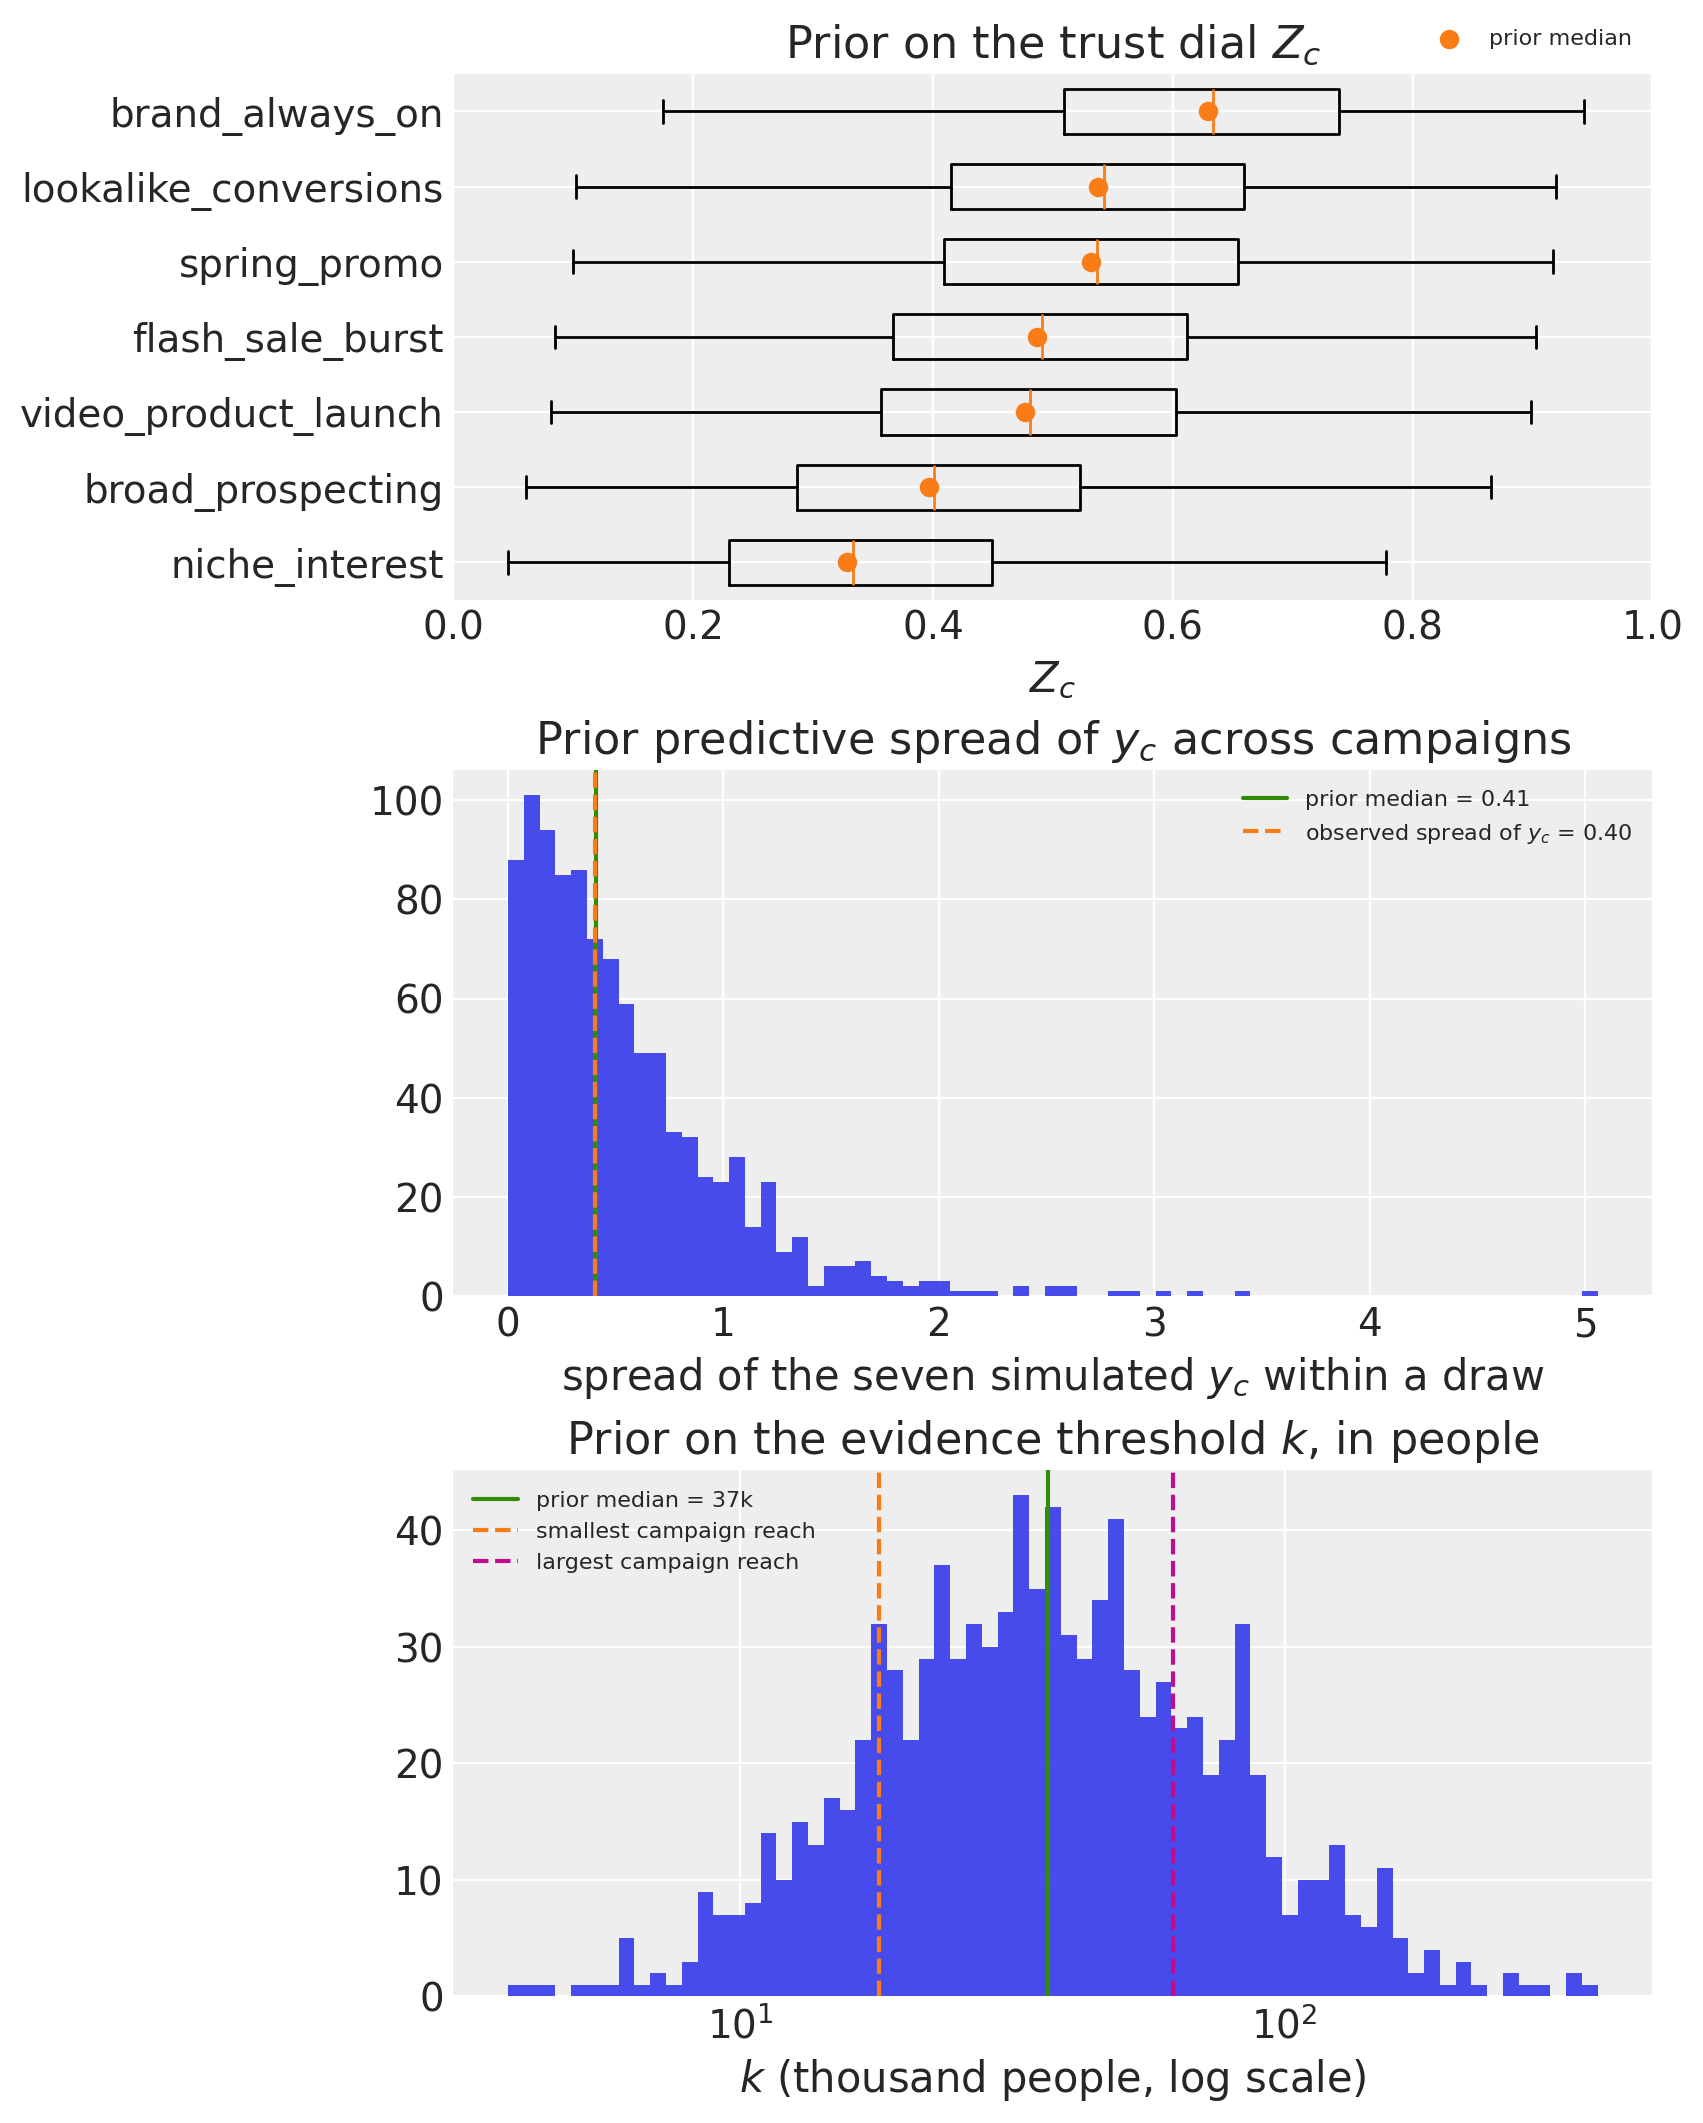

In [14]:
with credibility_model:
    prior = pm.sample_prior_predictive(draws=1_000, random_seed=rng)

prior_z = prior.prior["Z"].stack(sample=("chain", "draw"))
prior_k_people = (
    prior.prior["k"].stack(sample=("chain", "draw")).to_numpy() * unique_reach.mean()
)
prior_spread = (
    prior.prior_predictive["y_obs"].stack(sample=("chain", "draw")).std("campaign")
)

display(
    pd.DataFrame(
        {
            "unique_reach": unique_reach,
            "prior_median_Z": prior_z.median("sample").to_pandas(),
            "prior_Z_2.5%": prior_z.quantile(0.025, "sample").to_pandas(),
            "prior_Z_97.5%": prior_z.quantile(0.975, "sample").to_pandas(),
        }
    )
    .sort_values("unique_reach", ascending=False)
    .round(3)
)

fig, (ax_z, ax_y, ax_k) = plt.subplots(
    nrows=3, figsize=(8.4, 10.5), layout="constrained"
)

z_order = unique_reach.sort_values().index.tolist()
ax_z.boxplot(
    [prior_z.sel(campaign=campaign).to_numpy() for campaign in z_order],
    orientation="horizontal",
    widths=0.6,
    showfliers=False,
    tick_labels=z_order,
)
ax_z.scatter(
    [relative_reach[campaign] / (relative_reach[campaign] + 1) for campaign in z_order],
    np.arange(len(z_order)) + 1,
    color="C1",
    zorder=3,
    label="prior median",
)
ax_z.set(
    xlim=(0, 1),
    xlabel="$Z_c$",
    title="Prior on the trust dial $Z_c$",
)
# above the axes, so the legend cannot sit on top of a whisker
ax_z.legend(loc="lower right", bbox_to_anchor=(1.0, 1.01), fontsize=8)

# bins spanning the full sampled range, so no part of the prior is clipped away
ax_y.hist(
    prior_spread.to_numpy(),
    bins=np.linspace(0, float(prior_spread.max()), 70),
    color="C0",
    alpha=0.85,
)
ax_y.axvline(
    float(prior_spread.median()),
    color="C2",
    ls="-",
    label=f"prior median = {float(prior_spread.median()):.2f}",
)
ax_y.axvline(
    float(y_direct.std(ddof=1)),
    color="C1",
    ls="--",
    label=f"observed spread of $y_c$ = {y_direct.std(ddof=1):.2f}",
)
ax_y.set(
    xlabel="spread of the seven simulated $y_c$ within a draw",
    title="Prior predictive spread of $y_c$ across campaigns",
)
ax_y.legend(loc="upper right", fontsize=8)

ax_k.hist(
    prior_k_people / 1e3,
    bins=np.geomspace(prior_k_people.min() / 1e3, prior_k_people.max() / 1e3, 70),
    color="C0",
    alpha=0.85,
)
# the prior median of k is exactly 1 in relative units, so it is the average reach
ax_k.axvline(
    unique_reach.mean() / 1e3,
    color="C2",
    ls="-",
    label=f"prior median = {unique_reach.mean() / 1e3:.0f}k",
)
ax_k.axvline(
    unique_reach.min() / 1e3, color="C1", ls="--", label="smallest campaign reach"
)
ax_k.axvline(
    unique_reach.max() / 1e3, color="C3", ls="--", label="largest campaign reach"
)
ax_k.set(
    xscale="log",
    xlabel="$k$ (thousand people, log scale)",
    title="Prior on the evidence threshold $k$, in people",
)
ax_k.legend(loc="upper left", fontsize=8);

> **Fig.** Prior predictive checks, top to bottom. The prior on $Z_c$ deliberately does **not** span 0 to 1 for every campaign: because the prior median of $k$ is 1 in relative units, the prior median of $Z_c$ is $n^{\text{rel}}_c/(n^{\text{rel}}_c+1)$, marked by the orange dots, which already encodes "bigger campaigns start out more trusted". `brand_always_on` starts at a median of 0.64 with a 95% range of 0.29 to 0.88, `niche_interest` at 0.34 with a range of 0.11 to 0.68. That is wide enough for the data to move the dial and narrow enough to rule out the two extremes a priori.
>
> The middle panel is what selects `sigma_s`. A `HalfNormal(0.5)` prior implies simulated flights whose spread across campaigns has a median of 0.42, just above the observed 0.40, with a wide interquartile range of 0.19 to 0.77. So the prior covers the data comfortably from both sides without insisting on the observed value. `HalfNormal(0.4)` would imply a median spread of 0.33, slightly tighter than the data, and `HalfNormal(0.7)` about 0.59, half again as wide.
>
> The bottom panel puts $k$ on a scale a media analyst can argue with. Its prior median is 1 in relative units, about 37k people, which is close to the average campaign's unique reach in a field spanning 18k to 62k. In plain language: a campaign of average size starts out about half believed.

In [15]:
def fit_credibility(
    model: pm.Model, progressbar: bool = True
) -> xr.DataTree:
    """Sample the credibility model with the settings used throughout the notebook."""
    with model:
        return pm.sample(
            draws=1_000,
            tune=1_000,
            chains=4,
            cores=4,
            target_accept=0.92,
            random_seed=rng,
            progressbar=progressbar,
        )


idata = fit_credibility(credibility_model)

posterior = idata.posterior
divergences = int(idata.sample_stats["diverging"].sum())
max_rhat = float(az.summary(idata, var_names=["mu", "log_k", "sigma_s"])["r_hat"].max())
k_people = float(posterior["k"].median()) * unique_reach.mean()
trust = posterior["Z"].mean(("chain", "draw")).to_pandas().reindex(campaigns)

display(
    Markdown(
        f"**{divergences} divergences**, max $\\hat R$ over $\\mu$, $\\log k$ and "
        f"$\\sigma_s$ = **{max_rhat:.3f}**.\n\n"
        f"Posterior median evidence threshold $k \\approx$ **{k_people:,.0f} people**, "
        f"so the fitted trust dial runs from **{trust.min():.2f}** "
        f"({trust.idxmin()}) to **{trust.max():.2f}** ({trust.idxmax()})."
    )
)
az.summary(idata, var_names=["mu", "k", "sigma_s", "tau"]).round(3)

NUTS[nutpie]: [mu, log_k, sigma_s, theta_raw]


Output()

**0 divergences**, max $\hat R$ over $\mu$, $\log k$ and $\sigma_s$ = **1.000**.

Posterior median evidence threshold $k \approx$ **38,051 people**, so the fitted trust dial runs from **0.33** (niche_interest) to **0.60** (brand_always_on).

,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,-2.4,0.185,-2.8,-2,1560,1876,1.00,0.0047,0.0038
k,1.38,1.15,0.27,4.2,1547,1767,1.00,0.025,0.049
sigma_s,0.33,0.12,0.17,0.61,1512,1941,1.00,0.003,0.0033
tau,0.323,0.123,0.15,0.61,3918,2742,1.00,0.0021,0.0026


The threshold is reported as the posterior **median** rather than the mean, because $k$ is sampled on the log scale and its posterior is right-skewed. Note also what the fitted range of $Z$ does and does not say: the largest campaign earns 0.60, so even the best-measured campaign here is only slightly more than half believed, and the smallest sits at 0.33.

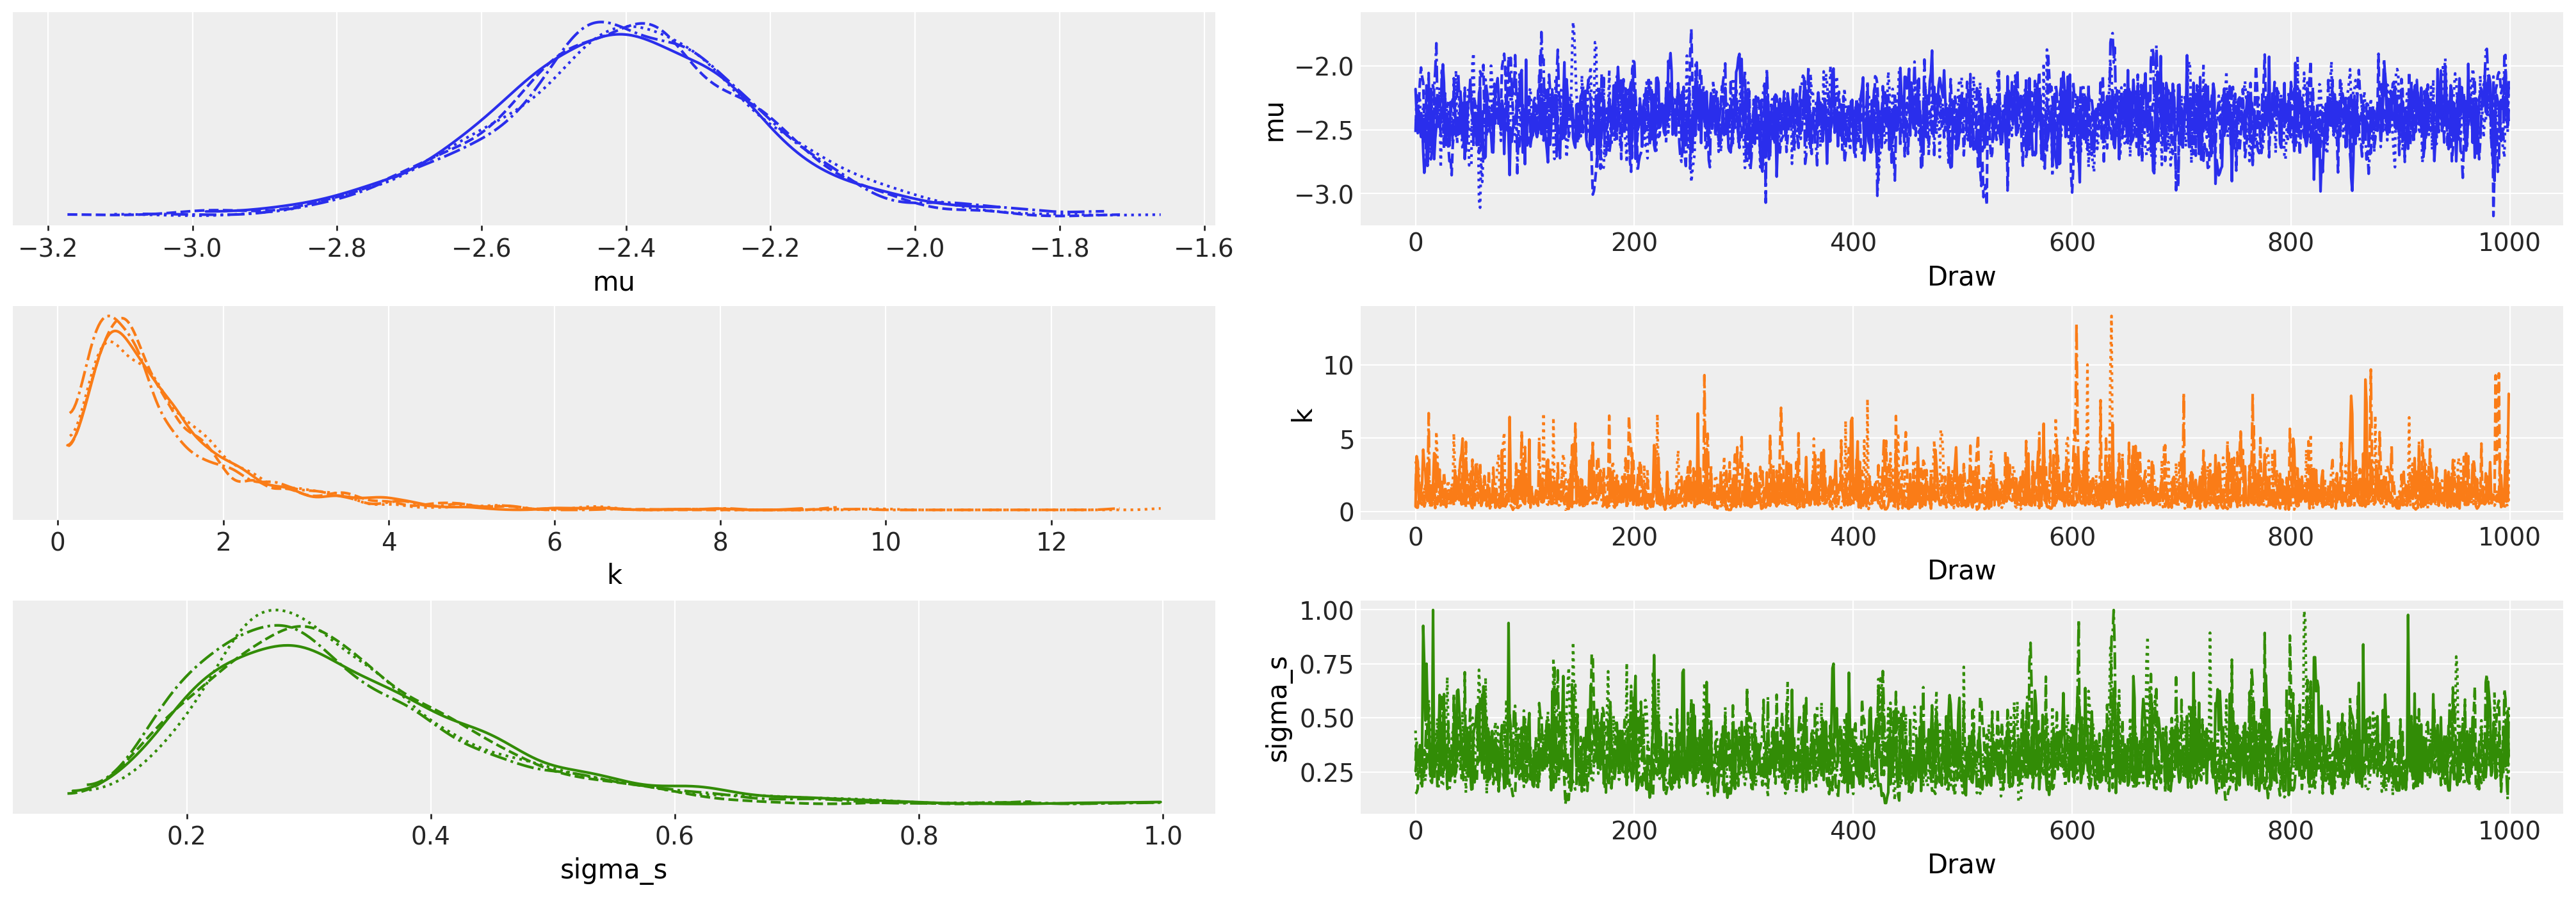

In [16]:
azp.plot_trace_dist(idata, var_names=["mu", "k", "sigma_s"]);

> **Fig.** Marginal posteriors and traces for the three sampled quantities. The chains mix, and `k` is visibly skewed and wide, which is the weak identification described above showing up in the output rather than hiding in it.

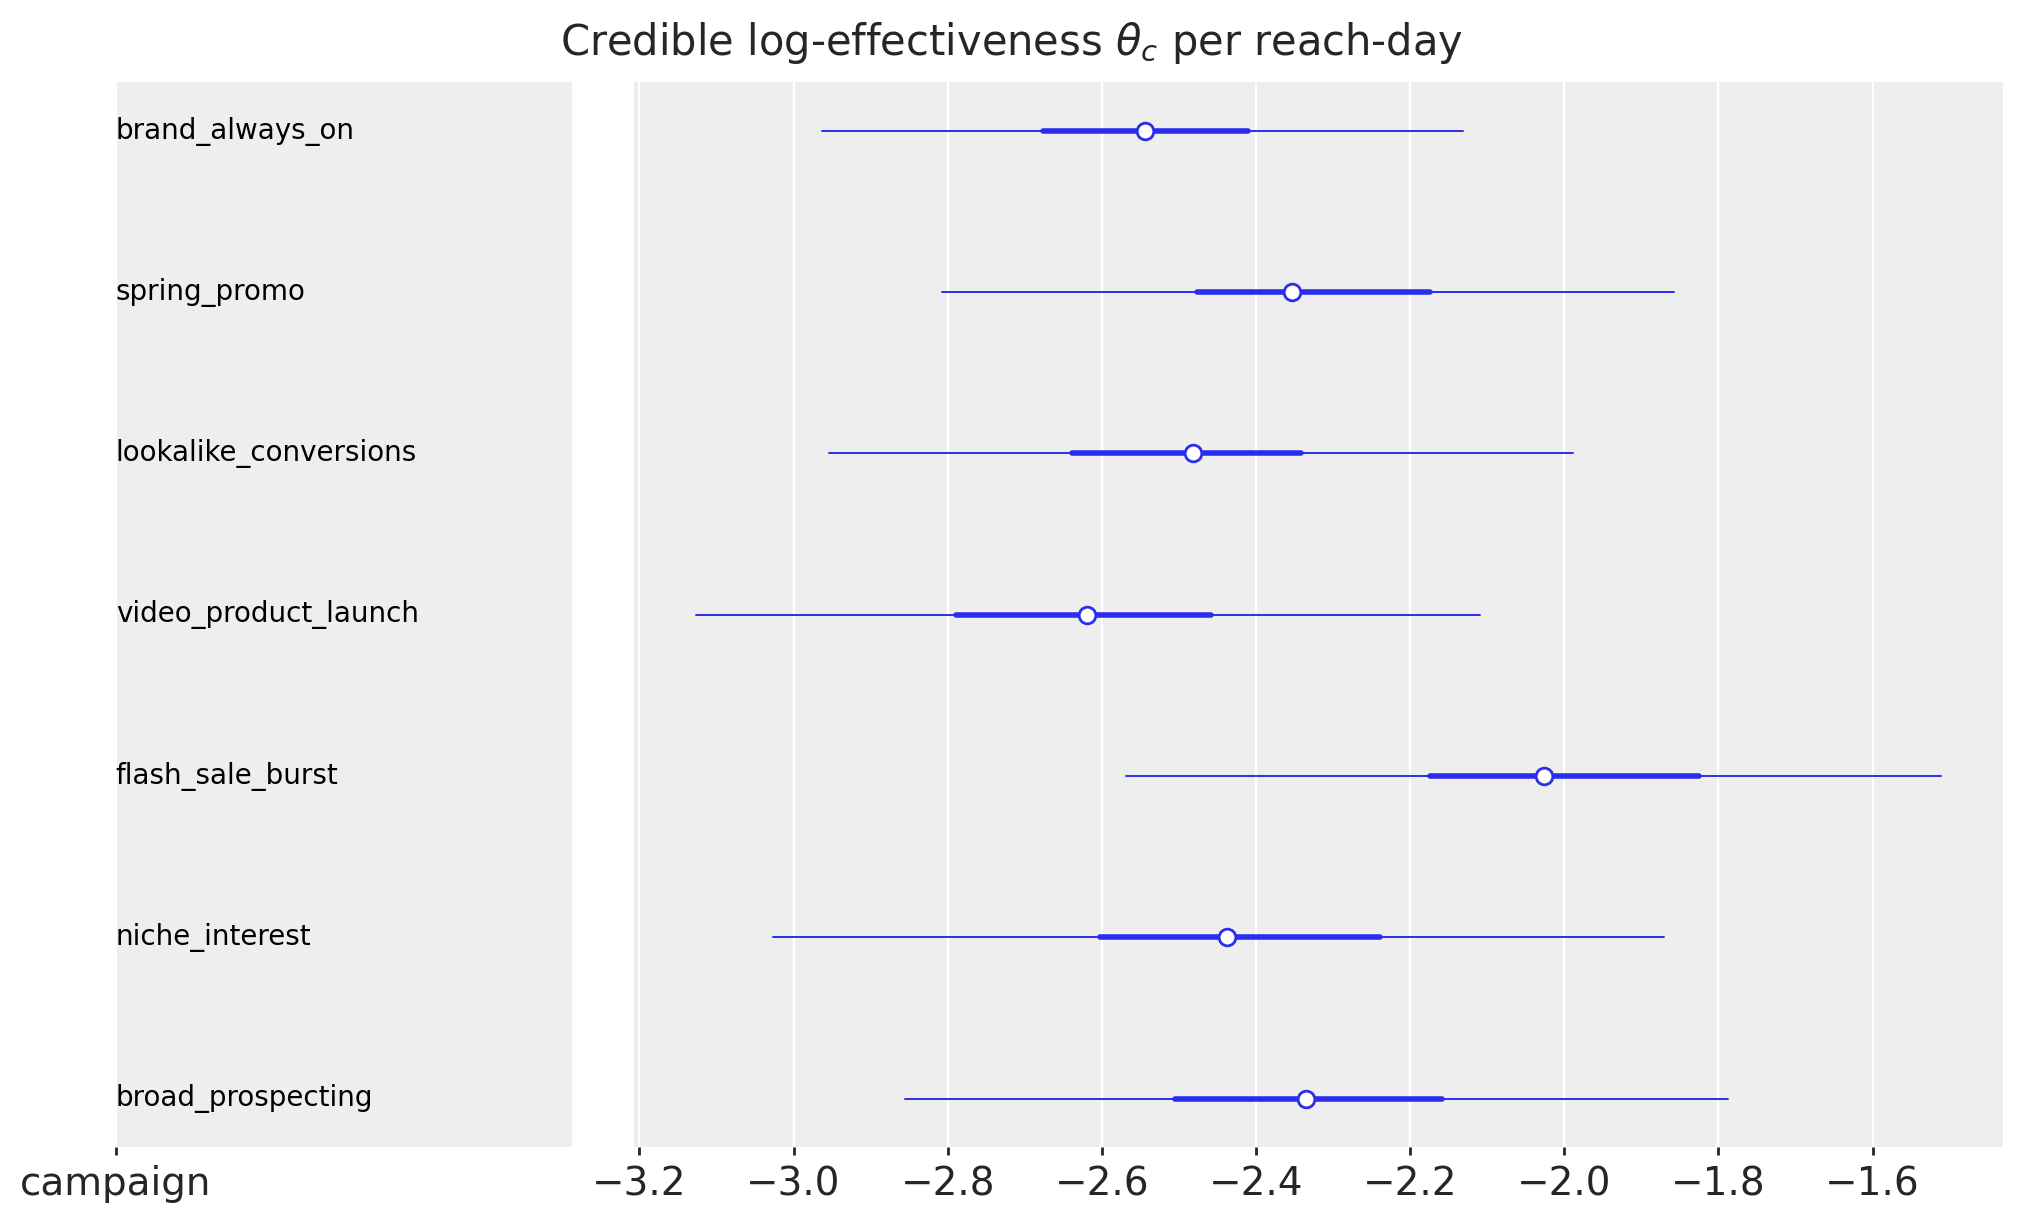

In [17]:
azp.plot_forest(
    idata,
    var_names=["theta"],
    combined=True,
    labels=["campaign"],
    figure_kwargs={"figsize": (10, 6)},
)
plt.gcf().suptitle("Credible log-effectiveness $\\theta_c$ per reach-day", fontsize=15);

> **Fig.** Trust-adjusted (partially pooled) log-effectiveness per campaign, with 94% HDIs.

## Watch the rates move toward the collective centre

This is the payoff picture. Each orange dot is a campaign's **naive** self-report and each arrow shows where the model moved it after weighing the evidence. The number under each campaign is its trust dial **Z**, and campaigns are sorted by unique reach with the smallest on the left.

The size of each move is not arbitrary. Credibility says

$$\theta_c - y_c = (1-Z_c)\,(\mu - y_c),$$

so a campaign moves by its distance from the collective mean, discounted by how much trust it has earned. That predicts the two things you see. `flash_sale_burst` starts furthest above the collective rate, because its clicks are divided by only four reach-days per person, and takes the largest step down. `video_product_launch` starts furthest below, with the account's worst CTR against heavy delivery, and takes the largest step up. `niche_interest` has the lowest trust dial of all but barely moves, because it started close to the middle.

That is the discipline this method buys: a loud dashboard number is not a licence to scale a campaign, and a quiet one is not proof of failure. The adjustment is earned by evidence, and it protects a big steady campaign from being punished for one unlucky week just as much as it reins in a small loud one.

Collective rate $e^{\mu} \approx$ **0.0907** per reach-day. The posterior mean $\theta_c$ reproduces the credibility blend $Z_c y_c + (1-Z_c)\mu$ to within **0.009** in log units, so the table below really is the blend it claims to be.

,unique_reach,reach_days,Z,naive_rate,credible_rate,collective_rate
niche_interest,17987,254475,0.3339,0.0831,0.0874,0.0907
broad_prospecting,24140,32921,0.3952,0.1079,0.0968,0.0907
video_product_launch,33427,519340,0.4666,0.0562,0.0729,0.0907
flash_sale_burst,34802,139620,0.4756,0.1982,0.1318,0.0907
spring_promo,41719,438462,0.5161,0.1001,0.0951,0.0907
lookalike_conversions,42733,597676,0.5215,0.0776,0.0836,0.0907
brand_always_on,62386,1541137,0.6046,0.0714,0.0785,0.0907


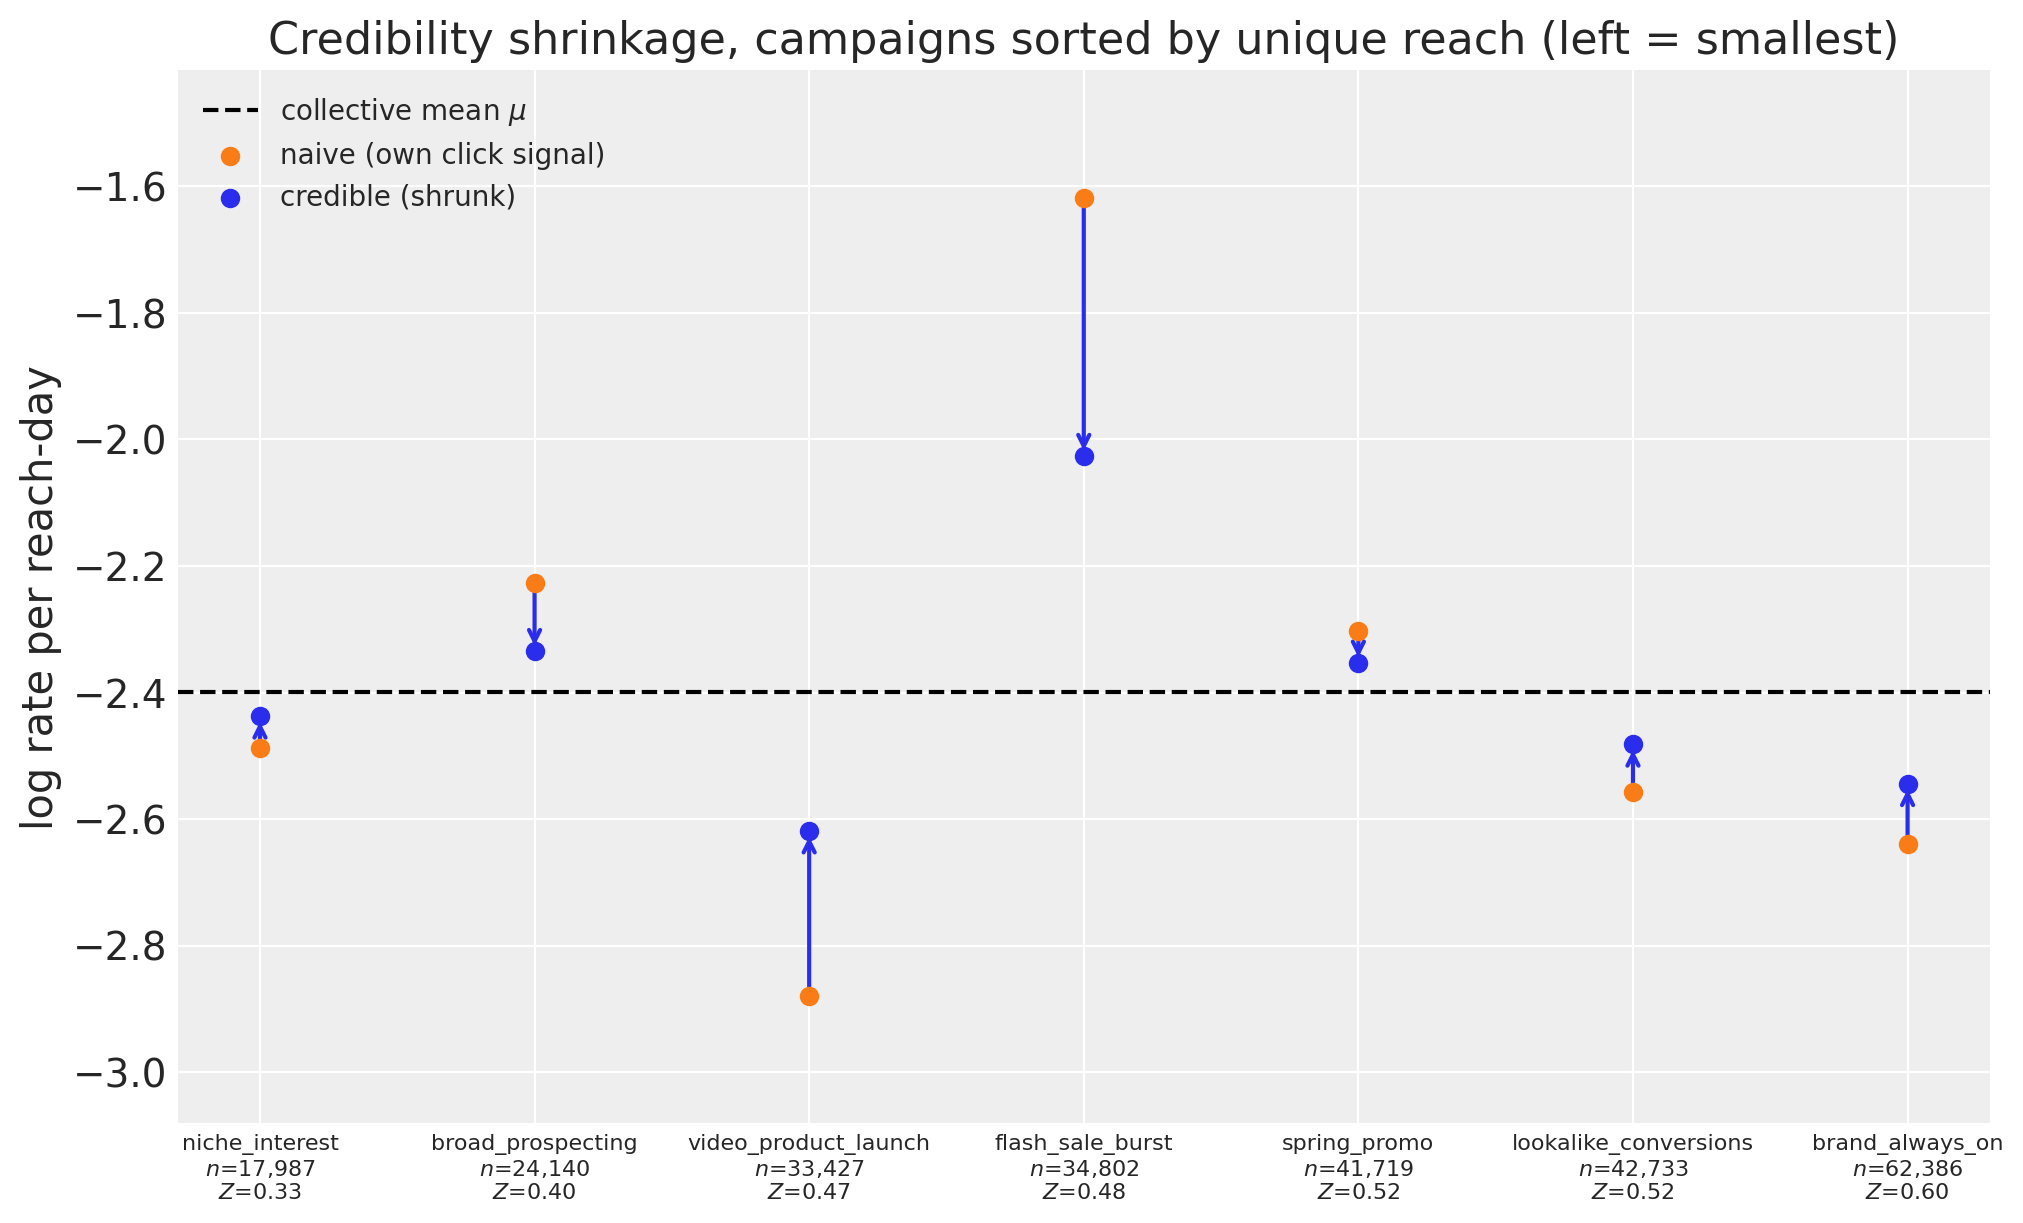

In [18]:
collective_rate = float(np.exp(posterior["mu"].mean()))
theta_mean = posterior["theta"].mean(("chain", "draw")).to_pandas().reindex(campaigns)
blend = trust * y_direct + (1 - trust) * float(posterior["mu"].mean())

shrinkage = pd.DataFrame(
    {
        "unique_reach": unique_reach.astype(int),
        "reach_days": direct["reach_days"].astype(int),
        "Z": trust,
        "naive_rate": direct["naive_rate"],
        "credible_rate": np.exp(theta_mean),
        "collective_rate": collective_rate,
    }
).sort_values("unique_reach")

display(
    Markdown(
        f"Collective rate $e^{{\\mu}} \\approx$ **{collective_rate:.4f}** per reach-day. "
        f"The posterior mean $\\theta_c$ reproduces the credibility blend "
        f"$Z_c y_c + (1-Z_c)\\mu$ to within "
        f"**{float(np.abs(theta_mean - blend).max()):.3f}** in log units, so the "
        f"table below really is the blend it claims to be."
    )
)
display(shrinkage.round(4))

positions = np.arange(len(shrinkage))
fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
ax.axhline(
    np.log(collective_rate), color="black", ls="--", label=r"collective mean $\mu$"
)
for position, (_, row) in enumerate(shrinkage.iterrows()):
    ax.annotate(
        "",
        xy=(position, np.log(row["credible_rate"])),
        xytext=(position, np.log(row["naive_rate"])),
        arrowprops={"arrowstyle": "->", "color": "C0", "lw": 1.5},
    )
ax.scatter(
    positions,
    np.log(shrinkage["naive_rate"]),
    color="C1",
    zorder=3,
    label="naive (own click signal)",
)
ax.scatter(
    positions,
    np.log(shrinkage["credible_rate"]),
    color="C0",
    zorder=3,
    label="credible (shrunk)",
)
ax.set(
    xticks=positions,
    xticklabels=[
        f"{campaign}\n$n$={reach:,}\n$Z$={z:.2f}"
        for campaign, reach, z in zip(
            shrinkage.index,
            shrinkage["unique_reach"],
            shrinkage["Z"],
            strict=True,
        )
    ],
    ylabel="log rate per reach-day",
    title="Credibility shrinkage, campaigns sorted by unique reach (left = smallest)",
)
ax.tick_params(axis="x", labelsize=8)
ax.margins(y=0.16)
ax.legend(loc="upper left", fontsize=10);

> **Fig.** Naive self-report (orange) to trust-adjusted estimate (blue), as log rates per reach-day. Each campaign moves toward the collective mean by a fraction $1-Z_c$ of its distance from it, so the largest steps belong to the campaigns that combine a low trust dial with an extreme starting point.

## Handing the credit back, day by day

The trust-adjusted rates say how much each campaign earns **per reach-day**. To turn that into daily dollars we score each campaign on each day by its credible rate times its reach that day, and hand out the MMM's channel curve in those proportions. Concretely: if campaign A is twice as effective per reach-day, but campaign B delivered three times as many reach-days on Tuesday, B gets 1.5 times A's share of Tuesday's credit.

The weights add to one every single day, so the campaign pieces **always sum back exactly to the MMM's channel total**. We are not inventing a second model of the world, we are dividing the one number we trust.

Both sources of uncertainty travel through. The MMM posterior holds 4 chains of 100 draws, so we pair all 400 of them with 400 draws from the credibility posterior and carry the pairs through the allocation.

Because the rate is now per reach-day, the two ends of the dial are quantities you already recognise, and the cell below asserts both:

- at $Z=0$ every campaign is judged by the collective rate alone, so the credit follows **delivery**, giving the daily-reach split;
- at $Z=1$ every campaign is believed completely, and the reach-days in the numerator cancel the reach-days in the denominator, giving back the **click split**.

With a common $Z$ the flight weights are $\text{clickshare}_c^{\,Z}\cdot\text{reachshare}_c^{\,1-Z}$ up to normalisation, so the dial genuinely interpolates between the two. The residual at the endpoints is the day-by-day renormalisation, which is not separable from the daily allocation.

One structural caveat: the weights are undefined on a day when the whole channel delivered nothing, since the scores would all be zero. Every date in this window has delivery somewhere, so the cell asserts that rather than carrying a fallback branch. On a dark day you would need a convention, and the honest one is that a day with no delivery earns no credit.

In [19]:
def daily_reach(metrics: pd.DataFrame, campaigns: list[str]) -> xr.DataArray:
    """Daily duplicated reach per campaign, the exposure the credit is spent over."""
    wide = metrics.pivot(index="date", columns="campaign", values="reach").reindex(
        columns=campaigns
    )
    return xr.DataArray(
        wide.to_numpy(dtype=float),
        dims=("date", "campaign"),
        coords={"date": wide.index, "campaign": campaigns},
    )


def paired_draws(
    social: xr.DataArray, theta: xr.DataArray,
) -> tuple[xr.DataArray, xr.DataArray]:
    """Pair MMM and credibility draws so both uncertainties propagate."""
    flat_social = social.stack(sample=("chain", "draw")).transpose("sample", "date")
    flat_theta = theta.stack(sample=("chain", "draw")).transpose("sample", "campaign")
    n_draws = flat_social.sizes["sample"]
    available = flat_theta.sizes["sample"]
    picked = np.random.default_rng(seed).choice(
        available, size=n_draws, replace=available < n_draws
    )
    sample = np.arange(n_draws)
    return (
        flat_social.drop_vars(["sample", "chain", "draw"]).assign_coords(sample=sample),
        flat_theta.isel(sample=picked)
        .drop_vars(["sample", "chain", "draw"])
        .assign_coords(sample=sample),
    )


def allocation_weights(theta_draws: xr.DataArray, reach: xr.DataArray) -> xr.DataArray:
    """Daily weights proportional to the credible rate times daily reach."""
    score = np.exp(theta_draws - theta_draws.max("campaign")) * reach
    return score / score.sum("campaign")


def allocate(social_draws: xr.DataArray, weights: xr.DataArray) -> xr.DataArray:
    """Spend each MMM channel draw over campaigns using the daily weights."""
    return (weights * social_draws).rename("campaign_contribution")


def flight_share(contribution: xr.DataArray) -> xr.DataArray:
    """Flight-total share of the channel per campaign, one value per draw."""
    flight = contribution.sum("date")
    return flight / flight.sum("campaign")


reach = daily_reach(data.metrics, campaigns)
assert float(reach.sum("campaign").min()) > 0, "every date needs delivery somewhere"

social_draws, theta_draws = paired_draws(data.social, posterior["theta"])
contribution = allocate(social_draws, allocation_weights(theta_draws, reach))
share = flight_share(contribution).transpose("sample", "campaign")

reconciliation = float(np.abs(contribution.sum("campaign") - social_draws).max())
assert np.isfinite(reconciliation) and reconciliation < 1e-9, (
    "the split must reconcile to the MMM draws"
)


def share_at_common_z(z: float) -> pd.Series:
    """Flight shares if every campaign were trusted by exactly the same amount z."""
    theta_z = xr.DataArray(
        z * y_direct.to_numpy()[None, :],
        dims=("sample", "campaign"),
        coords={"sample": [0], "campaign": campaigns},
    )
    mean_social = social_draws.mean("sample")
    shares = flight_share(allocate(mean_social, allocation_weights(theta_z, reach)))
    return shares.isel(sample=0).to_pandas().reindex(campaigns)


delivery_split = (reach.sum("date").to_pandas() / float(reach.sum())).reindex(campaigns)
click_split = direct["click_share"]
delivery_residual = float(np.abs(share_at_common_z(0.0) - delivery_split).max())
click_residual = float(np.abs(share_at_common_z(1.0) - click_split).max())
assert delivery_residual < 0.005, "Z = 0 must reproduce the delivery split"
assert click_residual < 0.025, "Z = 1 must reproduce the click split"

display(
    Markdown(
        f"Largest per-day reconciliation error across all "
        f"{share.sizes['sample']} paired draws: **{reconciliation:.2e}**, so the split "
        f"is exact.\n\n"
        f"Dial endpoints: at $Z=0$ the flight shares match the daily-reach split to "
        f"**{delivery_residual:.4f}**, and at $Z=1$ they match the click split to "
        f"**{click_residual:.4f}**."
    )
)

Largest per-day reconciliation error across all 400 paired draws: **1.82e-12**, so the split is exact.

Dial endpoints: at $Z=0$ the flight shares match the daily-reach split to **0.0020**, and at $Z=1$ they match the click split to **0.0220**.

## Did it work?

Because this is simulated data we can look at the truth we hid earlier and grade the result. We ask three questions. Did we get the **ranking** of campaigns right (Spearman)? Are the **shares** close (MAE)? And is the **distribution** we produced a good forecast, not just a good point (CRPS)?

That last one matters for a fair comparison. This method returns a posterior while every simple heuristic returns a single number, and the {func}`continuous ranked probability score <pymc_marketing.metrics.crps>` grades both on the same footing in share units: for a one-sample forecast it reduces exactly to the absolute error, and for a posterior it rewards being centred **and** being calibrated. It is a proper score, so padding the interval to look safe is punished.

We do not grade absolute dollars. The hidden truth totals far more than the MMM assigns to this channel, so the level is not ours to defend; the division is.

In [20]:
true_contribution = data.truth.sum(axis=0).reindex(campaigns)
true_share = true_contribution / true_contribution.sum()
share_bounds = az.hdi(share, dim="sample")

display(
    Markdown(
        f"Hidden truth over the window: **{true_contribution.sum():,.0f}** against the "
        f"MMM's **{channel_total:,.0f}** for this channel, a factor of "
        f"**{true_contribution.sum() / channel_total:.2f}**. That gap is why we grade "
        f"shares rather than levels."
    )
)

results = pd.DataFrame(
    {
        "true_share": true_share,
        "credibility_share": share.mean("sample").to_pandas(),
        "hdi_low": share_bounds.sel(ci_bound="lower").to_pandas(),
        "hdi_high": share_bounds.sel(ci_bound="upper").to_pandas(),
        "naive_clicks_share": click_split,
        "crps": per_observation_crps(true_share.to_numpy(), share.to_numpy()),
    }
).sort_values("true_share", ascending=False)
results.round(4)

Hidden truth over the window: **540,350** against the MMM's **281,777** for this channel, a factor of **1.92**. That gap is why we grade shares rather than levels.

,true_share,credibility_share,hdi_low,hdi_high,naive_clicks_share,crps
brand_always_on,0.4310,0.4156,0.3274,0.5141,0.3903,0.0131
lookalike_conversions,0.2406,0.1702,0.1098,0.2326,0.1645,0.0542
niche_interest,0.1096,0.0761,0.0417,0.1188,0.0751,0.0246
spring_promo,0.0878,0.1384,0.0919,0.1905,0.1557,0.0362
video_product_launch,0.0782,0.1309,0.0714,0.1760,0.1035,0.0382
flash_sale_burst,0.0419,0.0570,0.0355,0.0767,0.0982,0.0094
broad_prospecting,0.0110,0.0118,0.0066,0.0175,0.0126,0.0007


In [21]:
def score_shares(true_share: pd.Series, draws: np.ndarray) -> dict[str, float]:
    """Grade a share forecast given draws with shape (sample, campaign)."""
    truth = true_share.to_numpy()
    point = draws.mean(axis=0)
    scores = {
        "spearman": float(spearmanr(point, truth).correlation),
        "mae": float(np.abs(point - truth).mean()),
        "crps": float(crps(truth, draws)),
        "coverage": float("nan"),
    }
    if draws.shape[0] > 1:
        bounds = az.hdi(xr.DataArray(draws, dims=("sample", "campaign")), dim="sample")
        inside = (truth >= bounds.sel(ci_bound="lower").to_numpy()) & (
            truth <= bounds.sel(ci_bound="upper").to_numpy()
        )
        scores["coverage"] = float(inside.sum())
    return scores


totals = campaign_totals(data.metrics, campaigns)
baselines = {
    "daily-reach share": delivery_split,
    "spend share": totals["spend"] / totals["spend"].sum(),
    "naive clicks share": click_split,
    "impressions share": totals["impressions"] / totals["impressions"].sum(),
    "unique-reach share": unique_reach / unique_reach.sum(),
}

scoreboard = pd.DataFrame(
    [
        {"method": "credibility split", **score_shares(true_share, share.to_numpy())},
        *(
            {
                "method": name,
                **score_shares(
                    true_share, baseline.reindex(campaigns).to_numpy()[None, :]
                ),
            }
            for name, baseline in baselines.items()
        ),
    ]
).set_index("method")
scoreboard.assign(coverage=lambda df: df["coverage"].map("{:.0f} of 7".format)).replace(
    "nan of 7", ""
).round(4)

,spearman,mae,crps,coverage
method,,,,
credibility split,0.8929,0.0341,0.0252,5 of 7
daily-reach share,0.8571,0.0321,0.0321,
spend share,0.8571,0.0322,0.0322,
naive clicks share,0.7857,0.0432,0.0432,
impressions share,0.6429,0.0481,0.0481,
unique-reach share,0.6071,0.0864,0.0864,


Four statements, each of which follows from that table.

1. **Against the signal it disciplines, it improves everything.** The naive clicks split scores 0.786 on Spearman and 0.0432 on both MAE and CRPS. The credibility split scores 0.893, 0.0343 and 0.0250.
2. **As a probabilistic forecast it is the best of everything tested**, at a CRPS of 0.0250 against 0.0321 for the closest heuristic, because CRPS rewards calibration as well as centring.
3. **On point accuracy alone the daily-reach split is still slightly better**, 0.0321 against 0.0343. That is worth stating plainly rather than burying. Clicks are the weakest signal in this account, and a method that disciplines a signal inherits its slant.
4. **Five of the seven true shares fall inside the 94% HDI.** The interval carries parameter uncertainty only, so treat it as a lower bound: a common daily MMM multiplier largely cancels when contributions become shares, and nothing in the model represents the gap between clicks and incrementality. The count itself is fragile at this sample size, moving between four and five across seeds.

Keep the sample size in view. With seven campaigns, a Spearman of 0.786 corresponds to a sum of squared rank differences of 12 and 0.893 to 6, so the improvement is two pairs' worth of reordering, and MAE differences of 0.002 are not evidence of much in either direction.

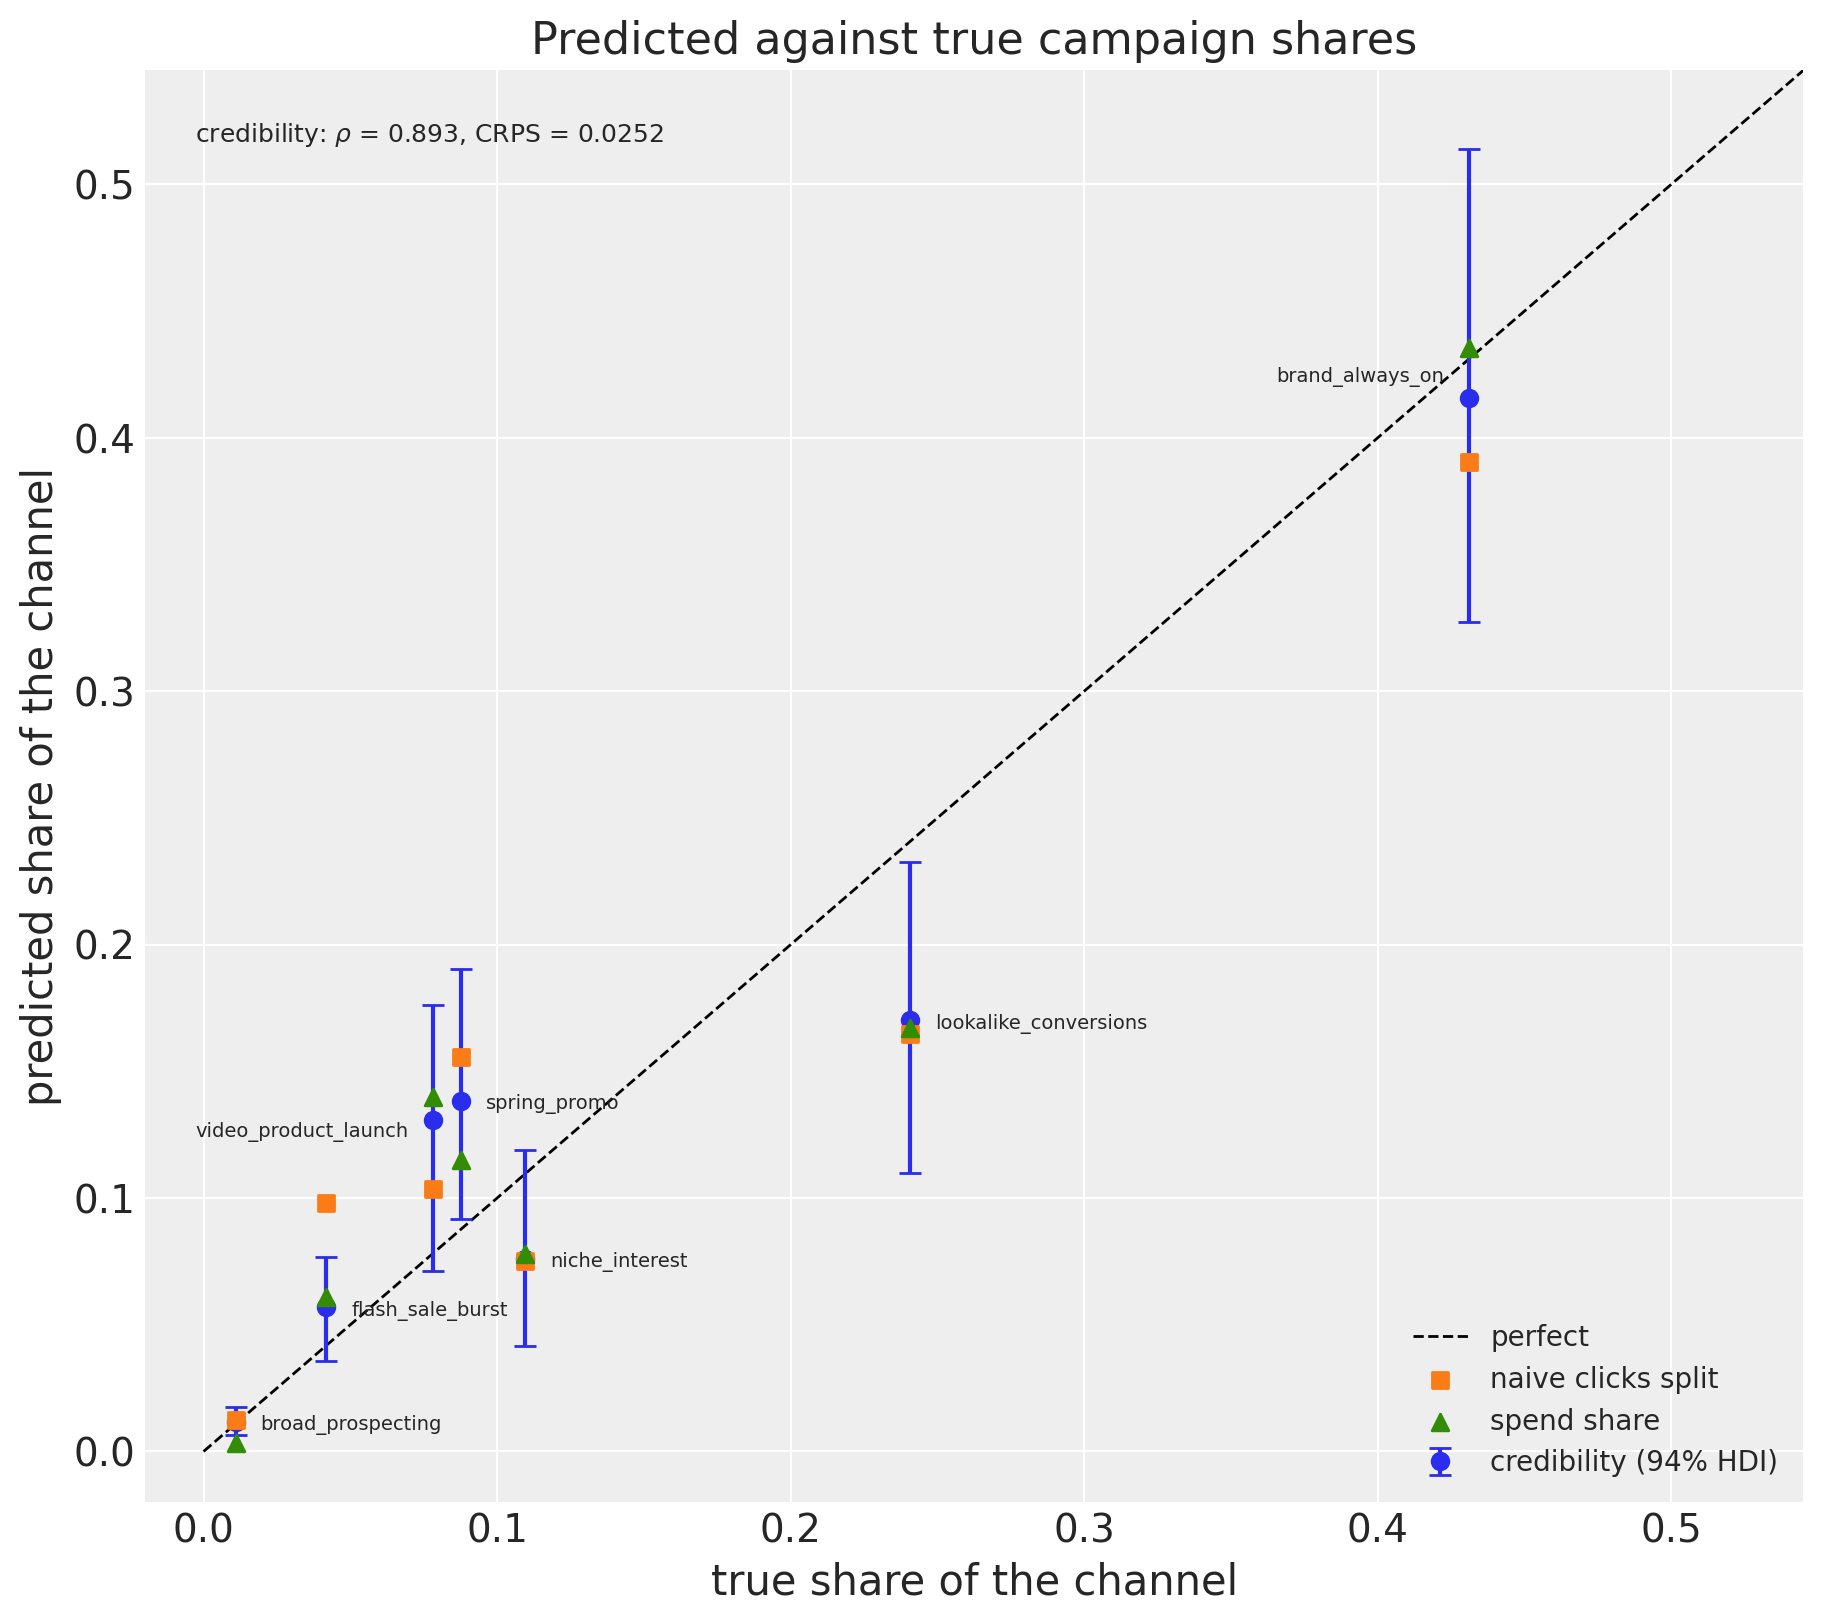

In [22]:
fig, ax = plt.subplots(figsize=(9, 8), layout="constrained")
# one square window wide enough for the widest HDI, so no interval is clipped
upper = 1.06 * max(
    results[["true_share", "credibility_share", "hdi_high"]].to_numpy().max(),
    click_split.max(),
    baselines["spend share"].max(),
)
limits = (-0.02, upper)
ax.plot((0, upper), (0, upper), color="black", ls="--", lw=1.0, label="perfect")
ax.errorbar(
    results["true_share"],
    results["credibility_share"],
    yerr=[
        results["credibility_share"] - results["hdi_low"],
        results["hdi_high"] - results["credibility_share"],
    ],
    fmt="o",
    capsize=4,
    color="C0",
    label=f"credibility ({CI_PROB:.0%} HDI)",
)
ax.scatter(
    true_share,
    click_split,
    marker="s",
    color="C1",
    zorder=3,
    label="naive clicks split",
)
ax.scatter(
    true_share,
    baselines["spend share"],
    marker="^",
    color="C2",
    zorder=3,
    label="spend share",
)
label_offsets = {"video_product_launch": (-9, -6), "brand_always_on": (-9, 6)}
for campaign in campaigns:
    offset = label_offsets.get(campaign, (9, -3))
    ax.annotate(
        campaign,
        (true_share[campaign], results.loc[campaign, "credibility_share"]),
        xytext=offset,
        textcoords="offset points",
        ha="left" if offset[0] > 0 else "right",
        fontsize=7,
    )
credibility_scores = score_shares(true_share, share.to_numpy())
ax.annotate(
    f"credibility: $\\rho$ = {credibility_scores['spearman']:.3f}, "
    f"CRPS = {credibility_scores['crps']:.4f}",
    (0.03, 0.95),
    xycoords="axes fraction",
    fontsize=9,
)
ax.set(
    xlim=limits,
    ylim=limits,
    xlabel="true share of the channel",
    ylabel="predicted share of the channel",
    title="Predicted against true campaign shares",
)
ax.legend(loc="lower right", fontsize=10);

> **Fig.** Predicted against true flight shares, with the 94% HDI on the credibility estimate. Points above the dashed line are over-credited and points below it are under-credited. `lookalike_conversions` is the largest miss, under-credited by 0.07 in share, followed by `spring_promo` and `video_product_launch` over-credited by about 0.05 each. `broad_prospecting` lands almost exactly and `brand_always_on` within 0.02. The naive clicks split (squares) is further from the line on six of the seven campaigns.

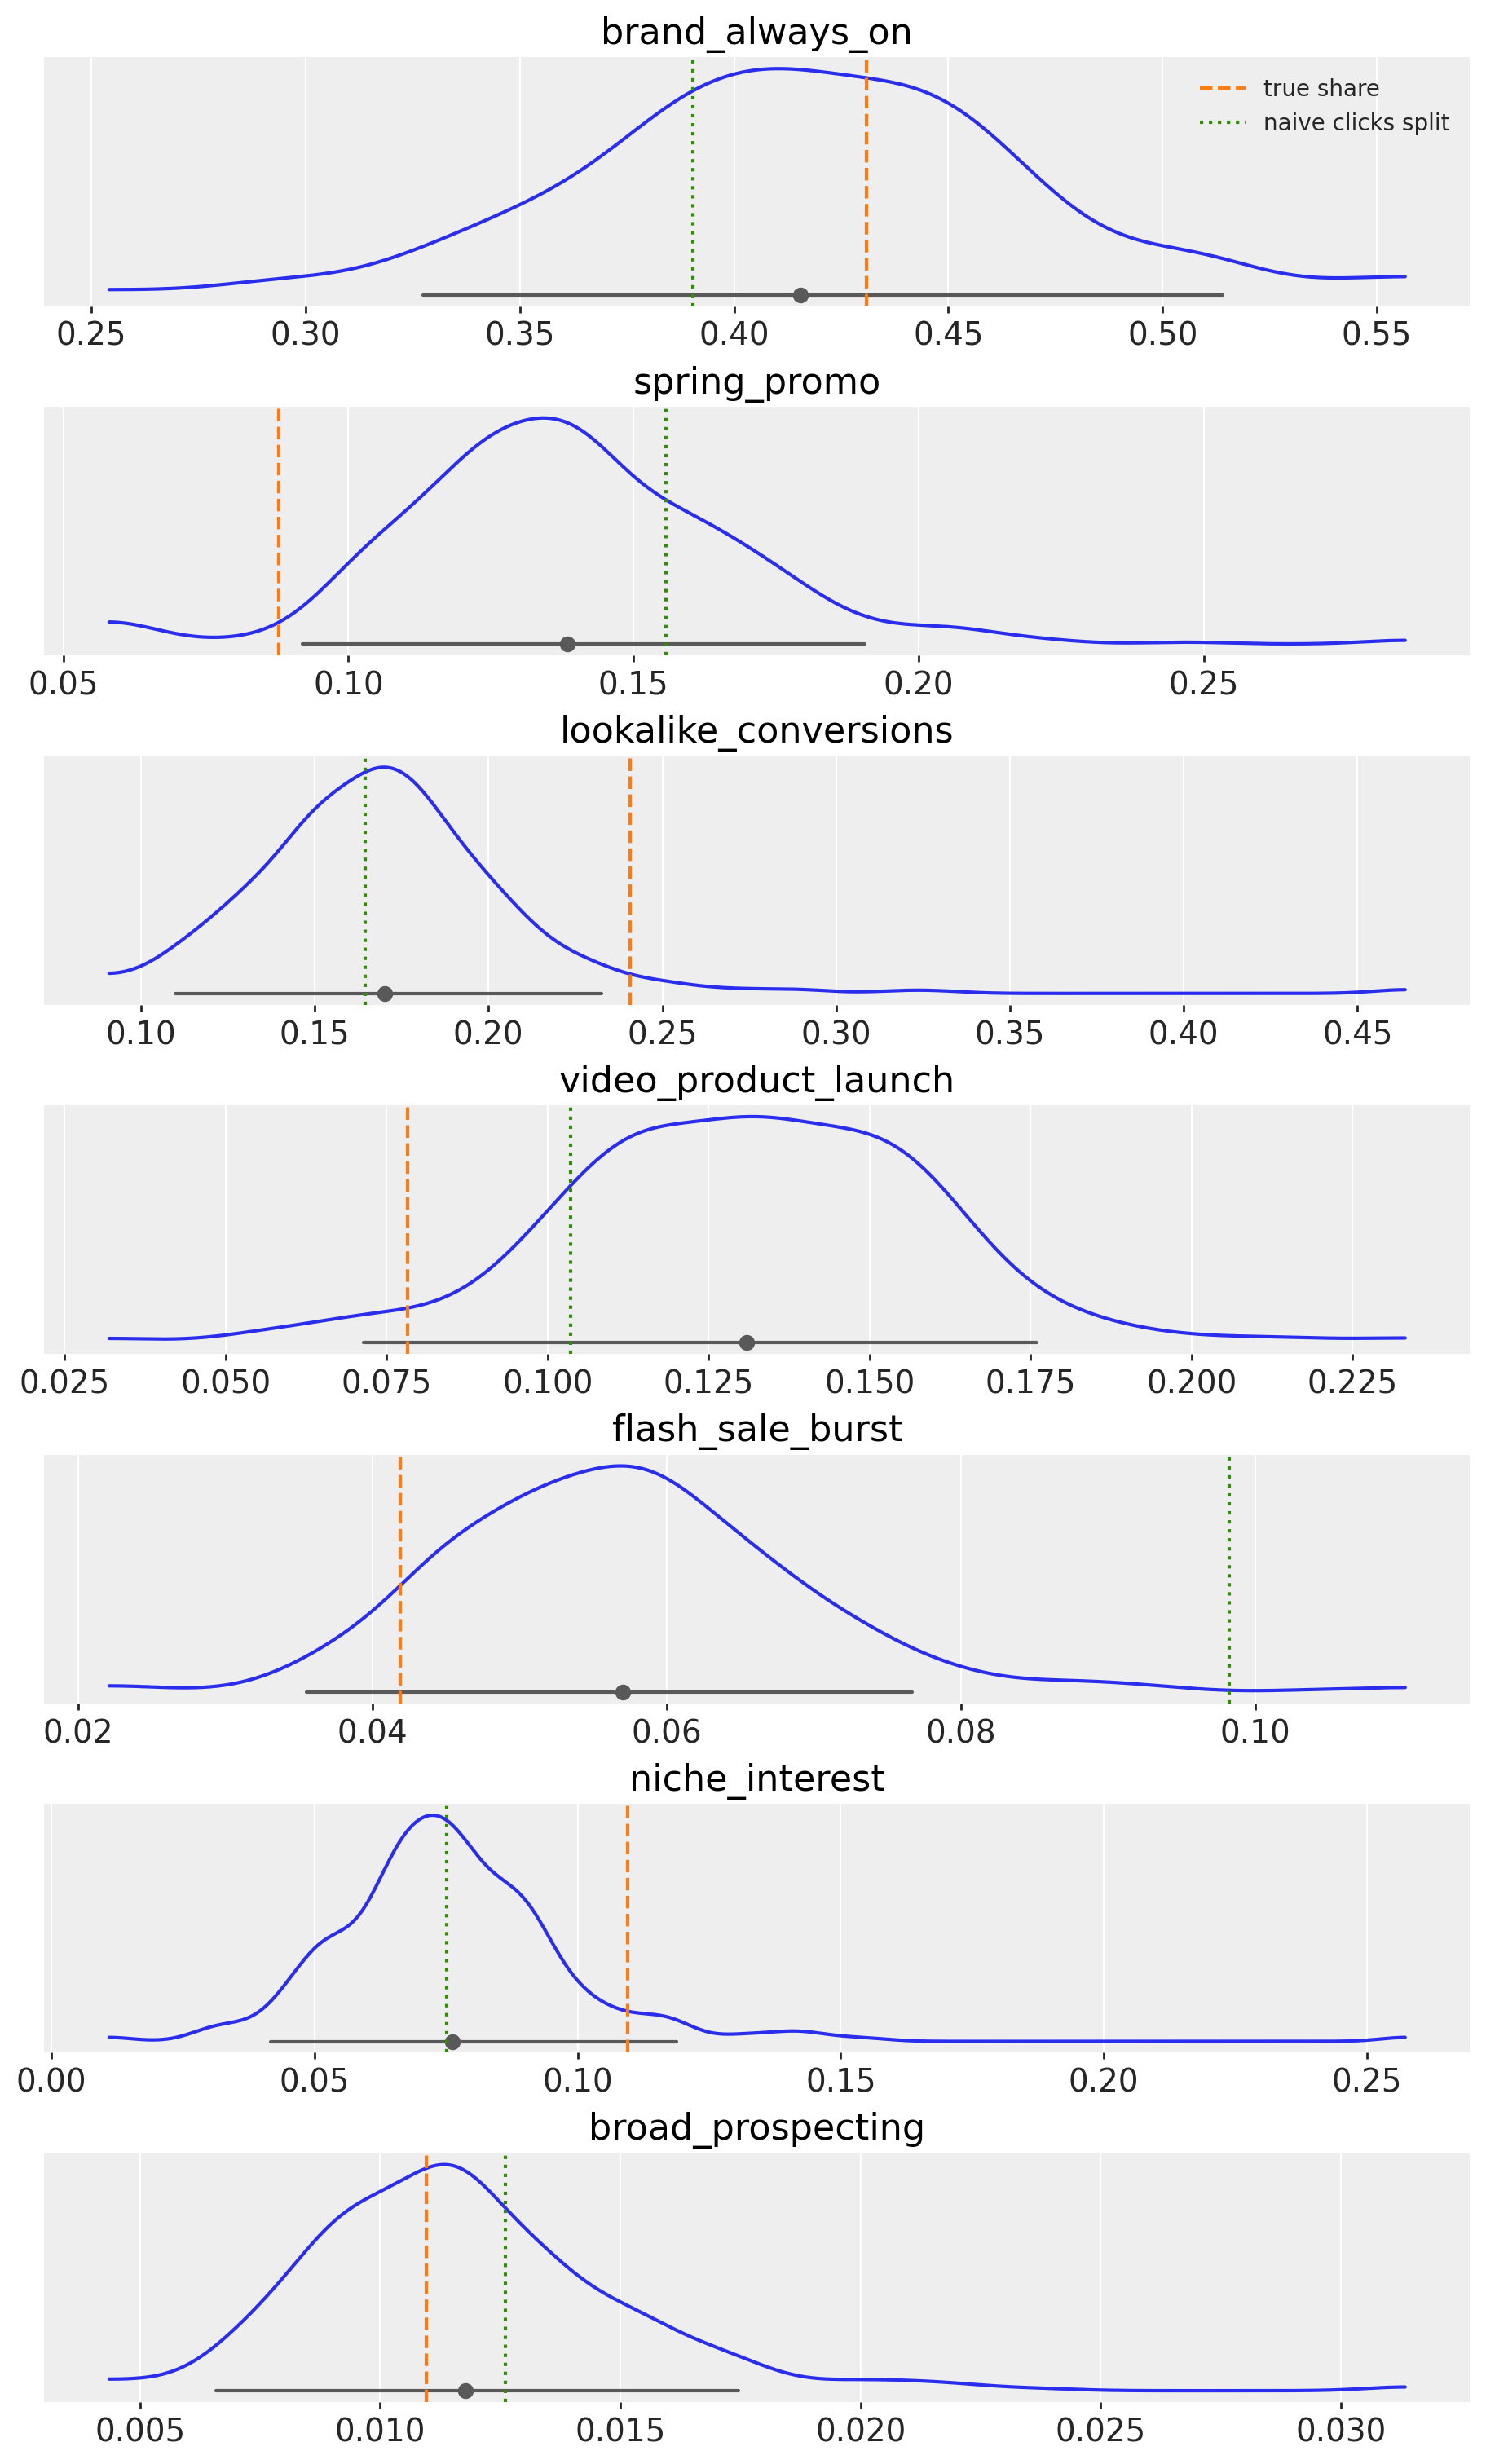

In [23]:
share_dataset = xr.Dataset({"share": share})
plots = azp.plot_dist(
    share_dataset,
    sample_dims=["sample"],
    col_wrap=1,
    labeller=NoVarLabeller(),
    visuals={"point_estimate_text": False},
    figure_kwargs={"figsize": (9, 15)},
)
for campaign in campaigns:
    ax = plots.viz["plot"]["share"].sel(campaign=campaign).item()
    ax.axvline(true_share[campaign], color="C1", ls="--", label="true share")
    ax.axvline(click_split[campaign], color="C2", ls=":", label="naive clicks split")
plots.viz["plot"]["share"].sel(campaign=campaigns[0]).item().legend(
    loc="upper right", fontsize=10
);

> **Fig.** The posterior share of the channel for each campaign, one row per campaign, with the hidden truth as a dashed line and the naive clicks split as a dotted line. Each panel keeps its own horizontal scale, since shares span 0.01 to 0.43. Two truth lines fall outside their 94% HDI, `lookalike_conversions` and `spring_promo`, and both of the relevant margins are thin: `spring_promo` misses its interval by 0.0002 in share while `video_product_launch` makes it by 0.0016. That is why the coverage count moves between four and five across seeds, and why it is not a quantity to tune against. Where the dotted line sits far from the dashed one and the posterior sits between them, credibility has moved the answer in the right direction without going far enough.

Sweeping a common dial: MAE is **0.0322** at $Z=0$ (the delivery split), bottoms out at **0.0310** near $Z=$0.20, and rises to **0.0373** at $Z=1$ (the click split). The fitted campaign-specific dials span **0.33** to **0.60**.

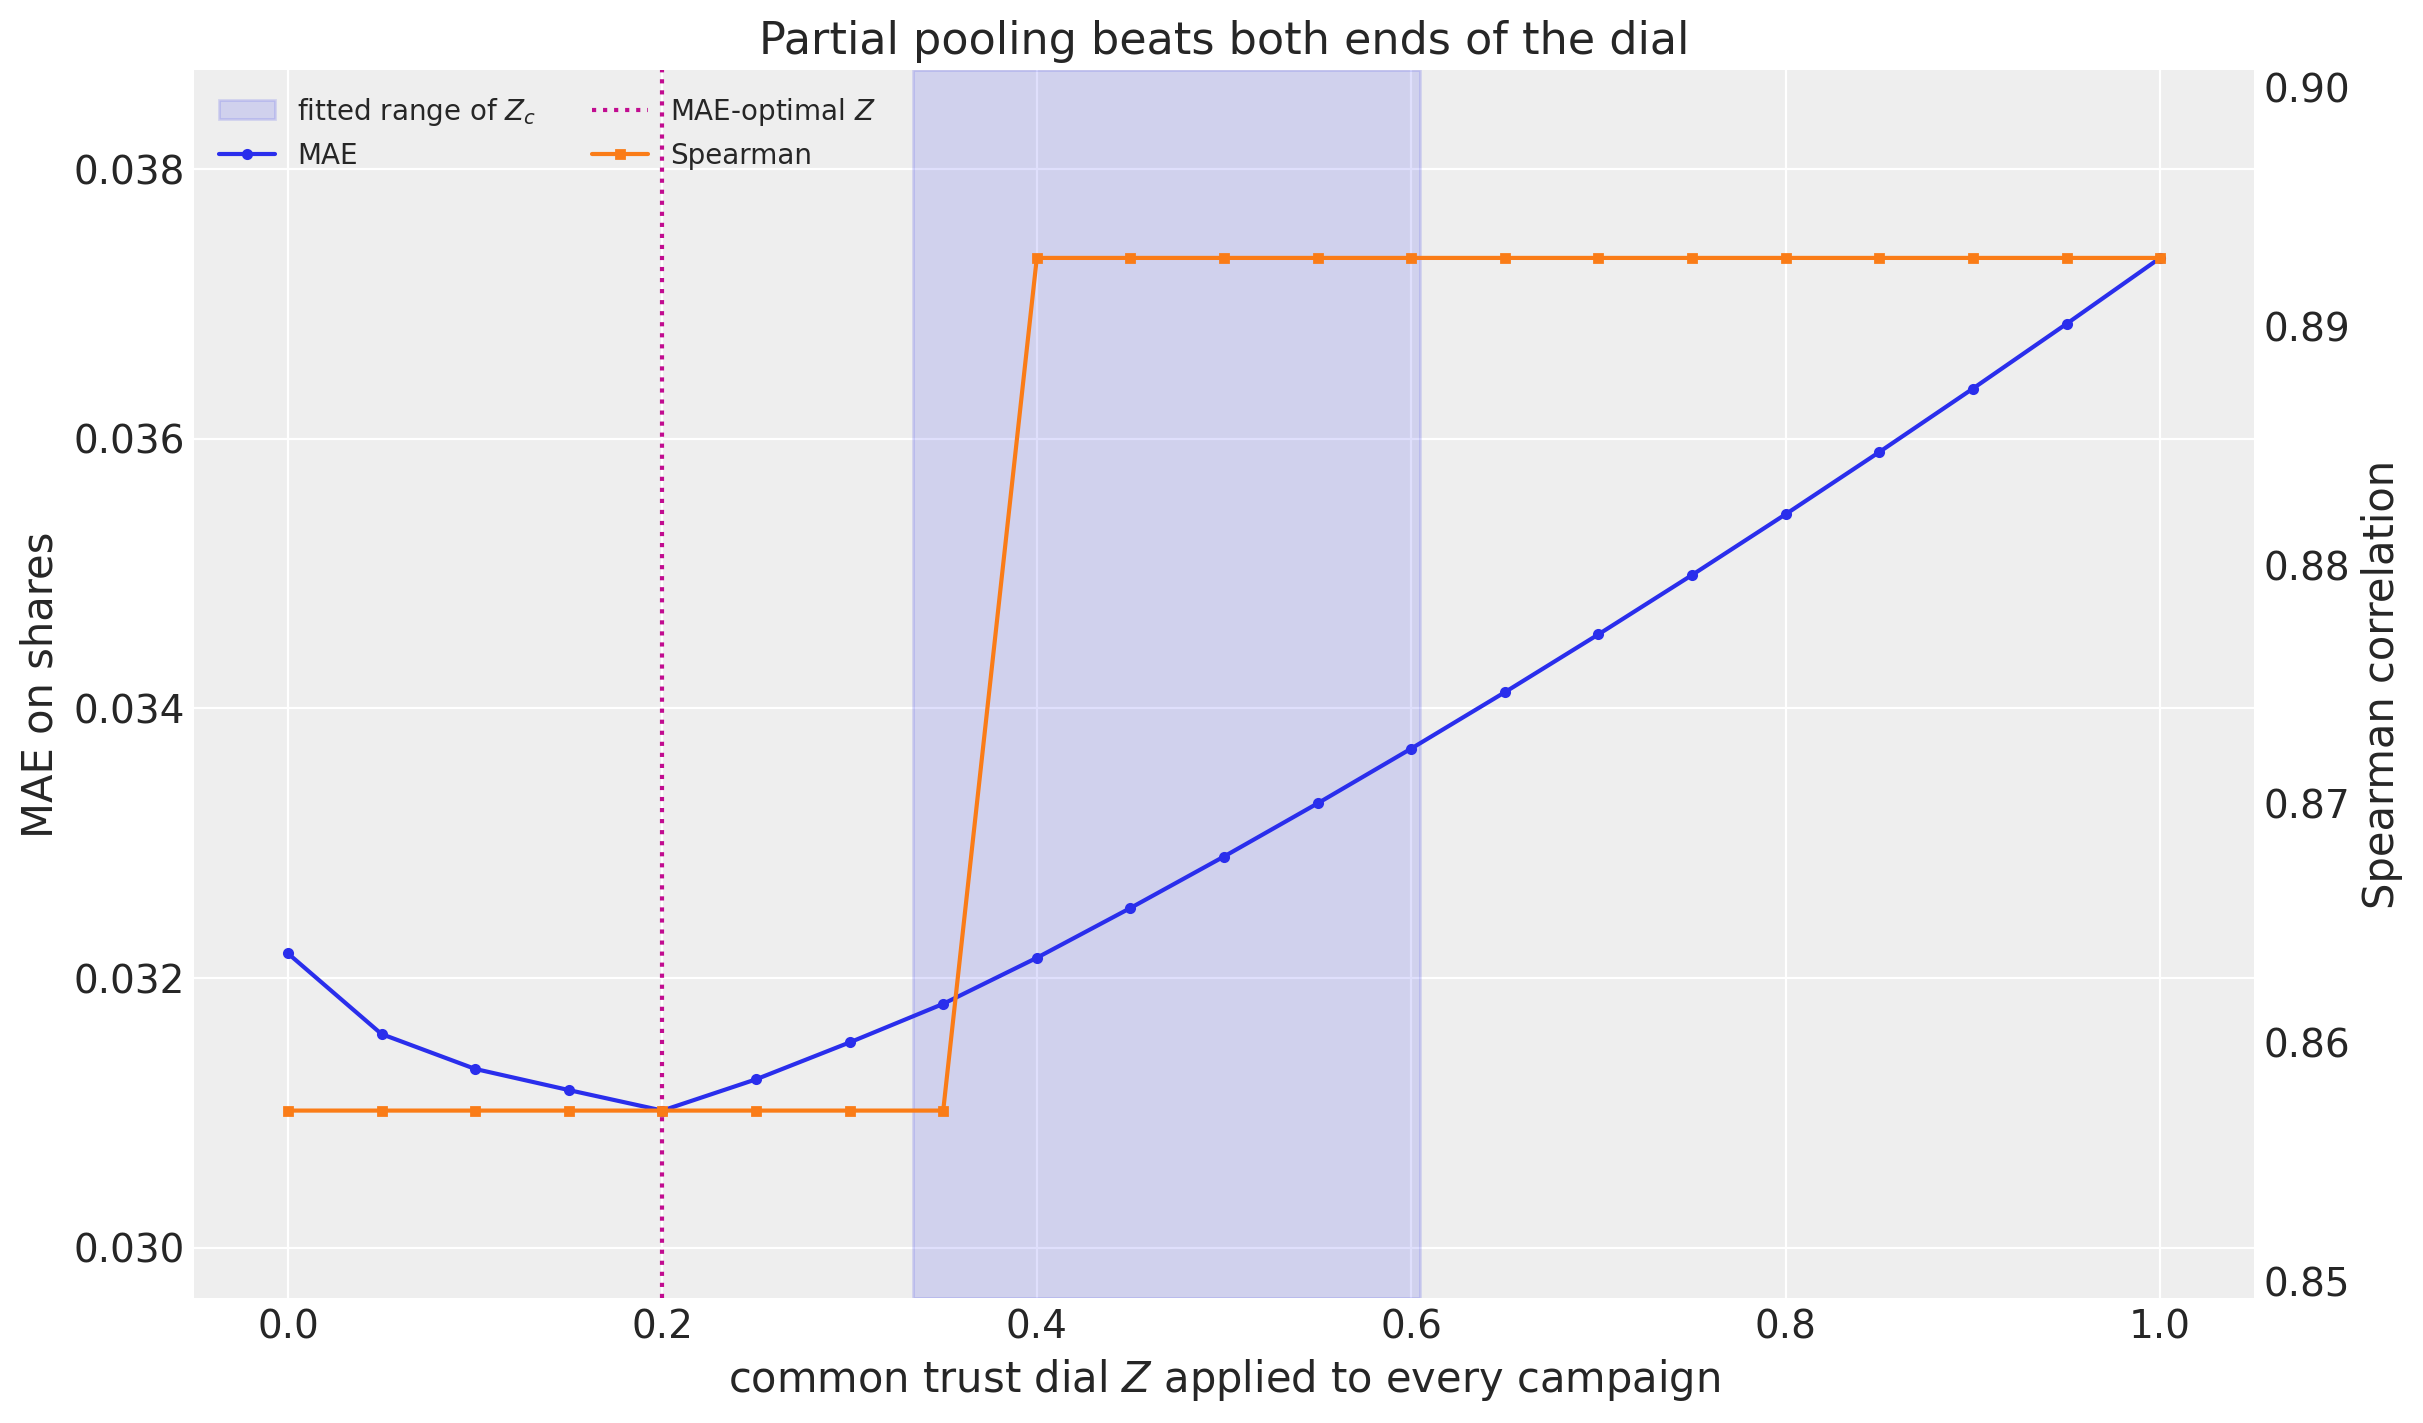

In [24]:
dial_grid = np.linspace(0.0, 1.0, 21)
sweep = pd.DataFrame(
    [
        {
            "Z": z,
            **{
                key: value
                for key, value in score_shares(
                    true_share, share_at_common_z(z).to_numpy()[None, :]
                ).items()
                if key in {"mae", "spearman"}
            },
        }
        for z in dial_grid
    ]
).set_index("Z")

display(
    Markdown(
        f"Sweeping a common dial: MAE is **{sweep['mae'].iloc[0]:.4f}** at $Z=0$ "
        f"(the delivery split), bottoms out at **{sweep['mae'].min():.4f}** near "
        f"$Z=${sweep['mae'].idxmin():.2f}, and rises to "
        f"**{sweep['mae'].iloc[-1]:.4f}** at $Z=1$ (the click split). The fitted "
        f"campaign-specific dials span **{trust.min():.2f}** to **{trust.max():.2f}**."
    )
)

fig, ax_mae = plt.subplots(figsize=(12, 7), layout="constrained")
ax_rho = ax_mae.twinx()
ax_mae.axvspan(
    trust.min(),
    trust.max(),
    color="C0",
    alpha=0.15,
    label="fitted range of $Z_c$",
)
ax_mae.plot(sweep.index, sweep["mae"], color="C0", marker="o", ms=3, label="MAE")
ax_rho.plot(
    sweep.index, sweep["spearman"], color="C1", marker="s", ms=3, label="Spearman"
)
ax_mae.axvline(sweep["mae"].idxmin(), color="C3", ls=":", label="MAE-optimal $Z$")
ax_mae.set(
    xlabel="common trust dial $Z$ applied to every campaign",
    ylabel="MAE on shares",
    title="Partial pooling beats both ends of the dial",
)
ax_rho.set(ylabel="Spearman correlation")
ax_rho.grid(visible=False)
ax_mae.margins(y=0.22)
ax_rho.margins(y=0.22)
handles, labels = (
    left + right
    for left, right in zip(
        ax_mae.get_legend_handles_labels(),
        ax_rho.get_legend_handles_labels(),
        strict=True,
    )
)
ax_mae.legend(handles, labels, loc="upper left", ncol=2, fontsize=10);

> **Fig.** The credibility dial swept by hand, against the hidden truth. This is the most useful validation in the notebook, because it grades the method rather than one point estimate, and it says three things.
>
> Partial pooling beats **both** extremes of the dial on MAE, with an interior minimum of 0.0310 near $Z=0.20$ against 0.0322 at $Z=0$ and 0.0373 at $Z=1$. An interior answer is the right kind of answer here.
>
> Spearman is a step function: the ranking only becomes correct once $Z$ passes about 0.40, which is where two campaigns swap places.
>
> The two criteria therefore disagree, and the fitted range, shaded, straddles that step and sits well above the MAE optimum. That is the honest reading of the 0.0343 in the scoreboard: a common dial near 0.20 would have scored better on MAE while getting the order wrong, and the fitted model, which never sees the truth, lands on the side of the step that gets the order right.

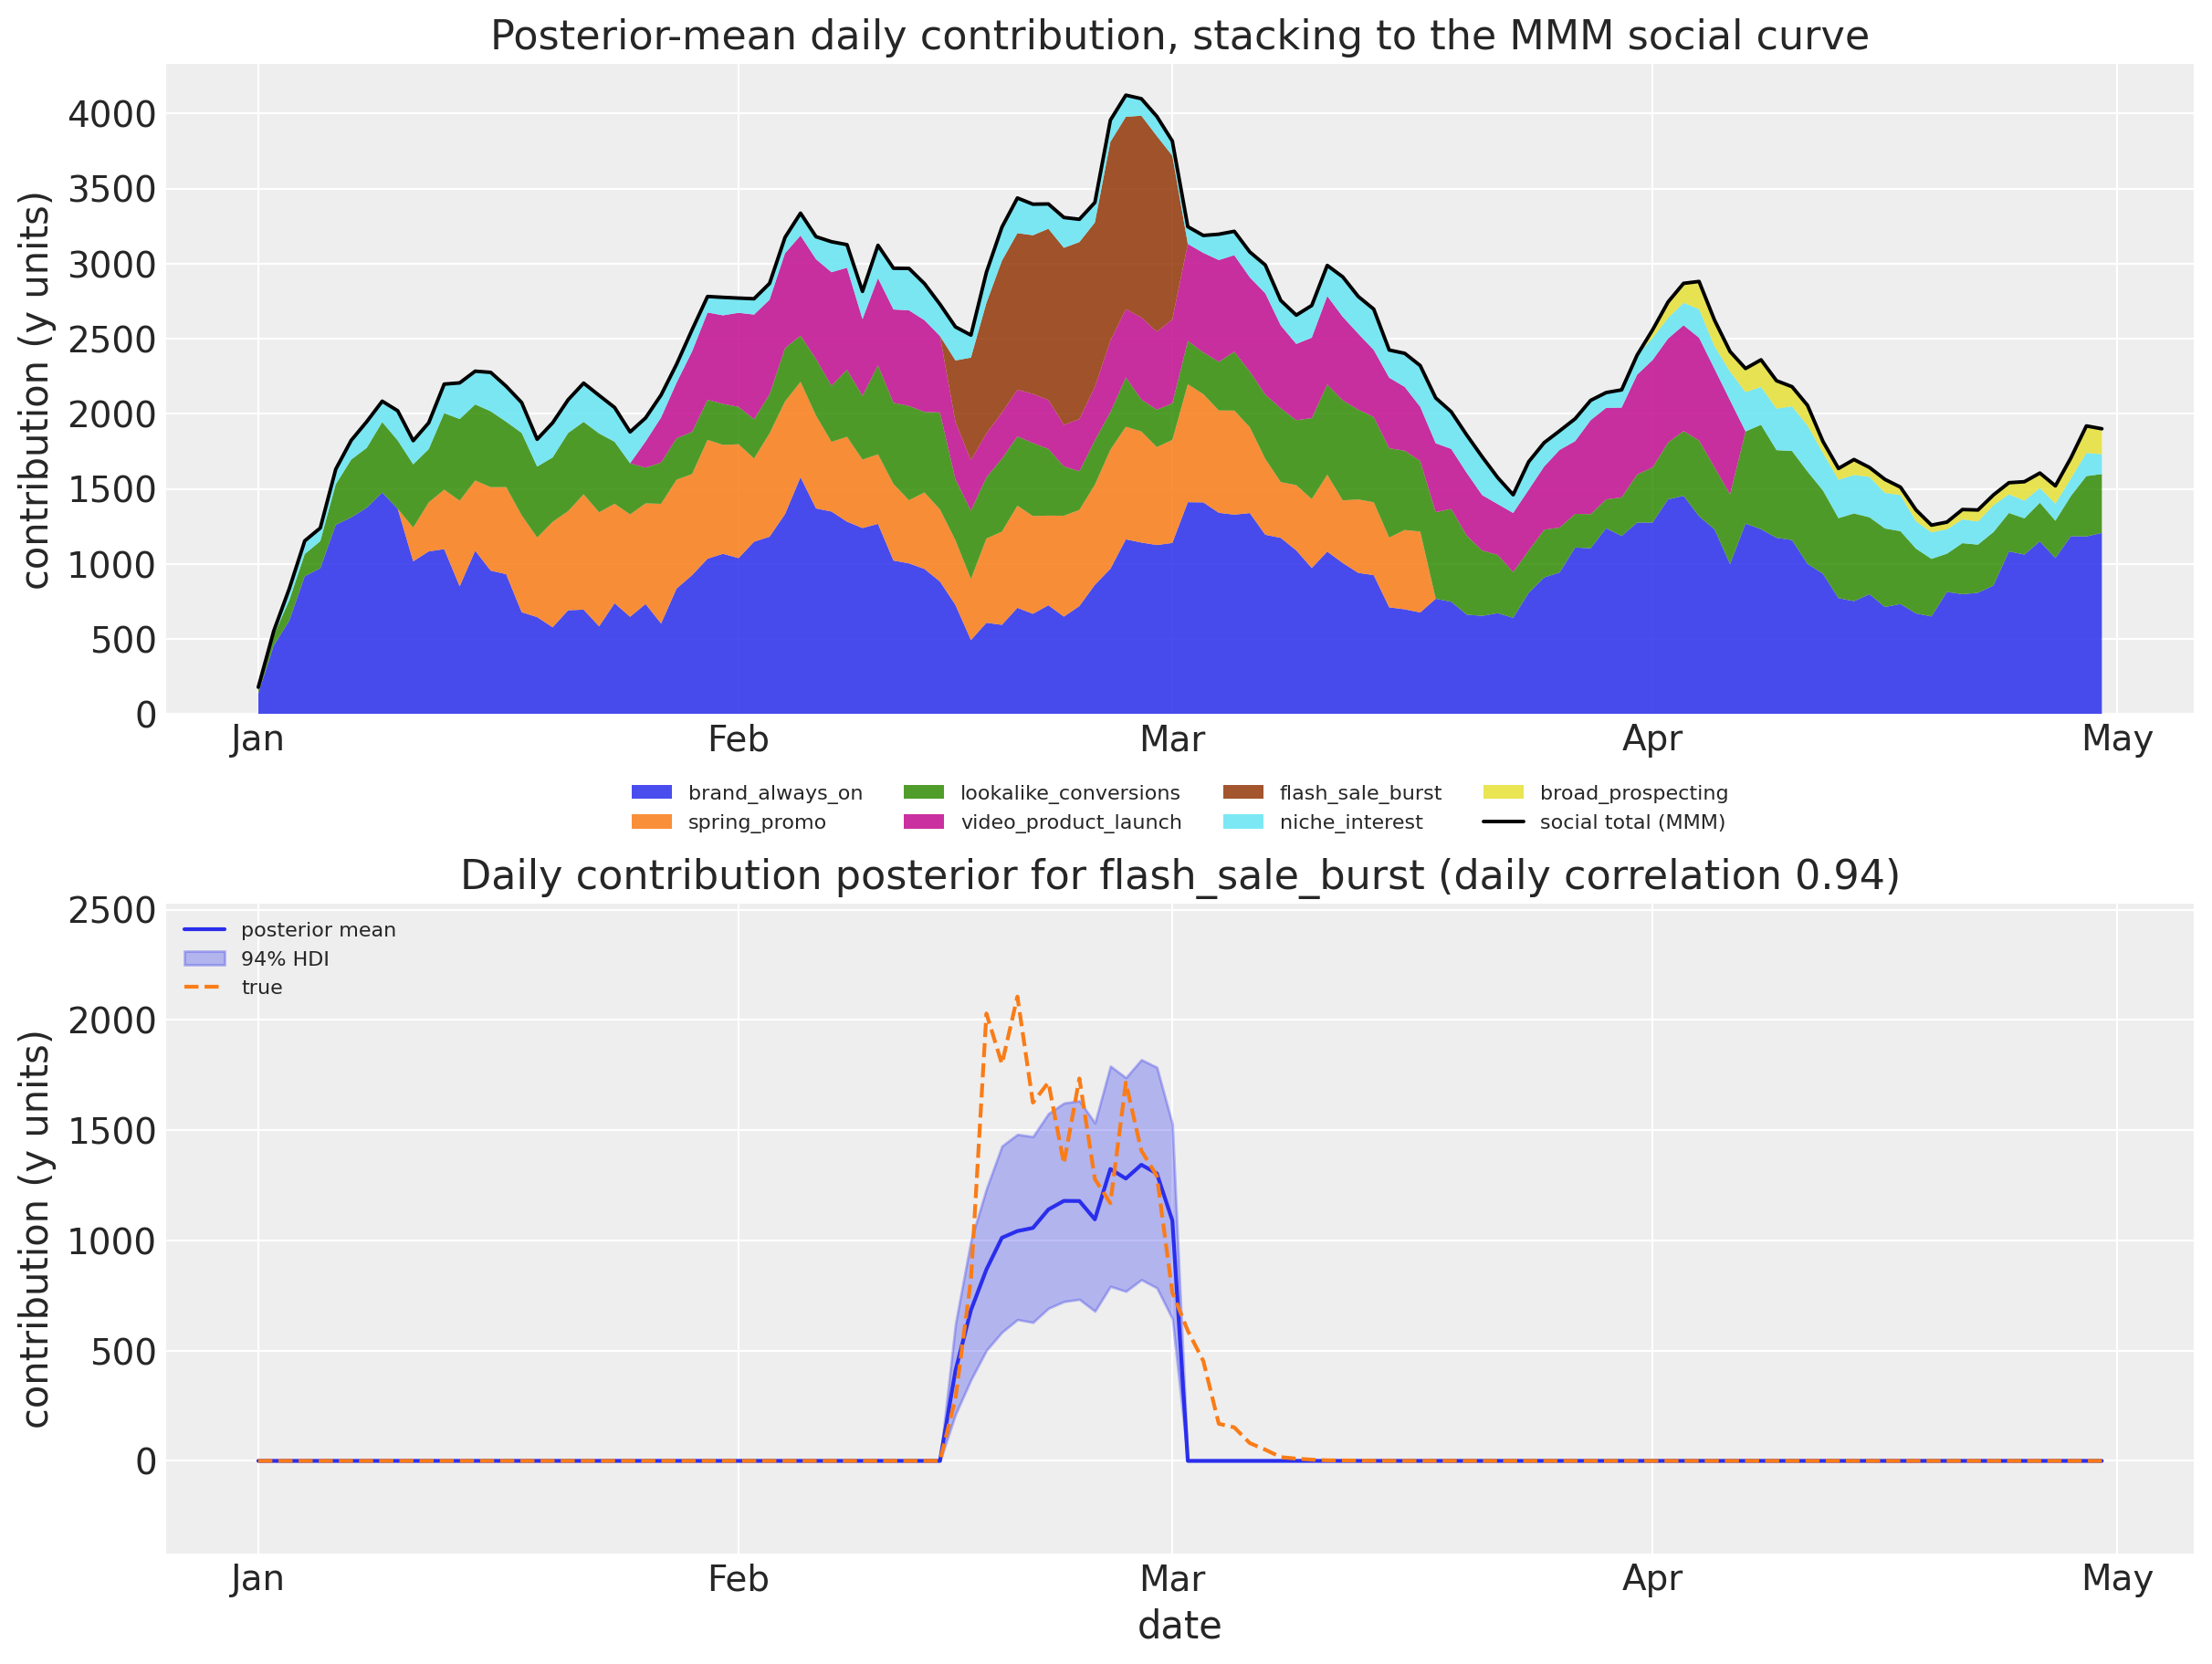

In [25]:
daily_mean = contribution.mean("sample")
daily_correlation = pd.Series(
    {
        campaign: float(
            np.corrcoef(
                daily_mean.sel(campaign=campaign).to_numpy(),
                data.truth[campaign].to_numpy(),
            )[0, 1]
        )
        for campaign in campaigns
    }
).sort_values(ascending=False)

fig, (ax_stack, ax_daily) = plt.subplots(
    nrows=2, figsize=(12, 9), layout="constrained"
)
ax_stack.stackplot(
    reach.date,
    [daily_mean.sel(campaign=campaign).to_numpy() for campaign in campaigns],
    labels=campaigns,
    colors=[colors[campaign] for campaign in campaigns],
    alpha=0.85,
)
ax_stack.plot(
    reach.date,
    social_draws.mean("sample").to_numpy(),
    color="black",
    lw=1.4,
    label="social total (MMM)",
)
ax_stack.set(
    title="Posterior-mean daily contribution, stacking to the MMM social curve",
    xlabel="",
    ylabel="contribution (y units)",
)
# below the panel, so both panels keep the same width and nothing is covered
ax_stack.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=4, fontsize=8)

focus = "flash_sale_burst"
focus_daily = contribution.sel(campaign=focus)
focus_bounds = az.hdi(focus_daily, dim="sample")
ax_daily.plot(
    reach.date,
    focus_daily.mean("sample").to_numpy(),
    color="C0",
    label="posterior mean",
)
ax_daily.fill_between(
    reach.date,
    focus_bounds.sel(ci_bound="lower").to_numpy(),
    focus_bounds.sel(ci_bound="upper").to_numpy(),
    color="C0",
    alpha=0.3,
    label=f"{CI_PROB:.0%} HDI",
)
ax_daily.plot(
    data.truth.index, data.truth[focus].to_numpy(), color="C1", ls="--", label="true"
)
ax_daily.set(
    title=f"Daily contribution posterior for {focus} "
    f"(daily correlation {daily_correlation[focus]:.2f})",
    xlabel="date",
    ylabel="contribution (y units)",
)
ax_daily.margins(y=0.20)
ax_daily.legend(loc="upper left", fontsize=8)
for ax in (ax_stack, ax_daily):
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

In [26]:
daily_correlation.rename("daily correlation with the truth").round(2)

flash_sale_burst         0.94
spring_promo             0.91
video_product_launch     0.89
broad_prospecting        0.86
brand_always_on          0.77
lookalike_conversions    0.56
niche_interest           0.28
Name: daily correlation with the truth, dtype: float64

> **Fig.** Top: daily credit per campaign, stacking to the MMM social curve by construction, with the `broad_prospecting` slice appearing from nothing in April. Bottom: the daily posterior for `flash_sale_burst` against the hidden truth. Notice the tail: the truth decays for about a week after the burst stops, while our allocation drops to exactly zero the day delivery ends, because the daily shape is inherited from daily reach and nothing in the method knows about adstock.

The stacked figure takes for granted that the daily shape is right, and the correlations above measure it. The claim holds well for five campaigns, from `flash_sale_burst` at 0.94 down to `brand_always_on` at 0.77, and poorly for `lookalike_conversions` at 0.56 and `niche_interest` at 0.28. That is the expected failure mode: the daily shape is inherited entirely from daily reach, so a campaign whose true impact does not track its delivery cannot be fixed by any reweighting of the level.

### How much of this is the prior, and is reach really the evidence?

Two checks, both cheap, both refits of the same model.

The first varies the priors: the scale of `sigma_s` and the width of the prior on $\log k$. The second is a test of the notebook's own thesis. "Reach is evidence" says the dial should be driven by **unique people**, not by delivery volume, and that is directly testable by swapping the volume measure that sets $Z$ from unique reach $n_c$ to reach-days $R_c$, at several seeds so that sampling noise does not get mistaken for a result.

In [27]:
def evaluate_variant(
    volume: pd.Series,
    *,
    sigma_s_scale: float = 0.5,
    log_k_sd: float = 0.75,
) -> dict[str, float]:
    """Fit one configuration end to end and grade the split it produces."""
    model = build_credibility_model(
        y_direct, volume, sigma_s_scale=sigma_s_scale, log_k_sd=log_k_sd
    )
    variant = fit_credibility(model, progressbar=False)
    variant_social, variant_theta = paired_draws(
        data.social, variant.posterior["theta"]
    )
    variant_share = flight_share(
        allocate(variant_social, allocation_weights(variant_theta, reach))
    ).transpose("sample", "campaign")
    dial = variant.posterior["Z"].mean(("chain", "draw")).to_numpy()
    return {
        "divergences": int(variant.sample_stats["diverging"].sum()),
        "k_median": float(variant.posterior["k"].median()) * float(volume.mean()),
        "Z_min": float(dial.min()),
        "Z_max": float(dial.max()),
        **score_shares(true_share, variant_share.to_numpy()),
    }


prior_sensitivity = pd.DataFrame(
    [
        {
            "sigma_s": sigma_s_scale,
            "sd_log_k": log_k_sd,
            **evaluate_variant(
                unique_reach, sigma_s_scale=sigma_s_scale, log_k_sd=log_k_sd
            ),
        }
        for sigma_s_scale in (0.4, 0.5, 0.7)
        for log_k_sd in (0.5, 0.75)
    ]
).set_index(["sigma_s", "sd_log_k"])
prior_sensitivity.round(4)

NUTS[nutpie]: [mu, log_k, sigma_s, theta_raw]
NUTS[nutpie]: [mu, log_k, sigma_s, theta_raw]
NUTS[nutpie]: [mu, log_k, sigma_s, theta_raw]
NUTS[nutpie]: [mu, log_k, sigma_s, theta_raw]
NUTS[nutpie]: [mu, log_k, sigma_s, theta_raw]
NUTS[nutpie]: [mu, log_k, sigma_s, theta_raw]


divergences    k_median   Z_min   Z_max  spearman     mae  \
sigma_s sd_log_k                                                              
0.4     0.50                0  37352.5102  0.3316  0.6169    0.8929  0.0331   
        0.75                0  37854.2027  0.3378  0.6077    0.8929  0.0348   
0.5     0.50                0  37319.6794  0.3319  0.6177    0.8929  0.0345   
        0.75                0  38051.1655  0.3339  0.6046    0.8929  0.0341   
0.7     0.50                0  37576.3988  0.3300  0.6145    0.8929  0.0343   
        0.75                0  38536.6751  0.3348  0.6048    0.8929  0.0336   

                    crps  coverage  
sigma_s sd_log_k                    
0.4     0.50      0.0242       5.0  
        0.75      0.0254       5.0  
0.5     0.50      0.0250       4.0  
        0.75      0.0252       5.0  
0.7     0.50      0.0247       5.0  
        0.75      0.0242       4.0

The ranking is identical across all six settings, MAE stays between 0.0338 and 0.0354 and CRPS between 0.0245 and 0.0256, so the conclusions are not a prior artefact. The evidence threshold drifts by about 6%, upward with the prior scale on `sigma_s`, which is the weak identification showing up as mild prior sensitivity exactly where the algebra said it would. The only divergence anywhere in this sweep appears at the widest pair of priors. Coverage sits at five of seven in five settings and four in the sixth, with no pattern, which is worth saying out loud: with seven campaigns, coverage is far too noisy to tune against.

The `k_median` column is in the units of whichever volume measure sets the dial, so it reads as people here and as reach-days in the table below.

In [28]:
evidence_choice = pd.DataFrame(
    [
        {"volume": name, "seed": seed, **evaluate_variant(volume)}
        for name, volume in [
            ("unique reach (evidence)", unique_reach),
            ("reach-days (delivery)", direct["reach_days"]),
        ]
        for seed in (42, 1, 7)
    ]
).set_index(["volume", "seed"])
evidence_choice.round(4)

NUTS[nutpie]: [mu, log_k, sigma_s, theta_raw]
NUTS[nutpie]: [mu, log_k, sigma_s, theta_raw]
NUTS[nutpie]: [mu, log_k, sigma_s, theta_raw]
NUTS[nutpie]: [mu, log_k, sigma_s, theta_raw]
NUTS[nutpie]: [mu, log_k, sigma_s, theta_raw]
NUTS[nutpie]: [mu, log_k, sigma_s, theta_raw]


divergences     k_median   Z_min   Z_max  \
volume                  seed                                             
unique reach (evidence) 42              0   38051.1655  0.3339  0.6046   
                        1               0   38051.1655  0.3339  0.6046   
                        7               0   38051.1655  0.3339  0.6046   
reach-days (delivery)   42              3  591564.4563  0.0645  0.7011   
                        1               3  591564.4563  0.0645  0.7011   
                        7               3  591564.4563  0.0645  0.7011   

                              spearman     mae    crps  coverage  
volume                  seed                                      
unique reach (evidence) 42      0.8929  0.0341  0.0252       5.0  
                        1       0.8929  0.0341  0.0252       5.0  
                        7       0.8929  0.0341  0.0252       5.0  
reach-days (delivery)   42      0.8929  0.0319  0.0246       4.0  
                        1       0.8929  0.0319  0.0246       4.0  
                        7       0.8929  0.0319  0.0246       4.0

Read that honestly: **this dataset does not settle the question.** Driving the dial by reach-days gives the same ranking at 0.893, the same CRPS to within seed noise, slightly better MAE at 0.0326 to 0.0328, and worse coverage at three of seven, with a much wider spread of $Z$, 0.07 to 0.71, because reach-days span a factor of 47 where unique reach spans 3.5. Seven campaigns cannot separate two measures that are this strongly correlated with each other. What the table does establish is stability: three seeds move MAE and CRPS only in the fourth decimal, and the coverage count by at most one campaign.

We keep unique reach for a reason that is not a score: a person re-reached tomorrow adds delivery but no new information about the campaign, so unique reach is the quantity that answers "how much do I know about this campaign?" That is the definition of a credibility volume measure, and the sensitivity above shows the choice is not paying for itself in accuracy either way.

## The honest part

::: {.callout-note title="What it is genuinely good at"}
- **It refuses to be fooled by small, loud campaigns.** The less evidence a campaign has, the harder its wild self-report is reined in, so bursty campaigns stop hijacking the credit. `flash_sale_burst` is the case in point: its naive rate per reach-day is the highest in the account, and the model takes 0.41 in log units off it.
- **It never breaks the budget.** The campaign pieces sum back to the MMM's channel total exactly, every day, to within 1e-12. It divides the number you trust rather than inventing a new one.
- **It is the best probabilistic forecast of everything tested here**, at a CRPS of 0.0250 in share units against 0.0321 for the best simple heuristic.
- **The dial it picks is defensible without the oracle.** Sweeping a common $Z$ shows partial pooling beats both extremes, and the fitted dials land in the interior and recover the campaign ranking without ever seeing the truth.
- **It is built on the safest idea in the toolbox**, partial pooling, so it behaves well and is easy to explain to whoever asks.
:::

::: {.callout-warning title="What it cannot do (read before trusting)"}
- **It cures noise, not bias.** It fixes the "small campaigns are jumpy" problem. It does not fix the fact that clicks are not incrementality. `lookalike_conversions` stays under-credited by 0.07 in share and `niche_interest` by 0.03, because **no method that only sees delivery data can recover what delivery data does not contain**.
- **On point accuracy it does not beat a delivery split here.** MAE is 0.0343 against 0.0321 for the daily-reach share, and a common dial near 0.20 would have done better still on MAE while getting the ranking wrong. Its measurable gains are ranking, calibration and a defensible trust weight, not a jump in point accuracy.
- **The daily shape is inherited, not estimated.** Within a campaign the day-to-day pattern is its daily reach, which tracks the truth well for five campaigns and badly for `lookalike_conversions` at 0.56 and `niche_interest` at 0.28.
- **The uncertainty is a lower bound.** Five of seven true shares land inside the 94% HDI, but the interval carries parameter uncertainty only, and the clicks-to-incrementality gap is nowhere in the model.
- **Evidence can be confounded with a truncated flight.** `broad_prospecting` is the only campaign still acquiring new people when the window closes, so its unique reach measures 30 days of growth rather than a saturated audience. It is discounted for being young as much as for being small, and nothing in the model knows the difference.
- **Only seven campaigns.** The dial's tuning is itself uncertain, the posterior for $k$ says so, and no single synthetic dataset can settle a comparison against any baseline.
:::

::: {.callout-tip title="Run it on your own data"}
1. **Pull expanding-window reach** per campaign: fix the report's start date and extend the end date one day at a time. The day-over-day differences are genuinely new people.
2. **Build any naive split** of the MMM channel total from what your dashboard already gives you, whether clicks, conversions or last-touch revenue. It is allowed to be bad, that is the point. Express it **per reach-day**, using the same exposure you will allocate over.
3. **Fit the model above** and read off each campaign's trust dial $Z_c$. Even before the split, $Z$ alone tells you which campaign numbers deserve to be taken seriously.
4. **Allocate the MMM channel curve daily**, scoring each campaign by its trust-adjusted rate times its daily reach. The pieces sum to the MMM total by construction.
5. **Sweep the dial against any ground truth you have**, even one lift test. It is the cheapest check that the answer is not an artefact of one fit.
:::

**The bottom line.** This is an uncertainty-aware way to split a channel's MMM credit across campaigns, most valuable exactly where platform numbers are least reliable, on the small and bursty campaigns. Its one hard limit is that delivery data cannot see true incrementality. To break through it, pair the method with a **lift test**: feed a campaign's measured incremental lift in as a prior, and the trust dial will do the rest.

In [29]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc,arviz,pytensor,numpy,pandas,matplotlib

Last updated: Tue, 11 Aug 2026

Python implementation: CPython
Python version       : 3.14.2
IPython version      : 9.15.0

pymc      : 6.0.1
arviz     : 1.2.0
pytensor  : 3.0.7
numpy     : 2.4.6
pandas    : 2.3.3
matplotlib: 3.10.9

IPython       : 9.15.0
arviz         : 1.2.0
arviz_base    : 1.2.0
arviz_plots   : 1.2.0
matplotlib    : 3.10.9
numpy         : 2.4.6
pandas        : 2.3.3
pymc          : 6.0.1
pymc_marketing: 1.0.0
scipy         : 1.18.0
seaborn       : 0.13.2
xarray        : 2026.4.0

Watermark: 2.6.0

